# Table Transformer (DETR-R18, PubTables-1M) — DIMER E2E supervised adaptation tutorial: nutrition-table detection on product photographs, new heads vs bounded decoder unfreeze (standalone)

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/kurtvalcorza/table-transformer-detection-pipeline) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/table-transformer-detection-pipeline/blob/main/tutorials/table_transformer_detection_colab.ipynb) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-microsoft%2Ftable--transformer--detection-ffcc4d?style=flat)](https://huggingface.co/microsoft/table-transformer-detection) [![Upstream](https://img.shields.io/badge/Upstream-microsoft%2Ftable--transformer-181717?style=flat&logo=github&logoColor=white)](https://github.com/microsoft/table-transformer) [![arXiv](https://img.shields.io/badge/arXiv-2110.00061-b31b1b.svg)](https://arxiv.org/abs/2110.00061)

**Profile:** `E2E`  
**Mode:** `GUIDED`  
**Notebook specification:** DIMER Notebook Specification 2.2 — **standalone** (§4)  
**Capability:** table detection on document page images (boxes labelled `table` or `table rotated`) and bounded supervised adaptation to a new box class on a new image domain — new detection heads on the frozen DETR decoder features with an optional unfreeze of the last decoder layers — measured by held-out AP@0.5 / AP@0.75 / mAP, using the pinned `microsoft/table-transformer-detection` weights

**This notebook is standalone.** It carries the repository's package (3 modules under `src/table_transformer_detection_pipeline/`, at revision `67c5153027b3`) verbatim in Section 2, the pinned model identity and the per-file SHA-256 manifest in Section 3, and the exact runtime pins in Section 1, so it keeps working after export even if the repository changes or disappears. Its only external dependencies are the pinned Python distributions and the Hugging Face Hub at the immutable revision `2357cbe2b5a5d1c03e54f32764f06058933b65ab` (~115 MB, digest-verified before loading). It was generated by `tools/build_notebook.py` (build_notebook.py/2.2); edit the repository and regenerate rather than editing cells.

**Run all:** Selecting **Run all** in a fresh supported runtime builds an isolated environment from the hash-locked pins (nothing is installed into the notebook's own Python, so no restart is needed and Run all completes in one pass), stages and digest-verifies the pinned Table Transformer detection snapshot (safetensors, 115 MB), fetches 121 digest-pinned Open Food Facts product photographs with their nutrition-table boxes (129 MB, no credential), validates them and draws 72 / 24 / 25 training, validation and test photographs by a seeded split of whole products, runs one test photograph through the inference contract with an input manifest, a rejection probe and a `sample-sanity` evaluation report against its reference boxes, scores a fixed-box prior and the untouched checkpoint on the test split (the **zero-shot row**), trains a new class head and a copy of the box head on the frozen DETR decoder features (the **frozen policy**) and then the last two decoder layers with them (the **unfrozen policy**), selects between the two by validation DETR loss, scores the held-out split by AP@0.5 / AP@0.75 / mAP with the selected model, renders detections before and after, exports the trained tensors as safetensors with a manifest, and reloads that artifact into a fresh pipeline to verify parity. The default path needs no repository clone, no DIMER worker or service, no credential, no upload dialog and no configuration edit (NOTEBOOK_SPEC 2.0 §5). On CPU the whole path takes about 4 minutes of model time after the downloads; a CUDA runtime is used automatically when present.

**Bring Your Own Data:** After the tutorial workflow completes, set `USE_BYOD = True` in Section 4 and either set `BYOD_PATH` to a zip or folder in the runtime (Colab, Kaggle or Jupyter) or leave it empty to upload one zip in Colab, then choose **Run after** from that cell (it first puts the pipeline back to the pinned base) to supply your own box-labelled images: at least **12 photographs in 12 groups** (or fewer groups with several photographs each — the training split needs 8 photographs after 20 % + 20 % of the groups are held out), photographs stored upright (an EXIF-rotated photograph is refused), as a `.zip` or folder holding `boxes.csv` (columns `id`, `file`, `group`, `x_min`, `y_min`, `x_max`, `y_max`; one row per box, pixel coordinates; `group` — the product, session or device — must be non-empty on every row, and rows of one `id` must agree on `file` and `group`, or the loader refuses the set) beside the image files — images are decoded from the archive, never extracted to disk. They pass through the same validation, seeded group-disjoint split, prior, zero-shot scoring, frozen-policy heads, unfrozen-policy training and selection, held-out evaluation, detection rendering, artifact export and reload-parity cells as the Open Food Facts sample. The expected schema and the ceilings are stated in the Prerequisites and in Section 4, and uploaded files stay inside this runtime. BYOD is optional and never part of the default path.

At inference the DETR-style model reads one image resized to 800 px on its shortest edge, runs a ResNet-18 backbone and a 6-layer encoder–decoder, and emits exactly 15 query proposals, each a box and a softmax over `table`, `table rotated` and *no object*; the processor keeps the queries whose class score reaches the threshold and maps their boxes back to input pixels. The carried pipeline module adds snapshot verification, the input contract, a fixed output contract and the `box_iou`, `validate_inputs` and `evaluation_report` helpers; `evaluation_report` becomes `sample-sanity` only when a caller supplies reference boxes — which this notebook, unlike its inference-only predecessor, does, on a real photograph.

What this notebook adds to inference is **supervised adaptation to a new box class on a new image domain, under an explicit frozen-vs-unfrozen policy**. The dataset is real and far from PubTables-1M's PDF renders: 121 product photographs from the Open Food Facts nutrition-table detection set (version 1.1, manually reviewed; images CC BY-SA 3.0), each with one to three boxes around the printed nutrition table, pinned per file by byte size and SHA-256 of the served original, fetched at run time, refused on any mismatch and downscaled to 1,280 px. Two products have two photographs, so the sample is split by **product**, never by photograph. The carried `metrics.py` scores a prediction set by **AP@0.5**, **AP@0.75** and **mAP** (the COCO convention, one class, over every query of every image) plus the recall and precision at the pipeline's operating threshold and at 0.5; a **fixed-box prior** (the training split's mean box) and the **untouched checkpoint** (its `table` + `table rotated` mass as the score) frame the numbers. The **frozen policy** trains a new two-way class head and a copy of the box head on the frozen decoder features under the DETR set loss (Hungarian matching, cross-entropy with a 0.1 no-object weight, L1 and GIoU — implemented in the carried module, no external matcher); the **unfrozen policy** continues by training the last decoder layers with them end to end, and the epoch with the lowest validation loss — which may be the heads alone — is kept. The PubTables heads and `detect` are never trained or exported. The adaptation question is whether unfreezing the decoder buys anything over new heads on 72 photographs. Nothing here is a quality claim about your images: it is one seeded split of one small corpus.

**Learning objectives:** install the pinned runtime; read what the carried pipeline, metrics and dataset modules guarantee; stage and digest-verify the immutable upstream snapshot; fetch a digest-pinned real box-labelled corpus and validate and split it by product without leakage; run a real photograph through the public detection API and read a `sample-sanity` report against reference boxes; read AP@0.5 / AP@0.75 / mAP beside a fixed-box prior and the zero-shot checkpoint and understand why a detector's score threshold is an operating point, not part of AP; train new detection heads on frozen features and a bounded decoder unfreeze with explicit hyperparameters and validation-based selection between the two policies; evaluate on an independent product-disjoint test split; compare detections before and after; and export a safetensors adapter (heads plus any trained decoder layers) that reloads against the pinned base with verified parity.

**This notebook does not demonstrate:** table *structure* recognition (rows, columns, cells — the sibling `table-transformer-structure-pipeline` covers it), OCR or nutrient text extraction, multi-class detection, backbone or encoder training, data augmentation, any training of the PubTables heads, any PubTables-1M accuracy claim, and any claim that 121 product photographs from one site stand in for your images. The repository exposes none of these.

**Who this notebook is for.** A learner who knows basic Python, has used Colab or Jupyter, and wants to see how a pretrained detector is adapted to a new class and domain with a small box-labelled set — new heads on frozen features versus a bounded unfreeze — and how to tell from held-out numbers which one helped, without fooling themselves. No prior experience with DETR or fine-tuning is assumed; each term is explained where it first matters and again in the **Glossary** at the end. CPU is adequate (about four minutes of model time); a GPU is faster.

**Input → Model → Output.**

| | Detection (PubTables heads) | Adapted detection | Bounded adaptation |
|---|---|---|---|
| Input | one image, sides 16..4,096 px, and a score threshold | one product photograph | box-labelled photographs (72 training and 24 validation in the sample), split by product |
| Model | Table Transformer: ResNet-18 backbone, DETR encoder-decoder with 15 queries, PubTables heads (`table`, `table rotated`) | the same decoder with a new two-way class head and a copied box head | frozen policy: the new heads on frozen decoder features; unfrozen policy: also the last two decoder layers; validation loss chooses |
| Output | boxes with a label and a softmax score — not calibrated | `nutrition-table` boxes with scores | a safetensors adapter, and held-out AP@0.5 / AP@0.75 / mAP beside a prior and the zero-shot row |

**How to use this notebook.** Choose a runtime (CPU works; a GPU is faster), then **Runtime → Run all**. Run all completes in one pass: Section 1 installs nothing into the notebook's own Python, so no restart is needed. Sections 1–3 are **infrastructure** — the isolated environment, the carried package (including the pinned photograph table) and the model snapshot — and their cells are collapsed; you may run them without studying them. The learning path starts in Section 4. Form fields (`# @param`) are the only values meant to be edited, and the defaults reproduce the recorded run. Before each principal result the notebook asks you to **Predict**; after it come **What to notice** and a collapsible **Check your reasoning** with a worked answer that names the run it quotes — the Kaggle T4 release run of 19 September 2026 and the CPU build record, which disagree in an instructive way. Section 10 is a **change-one-thing experiment**, off by default. **Troubleshooting**, a **Glossary** and a **Conclusion** template are at the end. Writing your predictions down is optional.

**Roadmap:** 1–3 infrastructure → 4 the corpus, validation and a product-level split *(evaluation practice)* → 5 the inference contract with reference boxes *(core concept: what a detector returns)* → 6 the prior, the zero-shot checkpoint and the frozen policy *(evaluation practice)* → 7 the unfrozen policy and validation selection *(core concept)* → 8 held-out evaluation → 9 detections before and after, export and reload *(engineering)* → 10 change one thing (optional) → conclude.

## Prerequisites

- **Learner:** basic Python and Colab or Jupyter familiarity; no prior experience with DETR or fine-tuning. The notebook explains DETR queries, the set loss with Hungarian matching and GIoU, AP@0.5 / AP@0.75 / mAP, operating points, the frozen and unfrozen policies and the adapter where they are first used; the Glossary repeats them.
- **Runtime:** a fresh supported **Linux x86_64** runtime (Google Colab, Kaggle or Linux Jupyter). Section 1 builds its own Python 3.12.12 environment from a hash-locked list of manylinux wheels, so the kernel's own Python version does not matter and nothing is installed into it. The default path runs on CPU and uses CUDA automatically when available; float32 on both. The build record measured about 0.3 s per photograph to run the decoder on CPU (3 s for the 25-photograph zero-shot pass), about 20 s for the new heads including feature extraction, and about 30 s per unfreeze epoch over 72 photographs plus a 24-photograph validation pass. The pinned `torch==2.14.0` install and the 115 MB checkpoint are the large downloads of the run, then the 129 MB of photographs.
- **Knowledge:** basic Python and PIL; what a bounding box in xyxy pixel coordinates is; what intersection-over-union and average precision measure and why AP does not depend on a score threshold; what a Hungarian (one-to-one) matching between predictions and references is; what validation-based selection between two policies means.
- **Data contract:** records are `{id, image, boxes}` — a PIL image (or a path to one) with sides 16..4,096 px, a list of 1..15 `[x_min, y_min, x_max, y_max]` pixel boxes inside the image with sides of at least 4 px, ids matching `[A-Za-z0-9_.:-]{1,64}` and unique; a training set needs 8..2,000 records, so with the default 20 % + 20 % group hold-out the effective BYOD minimum is **12 photographs in 12 groups** (`min_byod_records()` computes it); a photograph with an EXIF orientation tag is refused, since its boxes would not line up with the pixels; images are de-duplicated by decoded-pixel digest and split by `group` / `barcode` so one product never straddles splits. BYOD accepts a `.zip` (or a directory) holding `boxes.csv` and the image files, and requires a non-empty `group` on every row — the notebook's automatic split is group-disjoint only because the loader refuses ungrouped rows (`load_byod_dataset(..., require_group=False)` is the explicit opt-out, without that guarantee).
- **Validation is structural, not semantic:** nothing checks that a box is around a table — a mislabelled set is trained on without complaint; all boxes are one class, and the four Open Food Facts nutrition-table categories are merged into it (kept under `categories` for provenance).
- **Privacy:** Do not upload confidential or restricted data to a hosted runtime unless you are authorized to process it there — product photographs can show hands, homes and receipts. The default path uploads nothing.
- **External access (data):** besides the Hub, the default path fetches 121 pinned objects (`<barcode path>/<image id>.jpg`, 129,318,620 bytes in total, one SHA-256 each in the carried `SAMPLE_RECORDS` table) from `static.openfoodfacts.org` over HTTPS, each refused on any byte-size or SHA-256 mismatch before it is decoded; the images are CC BY-SA 3.0 (Open Food Facts contributors) and the boxes come from the Open Food Facts nutrition-table detection dataset (ODbL), credited in the References.
- **External access:** the Hugging Face Hub, to fetch the pinned `microsoft/table-transformer-detection` snapshot (~115 MB in total) at revision `2357cbe2b5a5…`, and `static.openfoodfacts.org`, for the 121 pinned photographs named in the data bullet above. No credentials are required; nothing is installed from this repository. The isolated environment also needs PyPI (`pypi.org`, `files.pythonhosted.org`) for the pinned `uv` wheel and the 48 hash-locked packages, and the managed CPython 3.12.12 build (python-build-standalone) that `uv` downloads.

## 1. Install the pinned runtime (isolated environment)

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

Hosted runtimes such as Colab and Kaggle import some packages, NumPy and often PyTorch among them, before the first cell runs, and Python cannot swap a module that is already loaded. Installing the pins into the notebook's own Python would therefore leave mixed versions or require a manual restart. Instead, the next cell builds a separate environment (`dimer_isolated_env_<lock digest>/`) and leaves the kernel's packages untouched: it downloads the pinned `uv` 0.12.15 wheel and refuses it unless its size and SHA-256 match, has `uv` install the managed CPython **3.12.12** (whatever Python the kernel itself runs), and installs the 48 packages of the carried hash-locked requirements (`tutorials/requirements-colab.lock.txt`, compiled from the pins in the cell) with `--require-hashes --only-binary :all:`, so every package, direct or transitive, is the exact file that was locked. No repository code is installed. The lock holds manylinux x86_64 wheels, so the notebook supports **Linux x86_64 runtimes only** (Google Colab, Kaggle or Linux Jupyter); on any other platform the cell stops with that message.

The same cell then starts one Python process in that environment and routes **every later code cell** to it. Printed output comes back to the notebook as usual, variables persist from cell to cell, and an error stops **Run all** as it would in the kernel. It is the only cell that runs in the kernel (it is marked `# dimer: kernel cell`), and it is safe to re-run: a complete environment built from this exact lock is reused rather than rebuilt, and a live worker is kept with every variable created so far, so the cells after it keep working. To start over, restart the session and choose **Run all**. `DIMER_NOTEBOOK_CI_PREINSTALLED=1` lets an executor that has already installed exactly these pins run every cell in its own kernel instead.

In [ ]:
# @title Infrastructure: build (or reuse) the isolated environment and route later cells to it
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
import hashlib
import io
import os
import platform
import signal
import subprocess
import sys
import time
import urllib.error
import urllib.request
import zipfile
from multiprocessing.connection import Connection
from pathlib import Path

PINS = [
    'torch==2.14.0',
    'torchvision==0.29.0',
    'torchaudio==2.11.0',
    'transformers==4.57.6',
    'timm==1.0.29',
    'safetensors==0.8.0',
    'numpy==2.5.3',
    'pillow==11.3.0',
    'huggingface-hub==0.36.2',
]
MANAGED_PYTHON = '3.12.12'
UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
LOCK_NAME = 'requirements-colab.lock.txt'
LOCK_SHA256 = '098825a802c15ce12cd1f8c39fdb12ff412b248002e2ec098cd1016bdba955b7'
LOCKED_PACKAGES = 48
# The hash-locked requirements, compiled from the PINS above with `uv pip compile --generate-hashes` for manylinux x86_64.
LOCK_TEXT = r'''# This file was autogenerated by uv via the following command:
#    uv pip compile pyproject.toml --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: -o tutorials/requirements-colab.lock.txt
certifi==2026.7.22 \
    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \
    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55
    # via requests
charset-normalizer==3.5.2 \
    --hash=sha256:01077390b03f7988f11d700a2194e69b119741a86b1a638b1db88891e3eced8e \
    --hash=sha256:01b0c0d2262a9e28e8484a278c7e1b5d650e3ac8cf2683d2967e25899f208bdf \
    --hash=sha256:04851f73ae72b8413dddadb16a49dfee95263553741fd42d546f7d66907e6be5 \
    --hash=sha256:0521c5665880b33d603717defa76c094048900010897909952397feb3039da56 \
    --hash=sha256:0774bf9bf620249fee3e0b8b9fd3065de213be30f3aa94ce2494b3b638949e26 \
    --hash=sha256:0891b9d3903c5571c03771ca669a4b0ec5618ca722a5c957d3d29cd4e5062848 \
    --hash=sha256:0c951d5e6dd9c2ff60609476752bee49da4206adde960ebc247766937f72e718 \
    --hash=sha256:0fed1d06615f022ee3b13caf5e8b180cfea32bb2c5aded8a9d44277afc040f93 \
    --hash=sha256:114e4d0c92d618409ed82a99e22b5c5e768fe995f2973f78265f4524f49d4640 \
    --hash=sha256:11912e4bb14baae7c5d8791aa55ba0a3a03ec6729073307b0f57270abaa713d3 \
    --hash=sha256:11a4d68a6ecda3292cb1e50239e111543ba5d709bb62a6b4ea1afcfa729d8875 \
    --hash=sha256:124fbf1a8ff966d87ae05bb8bd45a71f966055ed8bba320d0c7cf450bc5f4d0e \
    --hash=sha256:1461ac396c4fdb983a675f20aa555624f0ee18ac83d832b9244ffff3d8055275 \
    --hash=sha256:1503bccbeb36d5527790c3930327704c39af22de3112f1b1666a9f3ce15ee204 \
    --hash=sha256:15bb4005af6320d259dc7593ca84a38d7fe06a421dbcf7b910ae23979101e787 \
    --hash=sha256:15c44f7edfd477b06f517a5cc317fc1707edb9de2c865f43d4b6513907473234 \
    --hash=sha256:16fa0eccf81304b79c5cd87f9271c3b85dd9dd99245e4422ae9c0dd45e0f99d3 \
    --hash=sha256:183b88127acdb4fabe59d951ab424faf1af7b63cdbb5f776186c1ea2ffcaed98 \
    --hash=sha256:195c26fb65950f8fce54e26349852b7bdd7c5f120aeefbcc440b8a20faaed4a3 \
    --hash=sha256:1afb975bd5d68d5ce9f6b6d44fdf2f7e34b895a35e95708a7a91b20a3b51d187 \
    --hash=sha256:1b4cbc7c3491ccb4aa17fcd8165649d01cf39f76de1696da8631b5f71b85401d \
    --hash=sha256:1bc0baf5ef96b6ede57d47f4b8fe4d9d84019c3bfcbeb20a41edc6a6ee341f1f \
    --hash=sha256:1c50fe28bbc2ced33386f298650d91218076c05420e6cbd790b913adc41659e7 \
    --hash=sha256:1db38f4c5496827c1a501846d64d14c3b80c7e6714e406cd7dc36a9899fa1011 \
    --hash=sha256:211d5a3eb6af8f513b8d4ca19a8c1b7accab1b5f0d3175f9826b03c1a920dc1f \
    --hash=sha256:23851fb4e1b85ed3f6c2a27b777cdfe2e19fb5b38429a8faf38c7542b7665869 \
    --hash=sha256:254eb48b9fa5ee9898a3c445825a1f340fe53712a098904b39b0bddba8ea3cb1 \
    --hash=sha256:2625388c6c754520c37abaf3b41eb34d1cc4a373f457898f08606c8e362b891d \
    --hash=sha256:281cb91036248400f4cc957495cccd44c275c2e0c5854f7e45ac5cf7dc193847 \
    --hash=sha256:28a15fdad492a99b6eccfaaed66ef3f74050680545ea61ec8b2f4c538f1f1320 \
    --hash=sha256:28b4f0d66fb834ff90f28209ac7bce77868c45d8c93e26f906709d9b7c2e1af9 \
    --hash=sha256:2a925889534b3748302dae5dead07cc13480de1dac3aea80a941b729b471ef93 \
    --hash=sha256:2b7b3bbfb4fe8ef40600792d762fbaa9057559f9d3fad209525b7a22b99e91fd \
    --hash=sha256:2c9ad19a6cfcd5ea5c0d41161d22f9df1dcc277e9bef2751391334546a314c00 \
    --hash=sha256:2cc961b171b3f3440f410489ab3573e86aea8736134ebbb40ea1338b7f0831bc \
    --hash=sha256:2ce45c6627b22c47e390bc91a41c3d13032192e699fa0bea96e9671b373d69b0 \
    --hash=sha256:2e06a3a98f916dd41d27f3105e02e7a40181c98c94b9158733d03a6f80506c09 \
    --hash=sha256:304d5463e65a35d7bb0850550e0780395395f6fcf452f04db7d5ca7cecc425ac \
    --hash=sha256:304d8e4d493af723536393eee0c689eb7813f4a474c8b479dee63f1fdd98f621 \
    --hash=sha256:30fcd120b732aa79317f08dee04d7de0847822e4cf7ee0e9f445bb958832252c \
    --hash=sha256:31f3930700408d211f13378ccbe1c40845d8da54bd0681fac3a9b5aae81c7aa8 \
    --hash=sha256:34276fd796040bf0993ab33a369aa572e6979c7aab225a88893667ad8eac8f7a \
    --hash=sha256:355ad8011081dec5412240c087a9a0c9d4d5039f3ed11a3f13e18c2b29b56c51 \
    --hash=sha256:38a873987f3be698494da8b2e3085e29da02da7b633dce73e79c699a113d7bf0 \
    --hash=sha256:39de2a259fc954455c57274dc94c79d5842774e1247a016aff30bc0efed0f4ef \
    --hash=sha256:3d14b50de6bf4d0edf857a9386836846f982b8f524e188e2e68b96d702bcf4aa \
    --hash=sha256:3d21b8b13c7592db2ac5e544a6d83187b995257472b0c9e8351b6d507ae37ed6 \
    --hash=sha256:3d31298449090ab8d47b7b1b2a555ff73cac7ed438a08b7ac160980c7ebed649 \
    --hash=sha256:3ddacd27458c45bdacd6bd6db644bfb730efbf9e830310186e3045c9c5be8fb2 \
    --hash=sha256:3df041de8887954562c9b261cba85ca0e9ded74048daf125f45edcfaa4832229 \
    --hash=sha256:40ab6bffa02ae10a0581e6c198be7d2d8ca5c2a0c64e4ed3465d766df457573e \
    --hash=sha256:4275811936e2f06feff5e598fb42a1b7ae852da8e39605211892b56b81a34efd \
    --hash=sha256:443eae2bf318abeaf6f15d785138f71fd6de770e99a92158b8b814265e079115 \
    --hash=sha256:447441e76ec720b15e64418d32e092297340387053047c7c694f579efb0ee1d9 \
    --hash=sha256:4495c5002a7b28557e7e222e77e0b661183e432b7d6d2e788101e3f240e05b8c \
    --hash=sha256:44bd4fbb29dfbeba60e7d2bd000c59e4b21ddb3cc53912b14048d37092706d7c \
    --hash=sha256:4685902cf26edf013ed7a3da0f426ebba7a00ebb9541386d835afbf002c11cab \
    --hash=sha256:498dc3188ca05a68231ac3fdbfc7f57eb67e1343c30e0fea17f8218c1599b253 \
    --hash=sha256:4c2b5031f63e331e3839b40aed2dd6f191e9c07edbde303e7876846ea1946995 \
    --hash=sha256:4d48f2d08b9de5864e2c8744d4461b862fb149a18274abc8b698c45975573438 \
    --hash=sha256:4f87960d57feabfb618e4e0af6e7371645fa26a277860739d6e5d6e0012c92f0 \
    --hash=sha256:50e3adfb96fc189eb27b1cf62d3b598b89b4bb0420d93a3d3e42e137409011be \
    --hash=sha256:51cf45226a9b588d0d2b4880c62d686934b63ab0bd79ca23ab0e9762eb27441b \
    --hash=sha256:52aa6992700996af31f375de0c6bacd402b0097fe40b53c426b9f51a90ebabc7 \
    --hash=sha256:55ea99acb17b9325618de155a0cd6a2e8f5d10be008113e1d433bbb58db543b2 \
    --hash=sha256:56bc200a365efb37383b7852e4cc5898d3b2da5987289b543956cf8cad71018a \
    --hash=sha256:588461c2e8384d309bd63e5826019b6977bc66d629b99ac8737bb795d7b2cb5a \
    --hash=sha256:58ca3755ee7ff7f59b57789ec9833c9de9ea275405cdd240eda1f193112e398a \
    --hash=sha256:58f361dcbab699cf8f42db3f47c8e7fd1036f138c23a5d08de9fde5f425a730c \
    --hash=sha256:598a11a2c7ebaa5334bf698bf29568c9c390abac6a154d8170fedecd1cea38c5 \
    --hash=sha256:59f63901b0031c3136cf64704dcb21de0bbae62ce2c9529bc39d27665463de37 \
    --hash=sha256:5cde776b7cc66e4f6c99612cea4aa7269aa65863f7a15841b2c264f103822f4e \
    --hash=sha256:5e2b6b57e9733d39f0c9fd3185efa6b8e29652c4cd8fe94180272cf6ed9a78c4 \
    --hash=sha256:5fb29fb8cd1a46c27a1bf9613ad5ec2599310d46b4025d9556404a6b6a292800 \
    --hash=sha256:6045373d5a89a5ec71afde535db987ca28e76dfa276c2d4c818265b375d4b055 \
    --hash=sha256:619799369eeef6366ed3e8755a5670f4f2f0fb6b30a0fd7264dc0fdc2357058e \
    --hash=sha256:62588a277bfb59def052abd940703fa35107152bf479781a878617d60faf8fb5 \
    --hash=sha256:62603db9a7caa0802eaa28c1c46fecd7b3a263a774069c24c3c28c302448721c \
    --hash=sha256:65cd72beeeca9d3aaea1201e5923859f308f952f9c71de93f06063c79f0f7a3b \
    --hash=sha256:68eb192d85ab8e5f6ec69c2bc6ac0179fbf04a5ac1569d12fbef74883fe102d0 \
    --hash=sha256:6bd128f206a7752ae1f2ab6c61bf8a24ba28913a10df8b14c2637b973ff97a80 \
    --hash=sha256:6be488a102b8cf28d0391d8c4ba7748938ae28b78ad901f8585520fca33ead1a \
    --hash=sha256:7218e8f32b0956cfcd048fd42d9d5779809745ca1d86113ca56f66e7ae1549c4 \
    --hash=sha256:7441d755b7ab94f8d4eb3e43ec05482d760842fd263d003a99102d742cd835e2 \
    --hash=sha256:749e97e1b32313717a565abbe321bc2190bc8b35f1a67e4cdbc7c56c8d8ffe58 \
    --hash=sha256:75a3ceed0724d625d64b86ca20aba182e4df462e04c2414fc941c0f523f06aac \
    --hash=sha256:780fbe7cab297b81dad9fb8dc5eb003c0468ffb0d9e5f65068c53a34661a96bc \
    --hash=sha256:78456a747de8dc58360ffa581f30a002baf5aa28cb262536545e91f113ed7639 \
    --hash=sha256:7967d08cf06dee78443b874f98c98036f624f3a4e73e11f9f64f5be4d25393cf \
    --hash=sha256:7a881931aa470808df94a8c380eed2bbbc76cd9dc622310f99665658c821eb6d \
    --hash=sha256:7dcd882da75ef9adf94903b1e3b9419e8aa8fb4c7396822b834b9ef7fb96954f \
    --hash=sha256:7e841fb9010836c992c9f12fcbd43a831de93a5f726fc1ccd8ca1d0268c5014c \
    --hash=sha256:7fdde2c9fd9e3eca40631e024664cf2584272cc8f96308cbe5fdfc930f51d8bc \
    --hash=sha256:8024d00c3faf3fc0c16e07a69f4405e8eac7cc0ab15f65fe6cf43827c4cf72b4 \
    --hash=sha256:80d02b6f04e92601a081dd97b23d3128033098bff5d35d392ddcc0476ea11253 \
    --hash=sha256:838dcc90063569a0448120554591a1d6c4a4ffe11babf048908793154ab86ade \
    --hash=sha256:849df64e889b2e17230d58410a03dba311a65b163508fd33679b2b737d4b7858 \
    --hash=sha256:87475fabc8d9996fd9c27debb395e642e8c838d78a00b6e932227a0e06b81e26 \
    --hash=sha256:87e50a3e7cb90af586b6c5faf23e302a970415ac73bd7bd90a515a04b427ef96 \
    --hash=sha256:89b53f3cda69831909888e0494f4fa0bcd3537e3e138dabeb620bd6ad946bae8 \
    --hash=sha256:8a893cc101149f80a653f82062ebc95b34525a2614382e1da5458fe7c6997249 \
    --hash=sha256:8b2bfab86aa71ae13aa41a6a26aab338e0db2b8bc75434b05aea89e011ff35a4 \
    --hash=sha256:8d86d6fc60743dc916eb79e2eb1ec4818e21e427731543af40a3021851174a13 \
    --hash=sha256:915563965d418f986e7e145accc592eae9e1a1be3566ff98a05d7a9ec42a76e1 \
    --hash=sha256:92888bb3187c5ba50500b00b3b310c9f2c651709d28036077680cb5255450a03 \
    --hash=sha256:93223adc95033dd47133a46ccfc316a0139176fd79085762e27202ec56018f03 \
    --hash=sha256:9373ad13ef0d2c0fb761e04e55bfdee5a08b52cef2c882c8fbe9935b1517152e \
    --hash=sha256:9409a8bf35cf78353942504b24a57de3d75b708997a1e4bd8db71ac8633ce364 \
    --hash=sha256:9b7f416ff0978e2f2249330527f0ad6fa02f4932e6199692d3b52da2048c19e4 \
    --hash=sha256:9bde855991b7e362c146535e3136a50bfaffc0487d38b33ca7e5edefc6e23849 \
    --hash=sha256:9cae88599c7219005d879f98e5ed53341e9a122af585e1091200358a3003d2a0 \
    --hash=sha256:9cf9b1a857e25c4baceeb3624e92a56df3668f398c4acba74e174d81fb4d1d3a \
    --hash=sha256:9f56f72050826f63dcee7a7f55b0a77168cb3bfc553fd405e7f8f9ece75a4036 \
    --hash=sha256:a090bb2c68df85450502e3e20d665e3a5af9c65a84d6508ed477badd49166fd3 \
    --hash=sha256:a192e2c40070d92c3ccf777e3a5c4ff515573cd2bb7ed0c537fdadbbec5bbf21 \
    --hash=sha256:a19a731138fc27d5682277d3b9df22855cea1239bce7fcec5f78f42ef2d1f3c3 \
    --hash=sha256:a66c3bc5ab1f0ff2164fc9965ddd611ff0802173f4b9d24554c563f6ab7e1d6e \
    --hash=sha256:a815775b6c38d4e0ff7bcffbeba67feded90202bb6a226b8dd35f1c855217413 \
    --hash=sha256:a89012d6d5476ee112d20d998570ed58df2260a852afb1758809cd6900411d21 \
    --hash=sha256:ae4f5fea5b8b8ccff88238cc8569303e5ee95efae67fa62922a311397a71f346 \
    --hash=sha256:b6856554c4f44d79fc2307d5768854310a8f0096e501c75637542c82292b0429 \
    --hash=sha256:b6b751274acb69d77b3323d6b7dbaa3c7fdfc1eb829b7eb61d262f32e1af9685 \
    --hash=sha256:b736353c0a625bbd5fcec108576e2385db3496f4f771f785ff32e108d3c3bc45 \
    --hash=sha256:b7fd005a73d9e657273b7a10dc71a9e03c8fb9ee6999798d6918ce095b81ac7f \
    --hash=sha256:b91363207bd9dc966a691e959bb47f64b30f7ac4b072be9968b366982f7db77c \
    --hash=sha256:ba0b1d2620edf869789c3879223f52bf2afc5d31b3cb47cc57b3a12c05e2aa9d \
    --hash=sha256:bbbfc8e28816f19d7c0f1816664980c0a9875d01b27cdf8eedddb639d9e108ad \
    --hash=sha256:bd16aabe4a02a297c23417aa17ac6299dbd8c49f673bcd645b4929b11f5a4400 \
    --hash=sha256:c0afc6800ba57ccc350374c5bd6150419915d95ce93cdbab2d783d75eaf30ecb \
    --hash=sha256:c6708715abcf3c73b99508253e961a9967f02fe536532834149574eda6de0d1c \
    --hash=sha256:c7c9ab723cde841fefb34efbad91e87f00a674b1fe1cd0784fde742bf2c154dc \
    --hash=sha256:c8f3d67aeaf55f017982b73683f0e7342ba2f6635a78f69ce89ebb26aa411e5c \
    --hash=sha256:c9790464842f85f437dbbb54417eda1e0e6bfc52dd8d22d6fd1c994b73b2dc74 \
    --hash=sha256:ca403d7e4798f525fdfc78e258820419cbbd0f0ecbab9de7840e3c017cf6b8cf \
    --hash=sha256:d008d90a7f2471519aef0c90dfbe73b3e6e4d5e66ac48e19154c17e89e98b604 \
    --hash=sha256:d19fbd981a488e22cd04883659ca6b08f50b5974f9fd7c95655ef6a043e5893f \
    --hash=sha256:d1befeed746d247c81127bb14de9dc3d30edb6e5976d34f83f86ed262b1d9105 \
    --hash=sha256:d2374b62878abb00cd8309b32af6c0b715cd02dec0ca74ef12e5069bdc64144a \
    --hash=sha256:d376bbd28b3a8999db1a103b3b388aee6f1ddeb3e51bc2172993efdcd86e064d \
    --hash=sha256:d4a7319f304a774bed22115bc891618e45f85065ab44ea6acd07d274e750519a \
    --hash=sha256:d6734d2ef8a50fbf8445c139477da401f50d62a0606bf00e20ec6d87773fefb1 \
    --hash=sha256:d760fe2a4d7c3b226cb9026d6a842868d52a7901bd98420e1baf14e80da85cf5 \
    --hash=sha256:d913de495d90407cd859d263bee2e5d1a4ed3eb6573c04e70d9ec619a7cbed7f \
    --hash=sha256:db19d07e2e0129e974a0e65d0064fc222a446cd5122c2fd4184d2af9fc734a9e \
    --hash=sha256:dca9ab98072a5a54ebacebdc45f53e645336b320c667410b061be1ca588ae709 \
    --hash=sha256:ddc7dacc8ece3a182e7f15cb862d1fd616b46d076cb1ae9dd232b2c38b655874 \
    --hash=sha256:ddf19c062bea7a0cc80f519243d2c01dd091be0cf952a0750d4ad576709559f5 \
    --hash=sha256:def79fa35ef0cef8d2accec024f4fdc7ead3012ff02f5215c783f39f03ef8cfc \
    --hash=sha256:df29a0a7107f7011e77f4eebdddec4c7331e24d787a0b21a46d63bdf7445da95 \
    --hash=sha256:e09a3942ecbdee5cce73ea9d42da82b81b72ac1bf031ce069b93b5adf4eac8cd \
    --hash=sha256:e242bb1c5e76e97dfa9e7f209a71e93a01d7f19ffdd5cfbb2e2d55b4f08f8ab0 \
    --hash=sha256:e243bd13217235fc7290c621941c3f5cc8b66e4872495be821d7436ba2fb838d \
    --hash=sha256:e2af3aad578aa6bd1384bcf4750fc285e5a9de53f40b7d41e5a0bf748edeb2b3 \
    --hash=sha256:e4e81e09c1578b8df602e3db08b0b3ea0a6947ad612f52bf8dc5ea8d47691f0c \
    --hash=sha256:e54da4baf05720032d527874d40b65fa4d7e5c6c6a43d0c3adbeffcaf275a2b3 \
    --hash=sha256:e80e6c2f55656b4824d72065abb4ddd6a525c74bd78a0aab5d9fc2cf4fb5af50 \
    --hash=sha256:ed2a239c0ea213acc1908150a3037257083c7c083128f1a4cec2ec4b97dca491 \
    --hash=sha256:ed905975ab14056a2e5eb1c376cb2e1ebc5396baf84163939c518556fccde9f5 \
    --hash=sha256:ee21e28f0430bd6dc9086c6e525d5e818a44a5ad19720c8a0ef766792f3eb5e5 \
    --hash=sha256:ee43c17b173d46a3212baa6ead3ae258eeabdae48c263a01ccf0218c366dd655 \
    --hash=sha256:ef4fcbf3327382cd4c9f540babd61248208af7b93eec4de397b4d5f58a09e288 \
    --hash=sha256:eff0ac9dbe711a4aee69bf04a83896aa9b85f19641264053a9f6d48573abb7dd \
    --hash=sha256:f0aa869112ef88429ae17820d99c3dd9504c9e9c671d3c246f3d7442cb051084 \
    --hash=sha256:f3c96f633825733f735c5a9cf21d21a257d8e1edf0b1cee0a064b9c424ca0f7d \
    --hash=sha256:f5833ad231be5eb6553de524a70f48d71b2c8563101750531e0b80184e175cd4 \
    --hash=sha256:f5ec61164adcec446f8969a3358ec3f9b26bbda3b9213e5586d219afa8df2915 \
    --hash=sha256:f7d486c83842422badd511868fd8a9a20e9407ace71564b6af47ce7e60a336c1 \
    --hash=sha256:fb9e68df06293761f9fe66ade60a9bc6d0f5e42b8acf2939a9158af86ab0e5bd \
    --hash=sha256:fc14a032f813bf5fe624d991960ea83e9715adc27e4c1830a2361eb1d02ac341 \
    --hash=sha256:fcff63213e8e6e47770541a4607175404f47cbb3ebea7b6058cc82d524a0e424 \
    --hash=sha256:fd1fbe0f116b6e55da77aca2c6ddcddcfac2186cbf78bdebf40fc156efca389d \
    --hash=sha256:fe9753dfee015c570d73df76f899f18444d41388bffcde097deba51c4fadbb9f
    # via requests
cuda-bindings==13.4.3 \
    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \
    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \
    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \
    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \
    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \
    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \
    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \
    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \
    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \
    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \
    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \
    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \
    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \
    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \
    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \
    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \
    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \
    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \
    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \
    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \
    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \
    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \
    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368
    # via torch
cuda-pathfinder==1.8.3 \
    --hash=sha256:e29e59829c297a7a5233bd9cc71094fc5bddbd076951482670178f9eade39b1f
    # via cuda-bindings
cuda-toolkit==13.0.3.0 \
    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f
    # via torch
filelock==4.0.11 \
    --hash=sha256:1cbdc4ace7fb11d2f6d073f5c3d91537a23b3d58d2bf2fdffc12c6d717a589c6 \
    --hash=sha256:9dc453a1edd25626a6fc97c2cb1bd9f7e46345843d40b3181c071761fb9a5f7a
    # via
    #   huggingface-hub
    #   torch
    #   transformers
fsspec==2026.9.0 \
    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \
    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f
    # via
    #   huggingface-hub
    #   torch
hf-xet==1.6.0 \
    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \
    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \
    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \
    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \
    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \
    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \
    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \
    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \
    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \
    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \
    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \
    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \
    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \
    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \
    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \
    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \
    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b
    # via huggingface-hub
huggingface-hub==0.36.2 \
    --hash=sha256:1934304d2fb224f8afa3b87007d58501acfda9215b334eed53072dd5e815ff7a \
    --hash=sha256:48f0c8eac16145dfce371e9d2d7772854a4f591bcb56c9cf548accf531d54270
    # via
    #   table-transformer-detection-pipeline (pyproject.toml)
    #   timm
    #   tokenizers
    #   transformers
idna==3.20 \
    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \
    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c
    # via requests
jinja2==3.1.6 \
    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \
    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67
    # via torch
markupsafe==3.0.4 \
    --hash=sha256:007e1ffd9bf65bb6ee96df7b258fc632a4868dd5566037986c64781f35a36e98 \
    --hash=sha256:02fa4acbc6a3fc5c693c34d4dd8c1130b7fe99cc915181b0ddd6f72aeb296002 \
    --hash=sha256:03470d1a8268e692ecf79ecd565593e59d44219377a7ead61f1f1b94c1f7ff6b \
    --hash=sha256:04e7902ba80ee4bac1d50a549606527a1dcf0476cd81403db41099d3b60ec653 \
    --hash=sha256:051417f74bcaaefa316276e0ff723f541616ca51043d070da00249d9bddd3e3c \
    --hash=sha256:05295589e619b9bed252a86b532b8e27350abc372d18ba89b59375325e91ec1e \
    --hash=sha256:06de8ef6331f6e822c28d577dc8bf43fe398800477c49498f38fc38b67ff33fc \
    --hash=sha256:0764a13d34cae40db7bbf3a09b7e9b491bf4603e20b263a7a9d6b8e324975d0a \
    --hash=sha256:077293e425f28ec737dbcad442a71752e28f8ae27cde3d68acd1fb212091cd92 \
    --hash=sha256:0930db9bdc62d22944e10b066448bb65dc9abe9112880c7cab8da54db4284d5f \
    --hash=sha256:0cee7cb0f9a1b6892ea482237d9403b3d1b4603aee057d0ff01f0fac2d019a97 \
    --hash=sha256:0d9c47709875fdb321452056622e930c52afbc07a7d780762fbb8b4d91ce6fa4 \
    --hash=sha256:11935df9bf455ed0c04eb87bcd720f02b1fe5e02128a9430f23aed6f93336fc7 \
    --hash=sha256:12a606a492de952afcb43b59a14aaaaad120e708d3663dd0fdf2d738d427a691 \
    --hash=sha256:14bd2d845d62ab678eaf81da89d7b621b51756c72346745c1a594c09d49207a2 \
    --hash=sha256:15ba9e28640feef770374b116a6f019c21f52404aeabe516aa7f800587b98cfc \
    --hash=sha256:18a801868a884f216e784d7d14db2a4077143ce7610440aee2ce8f734e7cfcde \
    --hash=sha256:1c0df495a977d10460a94941799c72d5b5ab03d3858d949b55b5a66c8f371c99 \
    --hash=sha256:1caa2fa5a6184fb233153b35f654e6687bd555476f6170f29d8ee9be1a8b0af9 \
    --hash=sha256:1e1451fab512d1bcc3dc26988ec1edb0b82c2db909132872cd9356070a6b63df \
    --hash=sha256:1f1f9477e174582b0a1b583d60b66e1f2cf5d3fe12cee985e4aedf44766600e5 \
    --hash=sha256:2628d3a8cb648ecebb3c5d6b0a1052d400e4d8b7ac0fb786be8d285b50040d17 \
    --hash=sha256:26e9867520db70d37f7fb421a7f0d8adb40171011fb84ce869afa1a83370dfa8 \
    --hash=sha256:2a6ef68ae94aed8721934072b27a3b654ea2100b97e4ab864cf1489c90926fbc \
    --hash=sha256:2b2b1e18af909b448bb3cf9e3433366f7a8726271fc214e8b10e0f62a78c724b \
    --hash=sha256:2cb3dd71fc6be918ad4264346a8ed69485f9b7ed7bf35495d8e22807cd6b8bea \
    --hash=sha256:2d1b7d9308288661f56672b1b157d75fc536714d3638487bbea17b6318a78248 \
    --hash=sha256:2dad610540cb2e6272855c178f08ae9a1c7ac258a7fb71660553a5f104b42741 \
    --hash=sha256:2e5a7cd7fdd14fcb1ae5d7d8bf23d24fbd1daefd1fbca2580132e1ea75f098b5 \
    --hash=sha256:2e9ad7dd851bf45fab9f75cbff4cb493fee9979e8d8c7c9c3ee119022518edd6 \
    --hash=sha256:340cbb1957ba99929cbf19a75626d36ba1ae21d1730b287d1cf7f824a20c4fc7 \
    --hash=sha256:34bdde374c5932765d7dc685c4a1d191a3207852d67e8e0a9eb6ea85156181f1 \
    --hash=sha256:353bd63081912ab8cfa6a0c7d185934cdf8426f04c618bba6bc4b394f2069b67 \
    --hash=sha256:387d8cd30e69b3f0a72877b9ae717033396404e19095b17fe89753a981fda44f \
    --hash=sha256:3882fb412298575bae3b9c46868251f15cc69307359f87bb1b382e53d6e5a2c9 \
    --hash=sha256:38fc55594dab834470b6733dead2ee9e3f657fb0608c769dcafa0ba5ab52f45c \
    --hash=sha256:396ec4e65cc889f69786b3b89478b471cee5a3bcf468b9d9bb03e1a30fb291fc \
    --hash=sha256:39dbacefc411633db5b4378b066a9aca70a3d7e2922c9e578d825f844026eeba \
    --hash=sha256:3a93d9616ddecfb393727a0041a562cf0b15a244e20f2bd25efc7949be4c4f17 \
    --hash=sha256:3d23795802fc8bd72534836d64489bbf0f67c088959091bdb22e10735a5107bf \
    --hash=sha256:434139499bb20b502ed3baa1f169e618f924a97e7a777fea1a49446d80106cf6 \
    --hash=sha256:436e3ffc6310d3c41878c601db29098102fe5d8a467c49da4a4125254e0980f2 \
    --hash=sha256:489505b03f692c3f376394e49194fa7a7f9e8558d6e293a7056a0032b0c38163 \
    --hash=sha256:4a540e2d3192792fc84eced57bef37851ccb2b41f73291bb17408eea77bcd278 \
    --hash=sha256:4a7cdc2a420ca01058182da4253329764d4bfa055564d1eced90e6ba1e8b1d3d \
    --hash=sha256:4bced6e2a6dba6a28f7dd3c6ce14df1b2dd495923f16ea484cad03decd463b2b \
    --hash=sha256:4cf3468d5ec187ffffcaca8e61929a37448f215dafc1386a12c750a72fe53634 \
    --hash=sha256:4e2c4809c14559aa7ef426f27fb35afbb38104c349a903bf8f3600456764bb38 \
    --hash=sha256:4ed644d75aa94a2baf7ec3a96eaa160ea58c742eb9d27c6506053c5c40fc84ed \
    --hash=sha256:4f6e0852a0283b1b1fd776eeb7b766a5f440b3e2bd31ab51af3b400585f3965c \
    --hash=sha256:5066b244f576f91afc8ee3ba029a89f99d39c79b1853fe9d39bea9f0afbec148 \
    --hash=sha256:5086f9975abb1ab531ee6afca1761e4b59a19b446f3f6522ed776963228cfe5a \
    --hash=sha256:50b5bedc9ed8a94fc8857a42ef4f84a81ea88f8d4f05dc8705fb23ee6d8dcca7 \
    --hash=sha256:52704c5d36eb6dda8866493decd61111fff86244c9b1ad225ca01b9e91e5970f \
    --hash=sha256:55ffd6ce583d97dc71dc92e930324c8c0d25aea7e3ade6ae54ef77cedb096811 \
    --hash=sha256:569d65055d367e3dcdf30c3f41119467b73d9ee9faf332bdf40402644f5ac08e \
    --hash=sha256:57f9947a7e57a081c1e3e0a2dd0d2dcf290a4531450e6f611e30084c222a7295 \
    --hash=sha256:5989cb26b2e1efc6a42216a9f6b5ee495ce5ace2e5b352a9af489976b32d1ee2 \
    --hash=sha256:5c22873ad1f0532ba40fa1727f3c0fc1bbbaab6d373d4cbe3f0dc74b2e2521c7 \
    --hash=sha256:5e8b3d0b18fd623afa12ecb2ce8d8becef69f9b5440c6330c7972200e0bb84b0 \
    --hash=sha256:61631e08084be9e21a8967ec3139c7616ed7c5e9368e05c86d1b39562c8a57b6 \
    --hash=sha256:64511c54db4e4987aef4c41923235927428729e8174c5dba488429be70a998ed \
    --hash=sha256:6669c1bf34080161ce49c589cc512ef24d4c704ac9d2b2d3667f519c60418378 \
    --hash=sha256:672d207103e6b16ca098611b0f9efad6bc00afd47c03d6ef62186495ca677dc0 \
    --hash=sha256:6768d67d1bce64270e0fdc2e69309d68b9b18ae56ddf6c711d168e9d051c2cac \
    --hash=sha256:6a45c3d514f2436064db00d7fc8778d888f0236ebfed649b53d13a59e69ad51b \
    --hash=sha256:6bd9e1788e15bfcf6a9082de42e30387e7b85d211ab21e57a939bb8cfaaf8d96 \
    --hash=sha256:6d2a9efe686f9de00d0d1ea32a4a5a86d558a2277501bd78d964214eab625e59 \
    --hash=sha256:6da83a088f8ef93b2d483a8232a4dbf4d69d3d8496b568a03c56becac43e1808 \
    --hash=sha256:7018d4af1cd272e847aa5917983ab5e83e4f6579f9dbfecd4a79c0ca80b144c2 \
    --hash=sha256:71f88e749ea29f67f21f3b36433c1dc54c7729ed2a6d9e2da2e0d9e0d7b224eb \
    --hash=sha256:737c9c3981998eba27f11786f84fddcbabc74068b72a4a1f454ea02094b57b65 \
    --hash=sha256:73e77980c7207854f00fc4e71fb1626868d5740ab4012623d55c7a99ad122a72 \
    --hash=sha256:799c39bdf5e2f1292fedd3009f7b3c9e760f10b2420cb9638d56920840ff6db8 \
    --hash=sha256:7a83aa6e4805df46fed18e989d3d16f86ef60cb50bbc8d9ce3a6be89165fbf6e \
    --hash=sha256:7d3391b2188d18737cb2fa147028b1096236eaa7e156446c650a489fa2cadc91 \
    --hash=sha256:7e1636da3d8dfc220b6dd10264db5f2b165e4888c4518594898fbe381049af8a \
    --hash=sha256:805c8b84534fa10891890f0e4be39f3a99e94615d93e8836bf9fa1fdca2feeb2 \
    --hash=sha256:811d02d5122171c1941357efd8f9bf4ffe907b7f0a1a4e729a880e4be3f46e3e \
    --hash=sha256:8138eb83940ec7299024d92d4dee45f601b9e6c5ffde9d25f4e35e326203c707 \
    --hash=sha256:83b3944fea42a8400edf92fd1770fb8d0d4f7de651353bd2d8525a92dba69a21 \
    --hash=sha256:849dd2bb0e5e4ab2b71c7191726a4a8d5aa8a610daa584728cbee0b710ddc4ef \
    --hash=sha256:8698d70a8081ee8c090dbb394768b5789a1da8b131b5499f89d071dd3cfaf6be \
    --hash=sha256:8781a792a070cf2bd1b86d3aa943894115faaba6e88122a7bf32d62072742453 \
    --hash=sha256:88d59b473bfb03259722600839af9bbd7fa13a2eb514beefeedb95997882f69a \
    --hash=sha256:8909c2f1c6dd65e054ac4b573a91c8384d1492281e55d82d159d653f7a13adf6 \
    --hash=sha256:8965520ac587c94a4ac48b729be3d8b8de00af39699b17585dfb599babe77977 \
    --hash=sha256:8b5d563170ff8ba3181caa967c99a3c804d1dedb702c7cb93a6a7c32247da978 \
    --hash=sha256:8e124f974786f831d6043728e38296969d3579db8896fe004682f5758e613581 \
    --hash=sha256:8f0fac8b13d14bb06c68195f849371924ae53dd7b1c00fed24650f704383b692 \
    --hash=sha256:9240187afb63d2f9ddc3e032c670356fe941f6e20662ea168a5dc3f1f317e1b3 \
    --hash=sha256:925f929d6b59a8b3f8b8c6ac363cd0af7eecc81efb3071770b3c6717c450a369 \
    --hash=sha256:9348cbb300d224fe3b89793262cb093504d4ae927004468463f745188a193e4a \
    --hash=sha256:9388003072b95f2f1e3fd908604194d653ba21330d811961a78b7da1a77e9e36 \
    --hash=sha256:9438a2648b2195980cb2dd8e53ed7b8df91319e2d0b70ae61a9e1d1bc8d3bec9 \
    --hash=sha256:94e4c421742086aeee4c32a506eec8859d7634aad943f7e6aacf70f813478768 \
    --hash=sha256:94f5407f7bc64fa6463906b896f9904beeeb7dd8dc116ee8e9056c8714ff9916 \
    --hash=sha256:971a3bbb75d97ae4e2e8f7d4834236f86f85f0c85e04ab2e191db1123b04f80b \
    --hash=sha256:9e227f3dbe6bde7491cf0a9965d00b88c6b1a4a95d11480ddf88bb96d397c19f \
    --hash=sha256:9e25feb9e330b63edb0278a0acdf85e50d0cb0fbf49c3084abbe4e24ae195346 \
    --hash=sha256:9f098115c247e11d138ab83a28fa0323c77015007ea2df73ba5fd714dfefd67c \
    --hash=sha256:a18f38cafc329bac5e3c2b96c765b4c96d3d103421ed22ab7988c1e3fce27464 \
    --hash=sha256:a4bbd2d87dd233b9fc5812160c3d0ffbe42edc22a26ce0469f58479ede633fe9 \
    --hash=sha256:a5fcffb37e602b0b3c1638a97746b9b96125caa9bcf6fa41d337a9261de231ee \
    --hash=sha256:a8e9f292fcda89b324f2f5c91d13f1424a153e40fc2756f38ee23b15835ff300 \
    --hash=sha256:a9f54054101545a9a9cccefddf54316aa6e4491611fcbef9e91b3b6bebec04f6 \
    --hash=sha256:aa2c838cc024642cc04c6854232f32b43e5e22833dd11119c1766c7873b8370d \
    --hash=sha256:ac0c7c9f1609b0c4c114feb1d7a3409564c7fb77e360bed9e97e5d25dfeaf868 \
    --hash=sha256:add96447a86d205ab616665d53b2950ee81083757f56e6ea833c8b2917646b46 \
    --hash=sha256:ae9dcb8fbe244cb82f8a6458b455b927a03685e383d9bacf1ea5ce180b96dc97 \
    --hash=sha256:b4a635a0487774f841cb1fb62e907e7195cc95bc761e053184b8acc3ceb20733 \
    --hash=sha256:b4d12837e0203bbace818ff4a7461afdcd78bcd782351cea148139180d7bcffe \
    --hash=sha256:b61687d0828e72bf5cda24a2690188f37170bd31c9359ac97e4e66569f120a16 \
    --hash=sha256:b807e598953730f82e4eae3bd30f6a122cf6b31c398c6b504c0e04c13c170429 \
    --hash=sha256:b8cd1f918b26fd7b1832ece557cc18f2d8747309ff8b3f0ef9d4250c5ad67a39 \
    --hash=sha256:b91cc9d336957239ff200f30097e6fea2dc6d6fb3c81e853eaa09eac904fd894 \
    --hash=sha256:bd3ce56ae2cbae3ba82b683bc425cd7e48d2ed8b10f3e818186b6f5646d9271c \
    --hash=sha256:be6cb0c799abb0e2ba3e618e6d28ddddf7e485f6c2ce938dfa237daf3905072c \
    --hash=sha256:befb4158af32106b9a93db8d6d1d1cbbd418c0d5aca0cabb7b1780abf0c89169 \
    --hash=sha256:bf053da3c97a4bc5ecfbb218cdd2983febd91c617be8367d139882aa11e490aa \
    --hash=sha256:c02e8f18bdedba082cef725942ac823b9b60656db07f7e265cb31618dfd00d77 \
    --hash=sha256:c1bc67752d5f21013cfe430df4062441714eab79f65a6a05e01505957e9c35fe \
    --hash=sha256:c61750fadcd119d0825bcb7d7d675dd264dcc89cc05292aab5be68ebdbb374ad \
    --hash=sha256:c90d5b3d4e944e065a301d741b3c1d784f6bd1f503aa68b4967e32b2ba313d85 \
    --hash=sha256:c9a7f43c0b202b334cc9184af09bb8f21d3a209e038efaf106936fb69e6b026e \
    --hash=sha256:cb96e6e088d6cf71c1ea977510948320234824cf226e32f6f6e044f7a9c82b34 \
    --hash=sha256:cf63c214fe879a65e69a386f915e36104fc84254ab141240f8854602d8e0be2a \
    --hash=sha256:d1aca03ede943eb80ab3d63bb082c84b7aab85ea83bd0fd0c200260945fb49d9 \
    --hash=sha256:d2e56fd3b00222722abfb3f5f0759ddbae4b90811b5ad4343c64030ad1bde70c \
    --hash=sha256:d5f93ebbeb8032d47e349328ec8662d973d9b05a70b3c35df1f91fe419b84749 \
    --hash=sha256:d882a373d8093c2941e01291b7ced96e9cbe4781da9a7751ca7e6c70385e5214 \
    --hash=sha256:d920abdfa61279ba1a2ef9484aab07bf03331f8c08a10120fa332353d06e6932 \
    --hash=sha256:da2af0d7aebfc2074080d72efa6ab8317c62481ef1f896f65d9999c1c01f4494 \
    --hash=sha256:dd8ea6ebee7aedbf7c749fa80521d9ccf1ba473e0d1e14805caafbaad281c889 \
    --hash=sha256:de8b364c423ef0a4bad9069657d617f9a5d2b2062457a89b1fa16ee199c399c1 \
    --hash=sha256:df1ae86ff54725a01fa1a0510b914ca53a161b7050be74f6204e24aded5971d0 \
    --hash=sha256:dff05cb7016dff1e9fd68f4122c127b65dfc59de5306cfb7ad92f956f230bee2 \
    --hash=sha256:e1a622f13970d81f95d0c72f9dc090dce9085fccfa4c9f2174377ee32bd15786 \
    --hash=sha256:e49fb0d1ce92cfa0cb198cc5b1b11cdf9d0638658e2a2db2687e39db7c87fc78 \
    --hash=sha256:e5c802729725bd07e2bc3ab7b76dc7e0bbfc53129d8f1eb1c002c24cf774717e \
    --hash=sha256:e841068dc0be4cb6dfb5c890eb88cbdcff2f4a332393c7ec94e8e618bd32c1a8 \
    --hash=sha256:e916035e3e9930cbdfdd10abf48861340221857f45509565898e012263f7b289 \
    --hash=sha256:eba154571c16e032112afac0dc2dfe9e63c2ceb7aedd07bb7eecf2ce26d4dd4c \
    --hash=sha256:f03460ff076f70ab595bb45a0205ccea1971443575b6920c52e755dec2b3fbfe \
    --hash=sha256:f0ec3b750b59375eab5b0fb2b9254810c00a3375be6d789899f1055a1d556237 \
    --hash=sha256:f291bcf42ae98eb5107edb162c3c998b4a89648fd8e99ed4cbd12705292788cd \
    --hash=sha256:f61efe1d2fe0de16158a5fe1d1cf3c14bdb6aecd54d8938fd26512c525c1f624 \
    --hash=sha256:f68edfc67aabac33708941f26f22a7b8e9f81429bc0cf249fcf7d66b23af8d19 \
    --hash=sha256:fa95848c929b6a75f6848d3c9793e59db365ee436776e57db835cdbfa79ba977 \
    --hash=sha256:fd9f8797427910198f95bced71ddfed61130d7e349213bfb8466c9c99e2c46a8 \
    --hash=sha256:fdb4ca07ab75ffadab4a8b135ad59cdbb3156b99310f3d565370da74a15d6bd3
    # via jinja2
mpmath==1.3.0 \
    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \
    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c
    # via sympy
networkx==3.7 \
    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \
    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a
    # via torch
numpy==2.5.3 \
    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \
    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \
    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \
    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \
    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \
    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \
    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \
    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \
    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \
    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \
    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \
    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \
    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \
    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \
    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \
    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \
    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \
    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \
    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \
    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \
    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \
    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \
    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \
    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \
    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \
    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \
    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \
    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \
    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \
    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \
    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \
    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \
    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \
    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \
    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \
    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \
    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \
    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \
    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \
    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \
    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \
    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \
    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \
    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \
    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \
    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \
    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \
    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \
    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \
    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \
    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \
    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \
    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \
    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \
    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \
    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \
    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \
    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \
    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \
    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \
    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \
    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \
    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \
    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \
    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \
    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab
    # via
    #   table-transformer-detection-pipeline (pyproject.toml)
    #   torchvision
    #   transformers
nvidia-cublas==13.1.1.3 \
    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \
    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \
    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5
    # via
    #   cuda-toolkit
    #   nvidia-cudnn-cu13
    #   nvidia-cusolver
nvidia-cuda-cupti==13.0.85 \
    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \
    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \
    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151
    # via cuda-toolkit
nvidia-cuda-nvrtc==13.0.88 \
    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \
    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \
    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b
    # via
    #   cuda-toolkit
    #   nvidia-cublas
nvidia-cuda-runtime==13.0.96 \
    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \
    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \
    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492
    # via cuda-toolkit
nvidia-cudnn-cu13==9.24.0.43 \
    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \
    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \
    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f
    # via torch
nvidia-cufft==12.0.0.61 \
    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \
    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \
    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3
    # via cuda-toolkit
nvidia-cufile==1.15.1.6 \
    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \
    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1
    # via cuda-toolkit
nvidia-curand==10.4.0.35 \
    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \
    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \
    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f
    # via cuda-toolkit
nvidia-cusolver==12.0.4.66 \
    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \
    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \
    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65
    # via cuda-toolkit
nvidia-cusparse==12.6.3.3 \
    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \
    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \
    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79
    # via
    #   cuda-toolkit
    #   nvidia-cusolver
nvidia-cusparselt-cu13==0.8.1 \
    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \
    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \
    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215
    # via torch
nvidia-nccl-cu13==2.30.7 \
    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \
    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50
    # via torch
nvidia-nvjitlink==13.4.92 \
    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \
    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \
    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \
    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323
    # via
    #   cuda-toolkit
    #   nvidia-cufft
    #   nvidia-cusolver
    #   nvidia-cusparse
nvidia-nvshmem-cu13==3.4.5 \
    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \
    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9
    # via torch
nvidia-nvtx==13.0.85 \
    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \
    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \
    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519
    # via cuda-toolkit
packaging==26.3 \
    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \
    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c
    # via
    #   huggingface-hub
    #   transformers
pillow==11.3.0 \
    --hash=sha256:023f6d2d11784a465f09fd09a34b150ea4672e85fb3d05931d89f373ab14abb2 \
    --hash=sha256:02a723e6bf909e7cea0dac1b0e0310be9d7650cd66222a5f1c571455c0a45214 \
    --hash=sha256:040a5b691b0713e1f6cbe222e0f4f74cd233421e105850ae3b3c0ceda520f42e \
    --hash=sha256:05f6ecbeff5005399bb48d198f098a9b4b6bdf27b8487c7f38ca16eeb070cd59 \
    --hash=sha256:068d9c39a2d1b358eb9f245ce7ab1b5c3246c7c8c7d9ba58cfa5b43146c06e50 \
    --hash=sha256:0743841cabd3dba6a83f38a92672cccbd69af56e3e91777b0ee7f4dba4385632 \
    --hash=sha256:092c80c76635f5ecb10f3f83d76716165c96f5229addbd1ec2bdbbda7d496e06 \
    --hash=sha256:0b275ff9b04df7b640c59ec5a3cb113eefd3795a8df80bac69646ef699c6981a \
    --hash=sha256:0bce5c4fd0921f99d2e858dc4d4d64193407e1b99478bc5cacecba2311abde51 \
    --hash=sha256:1019b04af07fc0163e2810167918cb5add8d74674b6267616021ab558dc98ced \
    --hash=sha256:106064daa23a745510dabce1d84f29137a37224831d88eb4ce94bb187b1d7e5f \
    --hash=sha256:118ca10c0d60b06d006be10a501fd6bbdfef559251ed31b794668ed569c87e12 \
    --hash=sha256:13f87d581e71d9189ab21fe0efb5a23e9f28552d5be6979e84001d3b8505abe8 \
    --hash=sha256:155658efb5e044669c08896c0c44231c5e9abcaadbc5cd3648df2f7c0b96b9a6 \
    --hash=sha256:1904e1264881f682f02b7f8167935cce37bc97db457f8e7849dc3a6a52b99580 \
    --hash=sha256:19d2ff547c75b8e3ff46f4d9ef969a06c30ab2d4263a9e287733aa8b2429ce8f \
    --hash=sha256:1a992e86b0dd7aeb1f053cd506508c0999d710a8f07b4c791c63843fc6a807ac \
    --hash=sha256:1b9c17fd4ace828b3003dfd1e30bff24863e0eb59b535e8f80194d9cc7ecf860 \
    --hash=sha256:1c627742b539bba4309df89171356fcb3cc5a9178355b2727d1b74a6cf155fbd \
    --hash=sha256:1cd110edf822773368b396281a2293aeb91c90a2db00d78ea43e7e861631b722 \
    --hash=sha256:1f85acb69adf2aaee8b7da124efebbdb959a104db34d3a2cb0f3793dbae422a8 \
    --hash=sha256:23cff760a9049c502721bdb743a7cb3e03365fafcdfc2ef9784610714166e5a4 \
    --hash=sha256:2465a69cf967b8b49ee1b96d76718cd98c4e925414ead59fdf75cf0fd07df673 \
    --hash=sha256:2a3117c06b8fb646639dce83694f2f9eac405472713fcb1ae887469c0d4f6788 \
    --hash=sha256:2aceea54f957dd4448264f9bf40875da0415c83eb85f55069d89c0ed436e3542 \
    --hash=sha256:2d6fcc902a24ac74495df63faad1884282239265c6839a0a6416d33faedfae7e \
    --hash=sha256:30807c931ff7c095620fe04448e2c2fc673fcbb1ffe2a7da3fb39613489b1ddd \
    --hash=sha256:30b7c02f3899d10f13d7a48163c8969e4e653f8b43416d23d13d1bbfdc93b9f8 \
    --hash=sha256:3828ee7586cd0b2091b6209e5ad53e20d0649bbe87164a459d0676e035e8f523 \
    --hash=sha256:3cee80663f29e3843b68199b9d6f4f54bd1d4a6b59bdd91bceefc51238bcb967 \
    --hash=sha256:3e184b2f26ff146363dd07bde8b711833d7b0202e27d13540bfe2e35a323a809 \
    --hash=sha256:41342b64afeba938edb034d122b2dda5db2139b9a4af999729ba8818e0056477 \
    --hash=sha256:41742638139424703b4d01665b807c6468e23e699e8e90cffefe291c5832b027 \
    --hash=sha256:4445fa62e15936a028672fd48c4c11a66d641d2c05726c7ec1f8ba6a572036ae \
    --hash=sha256:45dfc51ac5975b938e9809451c51734124e73b04d0f0ac621649821a63852e7b \
    --hash=sha256:465b9e8844e3c3519a983d58b80be3f668e2a7a5db97f2784e7079fbc9f9822c \
    --hash=sha256:48d254f8a4c776de343051023eb61ffe818299eeac478da55227d96e241de53f \
    --hash=sha256:4c834a3921375c48ee6b9624061076bc0a32a60b5532b322cc0ea64e639dd50e \
    --hash=sha256:4c96f993ab8c98460cd0c001447bff6194403e8b1d7e149ade5f00594918128b \
    --hash=sha256:504b6f59505f08ae014f724b6207ff6222662aab5cc9542577fb084ed0676ac7 \
    --hash=sha256:527b37216b6ac3a12d7838dc3bd75208ec57c1c6d11ef01902266a5a0c14fc27 \
    --hash=sha256:5418b53c0d59b3824d05e029669efa023bbef0f3e92e75ec8428f3799487f361 \
    --hash=sha256:59a03cdf019efbfeeed910bf79c7c93255c3d54bc45898ac2a4140071b02b4ae \
    --hash=sha256:5e05688ccef30ea69b9317a9ead994b93975104a677a36a8ed8106be9260aa6d \
    --hash=sha256:6359a3bc43f57d5b375d1ad54a0074318a0844d11b76abccf478c37c986d3cfc \
    --hash=sha256:643f189248837533073c405ec2f0bb250ba54598cf80e8c1e043381a60632f58 \
    --hash=sha256:65dc69160114cdd0ca0f35cb434633c75e8e7fad4cf855177a05bf38678f73ad \
    --hash=sha256:67172f2944ebba3d4a7b54f2e95c786a3a50c21b88456329314caaa28cda70f6 \
    --hash=sha256:676b2815362456b5b3216b4fd5bd89d362100dc6f4945154ff172e206a22c024 \
    --hash=sha256:6a418691000f2a418c9135a7cf0d797c1bb7d9a485e61fe8e7722845b95ef978 \
    --hash=sha256:6abdbfd3aea42be05702a8dd98832329c167ee84400a1d1f61ab11437f1717eb \
    --hash=sha256:6be31e3fc9a621e071bc17bb7de63b85cbe0bfae91bb0363c893cbe67247780d \
    --hash=sha256:7107195ddc914f656c7fc8e4a5e1c25f32e9236ea3ea860f257b0436011fddd0 \
    --hash=sha256:71f511f6b3b91dd543282477be45a033e4845a40278fa8dcdbfdb07109bf18f9 \
    --hash=sha256:7859a4cc7c9295f5838015d8cc0a9c215b77e43d07a25e460f35cf516df8626f \
    --hash=sha256:7966e38dcd0fa11ca390aed7c6f20454443581d758242023cf36fcb319b1a874 \
    --hash=sha256:79ea0d14d3ebad43ec77ad5272e6ff9bba5b679ef73375ea760261207fa8e0aa \
    --hash=sha256:7aee118e30a4cf54fdd873bd3a29de51e29105ab11f9aad8c32123f58c8f8081 \
    --hash=sha256:7b161756381f0918e05e7cb8a371fff367e807770f8fe92ecb20d905d0e1c149 \
    --hash=sha256:7c8ec7a017ad1bd562f93dbd8505763e688d388cde6e4a010ae1486916e713e6 \
    --hash=sha256:7d1aa4de119a0ecac0a34a9c8bde33f34022e2e8f99104e47a3ca392fd60e37d \
    --hash=sha256:7db51d222548ccfd274e4572fdbf3e810a5e66b00608862f947b163e613b67dd \
    --hash=sha256:819931d25e57b513242859ce1876c58c59dc31587847bf74cfe06b2e0cb22d2f \
    --hash=sha256:83e1b0161c9d148125083a35c1c5a89db5b7054834fd4387499e06552035236c \
    --hash=sha256:857844335c95bea93fb39e0fa2726b4d9d758850b34075a7e3ff4f4fa3aa3b31 \
    --hash=sha256:8797edc41f3e8536ae4b10897ee2f637235c94f27404cac7297f7b607dd0716e \
    --hash=sha256:8924748b688aa210d79883357d102cd64690e56b923a186f35a82cbc10f997db \
    --hash=sha256:89bd777bc6624fe4115e9fac3352c79ed60f3bb18651420635f26e643e3dd1f6 \
    --hash=sha256:8dc70ca24c110503e16918a658b869019126ecfe03109b754c402daff12b3d9f \
    --hash=sha256:91da1d88226663594e3f6b4b8c3c8d85bd504117d043740a8e0ec449087cc494 \
    --hash=sha256:921bd305b10e82b4d1f5e802b6850677f965d8394203d182f078873851dada69 \
    --hash=sha256:932c754c2d51ad2b2271fd01c3d121daaa35e27efae2a616f77bf164bc0b3e94 \
    --hash=sha256:93efb0b4de7e340d99057415c749175e24c8864302369e05914682ba642e5d77 \
    --hash=sha256:97afb3a00b65cc0804d1c7abddbf090a81eaac02768af58cbdcaaa0a931e0b6d \
    --hash=sha256:97f07ed9f56a3b9b5f49d3661dc9607484e85c67e27f3e8be2c7d28ca032fec7 \
    --hash=sha256:98a9afa7b9007c67ed84c57c9e0ad86a6000da96eaa638e4f8abe5b65ff83f0a \
    --hash=sha256:9ab6ae226de48019caa8074894544af5b53a117ccb9d3b3dcb2871464c829438 \
    --hash=sha256:9c412fddd1b77a75aa904615ebaa6001f169b26fd467b4be93aded278266b288 \
    --hash=sha256:a1bc6ba083b145187f648b667e05a2534ecc4b9f2784c2cbe3089e44868f2b9b \
    --hash=sha256:a418486160228f64dd9e9efcd132679b7a02a5f22c982c78b6fc7dab3fefb635 \
    --hash=sha256:a4d336baed65d50d37b88ca5b60c0fa9d81e3a87d4a7930d3880d1624d5b31f3 \
    --hash=sha256:a6444696fce635783440b7f7a9fc24b3ad10a9ea3f0ab66c5905be1c19ccf17d \
    --hash=sha256:a7bc6e6fd0395bc052f16b1a8670859964dbd7003bd0af2ff08342eb6e442cfe \
    --hash=sha256:b4b8f3efc8d530a1544e5962bd6b403d5f7fe8b9e08227c6b255f98ad82b4ba0 \
    --hash=sha256:b5f56c3f344f2ccaf0dd875d3e180f631dc60a51b314295a3e681fe8cf851fbe \
    --hash=sha256:be5463ac478b623b9dd3937afd7fb7ab3d79dd290a28e2b6df292dc75063eb8a \
    --hash=sha256:c37d8ba9411d6003bba9e518db0db0c58a680ab9fe5179f040b0463644bc9805 \
    --hash=sha256:c84d689db21a1c397d001aa08241044aa2069e7587b398c8cc63020390b1c1b8 \
    --hash=sha256:c96d333dcf42d01f47b37e0979b6bd73ec91eae18614864622d9b87bbd5bbf36 \
    --hash=sha256:cadc9e0ea0a2431124cde7e1697106471fc4c1da01530e679b2391c37d3fbb3a \
    --hash=sha256:cc3e831b563b3114baac7ec2ee86819eb03caa1a2cef0b481a5675b59c4fe23b \
    --hash=sha256:cd8ff254faf15591e724dc7c4ddb6bf4793efcbe13802a4ae3e863cd300b493e \
    --hash=sha256:d000f46e2917c705e9fb93a3606ee4a819d1e3aa7a9b442f6444f07e77cf5e25 \
    --hash=sha256:d9da3df5f9ea2a89b81bb6087177fb1f4d1c7146d583a3fe5c672c0d94e55e12 \
    --hash=sha256:e5c5858ad8ec655450a7c7df532e9842cf8df7cc349df7225c60d5d348c8aada \
    --hash=sha256:e67d793d180c9df62f1f40aee3accca4829d3794c95098887edc18af4b8b780c \
    --hash=sha256:ea944117a7974ae78059fcc1800e5d3295172bb97035c0c1d9345fca1419da71 \
    --hash=sha256:eb76541cba2f958032d79d143b98a3a6b3ea87f0959bbe256c0b5e416599fd5d \
    --hash=sha256:ec1ee50470b0d050984394423d96325b744d55c701a439d2bd66089bff963d3c \
    --hash=sha256:ee92f2fd10f4adc4b43d07ec5e779932b4eb3dbfbc34790ada5a6669bc095aa6 \
    --hash=sha256:f0f5d8f4a08090c6d6d578351a2b91acf519a54986c055af27e7a93feae6d3f1 \
    --hash=sha256:f1f182ebd2303acf8c380a54f615ec883322593320a9b00438eb842c1f37ae50 \
    --hash=sha256:f8a5827f84d973d8636e9dc5764af4f0cf2318d26744b3d902931701b0d46653 \
    --hash=sha256:f944255db153ebb2b19c51fe85dd99ef0ce494123f21b9db4877ffdfc5590c7c \
    --hash=sha256:fdae223722da47b024b867c1ea0be64e0df702c5e0a60e27daad39bf960dd1e4 \
    --hash=sha256:fe27fb049cdcca11f11a7bfda64043c37b30e6b91f10cb5bab275806c32f6ab3
    # via
    #   table-transformer-detection-pipeline (pyproject.toml)
    #   torchvision
pyyaml==6.0.3 \
    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \
    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \
    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \
    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \
    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \
    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \
    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \
    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \
    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \
    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \
    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \
    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \
    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \
    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \
    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \
    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \
    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \
    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \
    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \
    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \
    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \
    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \
    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \
    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \
    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \
    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \
    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \
    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \
    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \
    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \
    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \
    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \
    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \
    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \
    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \
    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \
    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \
    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \
    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \
    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \
    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \
    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \
    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \
    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \
    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \
    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \
    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \
    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \
    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \
    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \
    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \
    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \
    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \
    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \
    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \
    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \
    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \
    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \
    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \
    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \
    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \
    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \
    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \
    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \
    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \
    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \
    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \
    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \
    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \
    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \
    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \
    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \
    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0
    # via
    #   huggingface-hub
    #   timm
    #   transformers
regex==2026.9.29 \
    --hash=sha256:01000ddf0e3ffef97f2413ceb514f6313040106b6d18a03ee00a4fe35c1eb1db \
    --hash=sha256:0166844493626c5015c6088ee15c9ca2fd060ca15b7641d1657da6a58432ae33 \
    --hash=sha256:044265d77d94f5e3cb2fd72c76723807c429cb8c533e9d4672d0334a6f14f588 \
    --hash=sha256:0476e5bcbe6e1ba3d1c4cc7bbb1c3ba78e3b979b5c8a88d0a6a8cdd4992b8c84 \
    --hash=sha256:066d0e3dbfdd739bce2bf8c2a41dd16f73e3d8adc2eb06dd803a36a307f56075 \
    --hash=sha256:0b65c72739f981377c9c22e0c5c3cd7f42da7bd8a3c9209330fac772c7d893ed \
    --hash=sha256:0c992c19cd45058a4b92f68f139c93db168b48fb1f322c9a7cd620806afb6b51 \
    --hash=sha256:0cc63b5e47c12a48d90c7e9d7de6a035dd14f62868aaedbb4e0ff8ba2b8bfe7b \
    --hash=sha256:0dd8af32e9f7b56b7f95cc1fd79b23054c3bdc172392ae560acc24d57b7ffe71 \
    --hash=sha256:0def9fb6abac55492d6d51cddb7225d07d6f279e774e0adc08569a54a5fc8d46 \
    --hash=sha256:0fd2c901cc307a745ad4bc87f20060d7a0825a3371d1e93488af22e7a387f78f \
    --hash=sha256:1043aedf5917caa861bcb25a9c11460049656bdf0017a90a309fa8f255467725 \
    --hash=sha256:121a76a0985db80ceae9e171c337f8c927868e37d01b54e3ce87bc87f9c6a208 \
    --hash=sha256:143533cc4b6fbc5b95aca0a5b8d541088d374831593def000ec89322c220221d \
    --hash=sha256:14e953ff3607c92d7675bf79c4d4509ef6782aa8c08509f179f9b3d6d0679e86 \
    --hash=sha256:18ae8eed4526e35bdb754d61562b90bf5c00a67fdcf3cc1380dd59597486631b \
    --hash=sha256:19959129885356df0e97556856f77eb2888380dac18bed075a7c05c5128c618d \
    --hash=sha256:1ba8c6a416569ce0d37e83e28a254a61dc99a419084dfb6476cea02d997f74fa \
    --hash=sha256:1c2a0026062abcc321a53db4a185ceba0b59a66b5d37b0808917a88b55a5257f \
    --hash=sha256:1d9fe8091b2e89d470df68a9331111ed008ae8aae6bf1e8e1fba4086a495c84e \
    --hash=sha256:2089fe39c406784d90101c726755ffa1497bb74638fd434300d2b88006186de8 \
    --hash=sha256:23ae6fdad9e63e54038f5ef78aba2933faca61e24d432786589e737bc5522ebb \
    --hash=sha256:26ec4ccce55aa533fbd603d08911b01101a8fcfec987845ac3ae2c7087b2bde3 \
    --hash=sha256:2f7f7aa47b229f2b39a2ae2596d2ad5625d77b5eb9856fac2dab3eb506cdd0a0 \
    --hash=sha256:31b003f9a070335e2a8233ee9b14a3ca8e6d792012ae011f741bf0aaf11744c5 \
    --hash=sha256:32ab11df9677ca80bcbb5fe4eb1da9109a5019239a054836efc6fa1c64e683cf \
    --hash=sha256:33026515aebc0e70d1c89978e53e8d695d35d9e472f8d5b34465ba3c74028650 \
    --hash=sha256:34b6925af9853bf461950e6508910f179fd6e9b1a7ec8548e069606b7e51a26b \
    --hash=sha256:352cf115a810b357caa35193ab656ecf5ef41056855e82f292c99e8514f8d954 \
    --hash=sha256:39ab5894d971f9ac68baa6eca5c50387db579cfcacf36ae8df3feceb1815e6d0 \
    --hash=sha256:3a21a9509d0ee88e7a70e1ad228cd2f0e0fd1e187458db132e8a8d18c97daf9d \
    --hash=sha256:3c5c2ef13797466aa64170cbb66ad98a32351dd4127694cea7199f80f213750d \
    --hash=sha256:3e778bfccd63075167709136afbc251c1f683758d5bf49c803c60ac3f894ce6b \
    --hash=sha256:3f1e6cb402a89457582cd696f982559217d13484a193202c394015297968c86d \
    --hash=sha256:42e82e578c904445d4c8a35b8f28052cf567593215fa5db06266fbc6f77aaa2e \
    --hash=sha256:4408b2b27a95ca8cc48b7411945753773353b5c93b307754781086c99d3a576f \
    --hash=sha256:446654b29bfaa30500d80947eda42cef1449dc8a87f4e3cf061cc8485d3a1f0b \
    --hash=sha256:45010bcfe66df41522d56c9b6114e87ecc597a08970ff6a2ced24415c141ae5f \
    --hash=sha256:49ee178ca31c94621294bf9b8b676a92a2e6bba8af0529591753719e57edb621 \
    --hash=sha256:4d7d93613b01b0199961330e49cfc52d479b3d5776c56c691db31130c0a07d91 \
    --hash=sha256:4fb41211d2333eb930a51e0546a65999761cf1f572a4da56ef9b8a62966c06f2 \
    --hash=sha256:4fe97894d1b306c919b4e50def1e6f6c522f4d03a7283811f4d108f1ce5d3ac2 \
    --hash=sha256:554bffadcbcb6d5f4e5fb10a61cc52084b9a63d1dab5f10bcd2c4343972e8e2c \
    --hash=sha256:59b49507f47479e299a9e1bc41b5cb83a7afda0540625f1dbae886615978acbf \
    --hash=sha256:5eeb8edc6110d9194a4d0d54610f64c37a31c605b5dbb7e407fc6ec7fa34a4a1 \
    --hash=sha256:612b709381c0355b70d89cdb51b7f670591ed5cbbc0e3b5337488019dc667b65 \
    --hash=sha256:61956f074ecd123f55adca68ee3eab46e6a07ad3f8e64e6db95dfacb444f55c4 \
    --hash=sha256:6398d5145689503412cc1748895242598d8846b8967b851133b20dc2ed1e21e8 \
    --hash=sha256:65b408d8fcb273e3499e7ef2ce796810da1becd208c7fb4373692a242d79d461 \
    --hash=sha256:686ac5350fceae63830bb98805fcb8039325bf4c06d9f6f048ff65229d5bffa5 \
    --hash=sha256:6a1a824fbed817e0a891103886b68f063b1e83cc51bc97192a90a60195a9291f \
    --hash=sha256:6abb75ab16bc3281714a5b99548a2225db70dba1f995f6d7f7419b76eb5a8fbe \
    --hash=sha256:6f7121a8914ed13fcfe2099f895341bfb789f004d4c5a0bdece8fa667da10849 \
    --hash=sha256:7020ed44df30b3aa492c00ee3b52d0548c1f30c2c6c5bb13ae897680900d3413 \
    --hash=sha256:720537c7ea6f80dc61913184edb0ce2497a306b39ef19f28505b322553d52bdb \
    --hash=sha256:724184b4aafed865e4f13ca313fdcb43024300c028ec67319cfa16847d84685e \
    --hash=sha256:7c03031610e3e6ed1768a2b7a8fc84637c1257b50c5eacaf094c6e17a84fc563 \
    --hash=sha256:80a5ea3b4fd9d6a5b9a44f7976a9acaaab35aa3c1f6b29e5bd857dfabaded223 \
    --hash=sha256:80c7cadd3fd2bfde5df8aa0787e315812cad0c313a753095d02f4c2b6c01677b \
    --hash=sha256:80ea96f5c1a30bf09007d48466521d9c294bebe197c708c3359096e3e3691632 \
    --hash=sha256:864e9b87ac33c3fb9fb4ad48166d4fdb579c351d5c77deb0d34bccb36a775cd9 \
    --hash=sha256:87fb80cbe3557e27e7b28b995c2b2eedf689b8886f941ab93e0e288f0976518a \
    --hash=sha256:8873c4a11c50b9989168881aeb3f08859f469d809941866aa1feefd8be5431f6 \
    --hash=sha256:888d60953908dcf761aa320c3e390ab8556efbdb551ace63921de90f6ae0848d \
    --hash=sha256:8b5fcc4771732191b2b7d1dd68d8f0353f47f8d90b6150f6dce58bf1112442cb \
    --hash=sha256:8f39588af4731c8923c26810eb3b33f76f17633985e40f59c3cd45a33805a895 \
    --hash=sha256:9173db3be74a35cb6731701094b98120f7ee4876a287882a59cdea1fa7da342f \
    --hash=sha256:92f05c9c42bde5785dc48770bc2194d9f7442544156f951e19cd31b096cec562 \
    --hash=sha256:951733b1bbdb71e377cec567b409f1a7881b47cfcad84121aa74cb575fa425ea \
    --hash=sha256:957bb708e8057ab1649ba566456429d691ec9b90d1c9ad1af1ba7ffbbeaf05f2 \
    --hash=sha256:9916fda742cd4eede63b286f58c06718324265d727ce0856eb1aac86d0d150d6 \
    --hash=sha256:9e1d3a4cb7993b708f0ada8d0c84590efd853f169e7147d2202c9da503180242 \
    --hash=sha256:9e4482589065c8ecd761cff522dcd85f2d39e62f551e37e025d1c7d54772def3 \
    --hash=sha256:a5300757f8a68f5b6cc33f57338d72a0e3589c5cc9ad5f8504ea06f028be582a \
    --hash=sha256:a540abfab208e1b7ef2df231c40ef3b6cbb30a0aad6204e9b6a81c10a6794628 \
    --hash=sha256:a5758353650079898dc1b2b0e95aa51fa23a30d020e06f62c430dd08ee56cdd8 \
    --hash=sha256:a64b85a4760337cfefdb27d42da6ed8b58e8cde3f2d57b6ef43e76ef6ea9ef47 \
    --hash=sha256:a655d34b2a6943af32401f3d94f72e9d731f6ad16285815550bf2b4ee69d420a \
    --hash=sha256:a714befaacbd10092ffe4cea0d3c5f008fb9efe9bc322c715bcdfdee414b9a3d \
    --hash=sha256:a760da040b47767b4b873adfb7c3b691e9ba2fc60f113f9d0b88f1a62f323e85 \
    --hash=sha256:addd736a0547d553283adaf4e05d7104e7f2c7b0b092e9b4d28756825f14531f \
    --hash=sha256:ae4613d7d9dda60fcba95f846cc6f808017f1843f392cf9daad14a6534493d71 \
    --hash=sha256:b11b589e00095ec69cf79841a76360f9b079e95b0368a25b5ebb951ab0c157ff \
    --hash=sha256:b3e445b66c80b4eb4234e855ce94d9adc183eedbd632816228d89930b91b2c5b \
    --hash=sha256:b7b893976e7fe42053da64f2aa27239c24252fd2ec6df471e1be197c0addc3b1 \
    --hash=sha256:b84f186a7f0536fe4ff9a9fa12d06d007b9b71d4b5352ddcc41f59ad6522a312 \
    --hash=sha256:b89efc38431793d28b7cd91227e2f952ad7c48df19132b17f43a5fec3c14143b \
    --hash=sha256:b97a38fb4c732b6832db6bf108963adbcd82ef1268ba2025dce390f45af75efa \
    --hash=sha256:b9d74e4eee9ddb64c2e92d5d61472c59c21684c059eb7b68767be9628e977859 \
    --hash=sha256:bb90e7177944b6684738c1fc36aabd2dd00d1de3be7dbe09f91e196f1bc0dc81 \
    --hash=sha256:bec37990e3d6121f29ecfb594bd8f1bf009e9f7926daba2e50e3b27d3892a783 \
    --hash=sha256:bf3c49863c23a1ad6da9c30351aed6cff8d5ddbeb63c5c8420ae54e98c7d0138 \
    --hash=sha256:bf48516e35cf848390ea68850aba53e7c333720d2945b4d2c25b69fc5171723f \
    --hash=sha256:bfc71e6d970419c1309b3640305298643e2a734cad3f7cfb6d2ddee4175ab53d \
    --hash=sha256:c0094897d7d01f184b2d7fe8c56c66d64efe01b31f4b7d34205b391387df1111 \
    --hash=sha256:c03c6eb6ece86dfdcbb34799efaa339b093132e1aceed491ba5e08fe06cdf699 \
    --hash=sha256:c1a9a6651197fbed6f0212591418b9def774fc3f8324f78d1bf0e6a63e5f8aa1 \
    --hash=sha256:c3589f40749acce747510bf5d589d54e376cb0930ea58b35effac97e5312b0c1 \
    --hash=sha256:c4e38dd8f39c43a91d2410ad2b85610701b0979342c3df1d69eaf8e838c757d8 \
    --hash=sha256:c6c8fabf1dafc1f1ddcbb67896d3f93efb092e8c4b6322d7389b944e76a484e5 \
    --hash=sha256:c90fcf7804ea0a54b896ce0f2b9565350220b8d4890fd0db461a476a4c687963 \
    --hash=sha256:c9b602fae1e00b7c035d661ce85575365719192a7b46784bd71cf64c68053aa0 \
    --hash=sha256:ccb64d887a9db1cd76dbc0f92051a1a478a2a67e7f56c62d915cb881d7734704 \
    --hash=sha256:d06fcdecc10fc7954d7c8f27a03c96055fe525274dc84a7b0dbdc3d6b9e03dab \
    --hash=sha256:d0c3082bf79bcd6a614d55916590ad4b8f93200e10b97f463ea5d9d07c9b5f23 \
    --hash=sha256:d49c18f1ea294cf4adde2e5ac256e98c82ea9d708462ce4bf799dffa7cfe8a2c \
    --hash=sha256:d60030baaa7bfbb02d650c126cdcddcb6e33dbff14d819434c8fa2fdcaeeeba5 \
    --hash=sha256:d7cab119d0df0b9413f106b4d7fc34f2872d3574ed3806fb48959c830b1537da \
    --hash=sha256:d9b77b25b4f395f92de6099ab08e8ae2bc7e51dfe157f22900902243a5cc90c7 \
    --hash=sha256:dabee8f4935e731fb46b2a3091bdda0d3d94b3bbfb907d2b4f12eefce4009619 \
    --hash=sha256:db5e82ba15c142425b8406690032df89e39cca4a2e8afbbb9a3d84edc2373ac3 \
    --hash=sha256:dc79d36d0618752265f0d575915bdc5c5130ecb9c9f6b3bcefeae32e4bdfafcf \
    --hash=sha256:ddfa987262763c3c22a8367d2a49c244b018a74c3a8e3ab1a864119ad45c5633 \
    --hash=sha256:e1172147d28d8fbcf8cb8d26c41506169f5ad8fe9ec969cb116835a19d4d8eca \
    --hash=sha256:e11edba5bc344a32b029a7af9d4b3173982dd79eeafa0b9dbd787364414b0509 \
    --hash=sha256:e2c89e9b762c57f59d5e99ee8b20202adb892e35f8d3485741340999ca55058e \
    --hash=sha256:e31f72490b7c12f7790e1e25c3afffd20503ee1bfb43461d7838b871ff244b19 \
    --hash=sha256:e8c65ef3862a8ad6e86492b6ed9327805dd66904c012bd3649dc67d822ed6c34 \
    --hash=sha256:ebb8912f565b8cdbbf27debfe00df04202c20e2f651b9e32767930c5eace3621 \
    --hash=sha256:ed511a0708e2297e1d6431e7fb217e3402791e491e02da800658ace4973df1bb \
    --hash=sha256:edf06545875f3efa31560d94121e95c7fd70d98b1dfedc0157097d79b13b52ea \
    --hash=sha256:f0fe9834e5aeccaf19a0d8feb296d66a24be1a7c9922002f842a682cd5abb787 \
    --hash=sha256:f1a0d5117230dd46b399a30a38afa44f79c99f3168988fdc4f425c3f928b39df \
    --hash=sha256:f37964e4a5e993d2fd45147741e9dff7f34a2d8c00ab94c4ea0514a4677f959e \
    --hash=sha256:f57dc6b8fef170f105d2cf5cdce254f47b137d7755086cf7050f47e16582abba \
    --hash=sha256:f93bc1c3486ef3747e07c9d7c1d0a147b8fbaab975f80e348aed6f71309dfaca \
    --hash=sha256:fb00027a09a8f9f08028b40dce4c933cf73e4833240ed356583fdc9cfa721566 \
    --hash=sha256:fb99cc9d45f48895d9d67f6a0b8a57f08d39c174d9f25ad97a313e0470267b1c \
    --hash=sha256:fdd88ed5e20b1bcdd234421e454962c971aa44b653bdb7f1ea9ef683e90fb649 \
    --hash=sha256:fe3fa1dd453ed5c7f5ea23a26218329790ed7197a99b90e94330e313959a7f52
    # via transformers
requests==2.34.2 \
    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \
    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed
    # via
    #   huggingface-hub
    #   transformers
safetensors==0.8.0 \
    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \
    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \
    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \
    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \
    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \
    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \
    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \
    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \
    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \
    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \
    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \
    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \
    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \
    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \
    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \
    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \
    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774
    # via
    #   table-transformer-detection-pipeline (pyproject.toml)
    #   timm
    #   transformers
setuptools==84.0.0 \
    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \
    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73
    # via torch
sympy==1.14.0 \
    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \
    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5
    # via torch
timm==1.0.29 \
    --hash=sha256:1af8d12bb7e15c5f96e98d60b7b8319cd7f31730778bf1af58e912a7ce171576 \
    --hash=sha256:4266486e355c9beb9432e689de580d09e2efe7fa92a9a79e76c03e7763eac724
    # via table-transformer-detection-pipeline (pyproject.toml)
tokenizers==0.22.2 \
    --hash=sha256:143b999bdc46d10febb15cbffb4207ddd1f410e2c755857b5a0797961bbdc113 \
    --hash=sha256:1a62ba2c5faa2dd175aaeed7b15abf18d20266189fb3406c5d0550dd34dd5f37 \
    --hash=sha256:1c774b1276f71e1ef716e5486f21e76333464f47bece56bbd554485982a9e03e \
    --hash=sha256:1e418a55456beedca4621dbab65a318981467a2b188e982a23e117f115ce5001 \
    --hash=sha256:1e50f8554d504f617d9e9d6e4c2c2884a12b388a97c5c77f0bc6cf4cd032feee \
    --hash=sha256:2249487018adec45d6e3554c71d46eb39fa8ea67156c640f7513eb26f318cec7 \
    --hash=sha256:25b85325d0815e86e0bac263506dd114578953b7b53d7de09a6485e4a160a7dd \
    --hash=sha256:29c30b83d8dcd061078b05ae0cb94d3c710555fbb44861139f9f83dcca3dc3e4 \
    --hash=sha256:319f659ee992222f04e58f84cbf407cfa66a65fe3a8de44e8ad2bc53e7d99012 \
    --hash=sha256:369cc9fc8cc10cb24143873a0d95438bb8ee257bb80c71989e3ee290e8d72c67 \
    --hash=sha256:37ae80a28c1d3265bb1f22464c856bd23c02a05bb211e56d0c5301a435be6c1a \
    --hash=sha256:38337540fbbddff8e999d59970f3c6f35a82de10053206a7562f1ea02d046fa5 \
    --hash=sha256:473b83b915e547aa366d1eee11806deaf419e17be16310ac0a14077f1e28f917 \
    --hash=sha256:544dd704ae7238755d790de45ba8da072e9af3eea688f698b137915ae959281c \
    --hash=sha256:64d94e84f6660764e64e7e0b22baa72f6cd942279fdbb21d46abd70d179f0195 \
    --hash=sha256:753d47ebd4542742ef9261d9da92cd545b2cacbb48349a1225466745bb866ec4 \
    --hash=sha256:791135ee325f2336f498590eb2f11dc5c295232f288e75c99a36c5dbce63088a \
    --hash=sha256:9ce725d22864a1e965217204946f830c37876eee3b2ba6fc6255e8e903d5fcbc \
    --hash=sha256:a6bf3f88c554a2b653af81f3204491c818ae2ac6fbc09e76ef4773351292bc92 \
    --hash=sha256:bfb88f22a209ff7b40a576d5324bf8286b519d7358663db21d6246fb17eea2d5 \
    --hash=sha256:c9ea31edff2968b44a88f97d784c2f16dc0729b8b143ed004699ebca91f05c48 \
    --hash=sha256:df6c4265b289083bf710dff49bc51ef252f9d5be33a45ee2bed151114a56207b \
    --hash=sha256:e10bf9113d209be7cd046d40fbabbaf3278ff6d18eb4da4c500443185dc1896c \
    --hash=sha256:f01a9c019878532f98927d2bacb79bbb404b43d3437455522a00a30718cdedb5
    # via transformers
torch==2.14.0 \
    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \
    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \
    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \
    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \
    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \
    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \
    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \
    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \
    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \
    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \
    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \
    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \
    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \
    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \
    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \
    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \
    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \
    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \
    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \
    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \
    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \
    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \
    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \
    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963
    # via
    #   table-transformer-detection-pipeline (pyproject.toml)
    #   timm
    #   torchvision
torchaudio==2.11.0 \
    --hash=sha256:00e9f71ab9c656f0abdb40c515bd65d4658ab0ad380dee27a2efd7d51dabd3d6 \
    --hash=sha256:13cff988697ccbad539987599f9dc672f40c417bed67570b365e4e5002bbd096 \
    --hash=sha256:1424638adb8bb40087bc7b6eb103e8e4fe398210f09076f33b7b5e61501b5d66 \
    --hash=sha256:1a07ec72fd6f26a588c39b5f029e0130d16bb40bc4221635580bf8fb18fcbc80 \
    --hash=sha256:1be3767064364ae82705bdf2b15c1e8b41fea82c4cd04d47428a8684b634b6ed \
    --hash=sha256:1c1101c1243ef0e4063ec63298977e2d3655c15cf88d9eb0a1bd4fe2db9f47ea \
    --hash=sha256:478110f981e5d40a8d82221732c57a56c85a1d5895fb8fe646e86ee15eded3bd \
    --hash=sha256:492dd64645e9d0bb843e94f1d9a4d1e31426262ffc594fafecc1697df9df5eb9 \
    --hash=sha256:5847fe2022b17c6580aeb39c8797a443411cc09edfd9183cd50ac1a3b8ccf97c \
    --hash=sha256:6503c0bdb29daf2e6281bb70ea2dfe2c3553b782b619eb5d73bdadd8a3f7cecf \
    --hash=sha256:67f6edac29ed004652c11db5c19d9debb5d835695930574f564efc8bdd061bba \
    --hash=sha256:6ebb59c694909eccb5d61b7cc199d297692012c43286e36d92983aa7bad7586d \
    --hash=sha256:73dab4841f94d888bc7c2aed7b5547c643edc974306919fe1adfb65d57cccf4b \
    --hash=sha256:79fb3cb99169fd41bd9719647261402a164da0d105a4d81f42a3260844ec5e79 \
    --hash=sha256:7e2da1df4f6fe885c46db350a0dc90a0dff4b54541dff8846faa904d255e2bfe \
    --hash=sha256:88fb5e29f670a33d9bac6aabb1d2734460cf6e461bde5cdc352826035851b16d \
    --hash=sha256:986f4df5ed17b003dc52489468601720090e65f964f8bebccf90eb45bba75744 \
    --hash=sha256:9fe3083c62e035646483a14e180d33561bdc2eed436c9ab1259c137fb7120b4a \
    --hash=sha256:a1cf1acc883bee9cb906a933572fed6a8a933f86ef34e9ea7d803f72317e8c1b \
    --hash=sha256:b034d7672f1c415434f48ef17807f2cce47f29e8795338c751d4e596c9fbe8b5 \
    --hash=sha256:bb59ba4452bbbe95d75ad3ef18df9824955625f36698ce9a5998a4a9f3c1ba1d \
    --hash=sha256:bc653defca1c16154398517a1adc98d0fb7f1dd08e58ced217558d213c2c6e29 \
    --hash=sha256:bda09ea630ae7207384fb0f28c35e4f8c0d82dd6eba020b6b335ad0caa9fed49 \
    --hash=sha256:be7ad472acb16d16e98c005f0219b0db06a47dfe8f7b4d177062e1638f871e3b \
    --hash=sha256:cc09cd1f6015b8549e7fe255fb1be5346b57e7fee06541d3f3dbb012d8c4715f \
    --hash=sha256:da2725e250866da42a12934c9a6552f65a18b7187fd7a6221387f0e605fb3b96 \
    --hash=sha256:e3f9696a9ef1d49acc452159b052370c636406d072e9d8f10895fda87b591ea9 \
    --hash=sha256:ed404c4399ad7f172c86a47c1b25293d322d1d58e26b10b0456a86cf67d37d84
    # via table-transformer-detection-pipeline (pyproject.toml)
torchvision==0.29.0 \
    --hash=sha256:01a029fa1b2eacac27e1e4f9e0dba24d112bcbd523261b294e4b4a1c7f8330bc \
    --hash=sha256:0e3b99c62f7f095153887330c2c60c9ebc2da84dfbe08eea564a41ec361629cf \
    --hash=sha256:0e631a2f8b24732672d35224d2574ff89a78d56bef5364ef6094a625fa5f1771 \
    --hash=sha256:2428a13706a354ee3901fd63e3f1ef8c2a59f6e20d24cce13210b4e61be08f7a \
    --hash=sha256:28a3964a9e6db34354d4ca440d2c2038deeef24e7219e8d6f49d9d174f44830c \
    --hash=sha256:710df2c4f03ab6da161520c10d9467f4c0201ca314fd1432499a48c9d7a5818f \
    --hash=sha256:784c8b8de9e81e02dea093373bc35040791378df2daec0017e657985183bf862 \
    --hash=sha256:80789f9b50f5277302e7020c8128344e0269b12f6e3b5855034e56bb7081b874 \
    --hash=sha256:83db0299170502b038640444214c99d7b54bad72db447f0554deb8d2c4f02f94 \
    --hash=sha256:85fa54bec1f7d9227b5e4e201ed4bac92247ee10fb19148d92f9836e3e91d5c3 \
    --hash=sha256:942a3b3fb4e981e1abb7846679ee3882dfc733533a30b68df0dadf6c06f238a9 \
    --hash=sha256:994687b818cac0e6d34cb407a41458e2c3262cb7db927465841c9522ba7ebb92 \
    --hash=sha256:9b99a7385da8d706f2dc14cacffb8cbf653d48fc37013a38c41a36659acc3731 \
    --hash=sha256:a292ca7044236a2702ec3d4664de135e01fc9fb3ae9422db3fecc819546e831c \
    --hash=sha256:add88479361b2bf08790338fce4ba11a11fdc1ae508e80a3a013daf1c0d2893d \
    --hash=sha256:b7a736eaa6b2e22476c95ceb62986d195f3e600cdd7d196d7329aa2dfc951994 \
    --hash=sha256:bb74d08d65785b51c61d4d4ec167bfa50a5ea644b57555a33ba2f4435b0d05dd \
    --hash=sha256:bbe15455b59a6c9d822584fd3faaaac50ee972101d7bb7e2887da456e148a3ea \
    --hash=sha256:bd12e152640d1024fca15deaf6f39c53702e12eb398db4b2b038a5a97ab85f7f \
    --hash=sha256:ce3b58631f0b7c8828e8675301bff5cb0623aaed704e3ac91079e89607753205 \
    --hash=sha256:dc5717feef9a0b430b052895db71f1d695939575b74344da981120e9f4da7620 \
    --hash=sha256:e8fdf234d76dca6fc47bc5f4af86ecf1ef57fab6285a7b21681bdcbb494e4c1b \
    --hash=sha256:ebf54f6744556ebd8d7b5f9b6515e2060e5d3156723970dc257bf093f63b2170 \
    --hash=sha256:f9e9627d5036cac8e6de76aeb2f1acc67841ff5ff4b63c4cf78ff954efeb073e
    # via
    #   table-transformer-detection-pipeline (pyproject.toml)
    #   timm
tqdm==4.70.1 \
    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \
    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4
    # via
    #   huggingface-hub
    #   transformers
transformers==4.57.6 \
    --hash=sha256:4c9e9de11333ddfe5114bc872c9f370509198acf0b87a832a0ab9458e2bd0550 \
    --hash=sha256:55e44126ece9dc0a291521b7e5492b572e6ef2766338a610b9ab5afbb70689d3
    # via table-transformer-detection-pipeline (pyproject.toml)
triton==3.8.0 \
    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \
    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \
    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \
    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \
    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \
    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \
    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \
    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \
    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \
    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \
    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \
    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3
    # via torch
typing-extensions==4.16.0 \
    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \
    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5
    # via
    #   huggingface-hub
    #   torch
urllib3==2.8.0 \
    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \
    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63
    # via requests
'''

SKIP_INSTALL = os.environ.get('DIMER_NOTEBOOK_CI_PREINSTALLED') == '1'
# One environment per lock digest: a re-run of this cell, or a second Run all in the same runtime, reuses a complete
# environment built from this exact lock instead of rebuilding it; a different lock gets a different folder.
ISOLATED_ENV = Path(os.environ.get('DIMER_ISOLATED_ENV', 'dimer_isolated_env_' + LOCK_SHA256[:12])).resolve()
ISOLATED_PYTHON = ISOLATED_ENV / 'bin' / 'python'
ISOLATED_TOOLS = ISOLATED_ENV.with_name(ISOLATED_ENV.name + '_tools')
ISOLATED_READY = ISOLATED_ENV / '.dimer-lock-sha256'


def _isolated_environment_ready():
    return ISOLATED_PYTHON.is_file() and ISOLATED_READY.is_file() and ISOLATED_READY.read_text(encoding='utf-8').strip() == LOCK_SHA256


if SKIP_INSTALL:
    print('DIMER_NOTEBOOK_CI_PREINSTALLED=1: the pins are already installed; the notebook runs in this kernel.')
elif _isolated_environment_ready():
    print({'isolated_environment': str(ISOLATED_ENV), 'reused': True, 'lock_sha256': LOCK_SHA256[:16] + '...', 'locked_packages': LOCKED_PACKAGES, 'kernel_python': platform.python_version()})
else:
    if platform.system() != 'Linux' or platform.machine() != 'x86_64':
        raise RuntimeError('This notebook needs a Linux x86_64 runtime (Google Colab, Kaggle or Linux Jupyter): its locked environment is built for manylinux x86_64.')
    setup_started = time.perf_counter()
    if hashlib.sha256(LOCK_TEXT.encode('utf-8')).hexdigest() != LOCK_SHA256:
        raise RuntimeError('The carried lock does not match its digest: regenerate the notebook from the repository instead of editing this cell.')
    ISOLATED_TOOLS.mkdir(parents=True, exist_ok=True)
    lock_path = ISOLATED_TOOLS / LOCK_NAME
    lock_path.write_text(LOCK_TEXT, encoding='utf-8', newline='\n')
    for attempt in range(3):
        try:
            with urllib.request.urlopen(UV_URL, timeout=90) as response:
                wheel = response.read(UV_BYTES + 1)
            break
        except (urllib.error.URLError, TimeoutError, ConnectionError):
            if attempt == 2:
                raise
            time.sleep(2**attempt)
    if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
        raise RuntimeError('The pinned uv wheel failed its size/SHA-256 check: refusing to run it. Run this cell again; if it repeats, the download is being altered.')
    with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
        member = next(name for name in archive.namelist() if name.endswith('.data/scripts/uv'))
        uv = ISOLATED_TOOLS / 'uv'
        uv.write_bytes(archive.read(member))
    uv.chmod(0o700)
    # uv gets no kernel Python path; the managed interpreter is downloaded once and reused on a re-run.
    uv_env = dict(os.environ, MPLBACKEND='Agg')
    for name in ('PYTHONPATH', 'PYTHONHOME', 'PYTHONSTARTUP'):
        uv_env.pop(name, None)
    if not ISOLATED_PYTHON.is_file():
        subprocess.run([str(uv), 'venv', '--quiet', '--managed-python', '--python', MANAGED_PYTHON, str(ISOLATED_ENV)], env=uv_env, check=True)
    isolated_version = subprocess.run([str(ISOLATED_PYTHON), '-c', 'import platform; print(platform.python_version())'], env=uv_env, check=True, capture_output=True, text=True).stdout.strip()
    if isolated_version != MANAGED_PYTHON:
        raise RuntimeError(f'{ISOLATED_ENV} holds Python {isolated_version}, not {MANAGED_PYTHON}: delete that folder (or start a fresh runtime) and run this cell again.')
    ISOLATED_READY.unlink(missing_ok=True)
    subprocess.run([str(uv), 'pip', 'install', '--quiet', '--python', str(ISOLATED_PYTHON), '--require-hashes', '--only-binary', ':all:', '--index-url', 'https://pypi.org/simple', '-r', str(lock_path)], env=uv_env, check=True)
    ISOLATED_READY.write_text(LOCK_SHA256 + '\n', encoding='utf-8')
    print({'isolated_environment': str(ISOLATED_ENV), 'reused': False, 'isolated_python': isolated_version, 'kernel_python': platform.python_version(), 'locked_packages': LOCKED_PACKAGES, 'setup_seconds': round(time.perf_counter() - setup_started)})

# The worker runs in the isolated environment. It executes each routed cell in one persistent namespace and sends
# back printed text, displayed objects and matplotlib figures, so every cell behaves as it would in the kernel.
_WORKER_SOURCE = r"""
import ast, base64, builtins, io, linecache, os, signal, sys, traceback, types
from multiprocessing.connection import Connection

_send = Connection(int(sys.argv[1]), readable=False)
_recv = Connection(int(sys.argv[2]), writable=False)


class _Stream(io.TextIOBase):
    def __init__(self, name):
        self._name = name

    @property
    def encoding(self):
        return "utf-8"

    def writable(self):
        return True

    def isatty(self):
        return False

    def write(self, text):
        if text:
            _send.send(("stream", self._name, str(text)))
        return len(text)


sys.stdout, sys.stderr = _Stream("stdout"), _Stream("stderr")


def _figure_bundle(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    return {"image/png": base64.b64encode(buffer.getvalue()).decode("ascii"), "text/plain": repr(fig)}


def _flush_figures():
    plt = sys.modules.get("matplotlib.pyplot")
    if plt is None:
        return
    for number in plt.get_fignums():
        _send.send(("display", _figure_bundle(plt.figure(number))))
    plt.close("all")


def _mimebundle(obj):
    if hasattr(obj, "savefig"):
        return _figure_bundle(obj)
    data = {"text/plain": repr(obj)}
    for method, mime in (("_repr_html_", "text/html"), ("_repr_markdown_", "text/markdown"), ("_repr_png_", "image/png")):
        render = getattr(obj, method, None)
        if callable(render):
            try:
                value = render()
            except Exception:
                value = None
            if isinstance(value, bytes):
                value = base64.b64encode(value).decode("ascii")
            if value is not None:
                data[mime] = value
    return data


def display(*objects, **kwargs):
    for obj in objects:
        _send.send(("display", _mimebundle(obj)))


try:
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot

    matplotlib.pyplot.show = lambda *args, **kwargs: _flush_figures()
except ImportError:
    pass

if os.environ.get("DIMER_KERNEL_IS_COLAB") == "1":
    # google.colab only exists in the kernel; forward the BYOD upload dialog to it.
    def _upload():
        _send.send(("upload",))
        reply = _recv.recv()
        if reply[1] is None:
            raise RuntimeError("The notebook kernel could not open the upload dialog.")
        return reply[1]

    import importlib.machinery

    def _stub(name, package):
        # A spec on every stub: importlib.util.find_spec("google.colab") (accelerate does this) raises on a None __spec__.
        module = types.ModuleType(name)
        module.__spec__ = importlib.machinery.ModuleSpec(name, None, is_package=package)
        if package:
            module.__path__ = []
        return module

    try:
        import google
    except ImportError:
        google = _stub("google", True)
        sys.modules["google"] = google
    _colab = _stub("google.colab", True)
    _files = _stub("google.colab.files", False)
    _files.upload = _upload
    _colab.files = _files
    google.colab = _colab
    sys.modules["google.colab"] = _colab
    sys.modules["google.colab.files"] = _files

_main = types.ModuleType("__main__")
_main.__dict__.update(__builtins__=builtins, display=display)
sys.modules["__main__"] = _main
_count = 0
while True:
    # An interrupt only lands inside a running cell; between cells it is ignored.
    signal.signal(signal.SIGINT, signal.SIG_IGN)
    try:
        message = _recv.recv()
    except EOFError:
        break
    if message[0] != "run":
        continue
    _count += 1
    filename = f"<isolated cell {_count}>"
    source = message[1]
    linecache.cache[filename] = (len(source), None, source.splitlines(True), filename)
    try:
        signal.signal(signal.SIGINT, signal.default_int_handler)
        tree = ast.parse(source, filename)
        tail = ast.Expression(tree.body.pop().value) if tree.body and isinstance(tree.body[-1], ast.Expr) else None
        exec(compile(tree, filename, "exec"), _main.__dict__)
        if tail is not None:
            value = eval(compile(tail, filename, "eval"), _main.__dict__)
            if value is not None:
                display(value)
        _flush_figures()
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        _send.send(("done",))
    except BaseException as exc:
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        frames = exc.__traceback__.tb_next if exc.__traceback__ is not None else None
        _send.send(("error", "".join(traceback.format_exception(type(exc), exc, frames)), f"{type(exc).__name__}: {exc}"))
"""


class IsolatedCellError(RuntimeError):
    """A routed cell raised inside the isolated environment; its traceback is printed above."""


class IsolatedRuntime:
    """One persistent worker process in the isolated environment, fed one cell at a time."""

    def __init__(self, python, display=None):
        self.python = str(python)
        to_kernel_r, to_kernel_w = os.pipe()
        to_worker_r, to_worker_w = os.pipe()
        env = dict(os.environ, MPLBACKEND="Agg", PYTHONUNBUFFERED="1", DIMER_NOTEBOOK_CI_PREINSTALLED="1", HF_HUB_DISABLE_IMPLICIT_TOKEN="1")
        for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP", "HF_TOKEN", "HUGGING_FACE_HUB_TOKEN"):
            env.pop(name, None)
        env["DIMER_KERNEL_IS_COLAB"] = "1" if "google.colab" in sys.modules else "0"
        self.proc = subprocess.Popen(
            [str(python), "-c", _WORKER_SOURCE, str(to_kernel_w), str(to_worker_r)],
            pass_fds=(to_kernel_w, to_worker_r),
            env=env,
            start_new_session=True,  # interrupts reach the worker only through run(), exactly once
        )
        os.close(to_kernel_w)
        os.close(to_worker_r)
        self._recv = Connection(to_kernel_r, writable=False)
        self._send = Connection(to_worker_w, readable=False)
        if display is None:
            from IPython.display import display
        self._display = display

    def alive(self):
        return self.proc.poll() is None

    def _exited(self):
        return RuntimeError(
            f"The isolated environment's Python process exited (code {self.proc.wait()}); a crash of this kind is "
            "usually running out of memory. Restart the session and choose Run all again."
        )

    def run(self, source):
        try:
            self._send.send(("run", source))
        except OSError:
            raise self._exited() from None
        while True:
            try:
                message = self._recv.recv()
            except EOFError:
                raise self._exited() from None
            except KeyboardInterrupt:
                self.proc.send_signal(signal.SIGINT)
                continue
            kind = message[0]
            if kind == "stream":
                (sys.stdout if message[1] == "stdout" else sys.stderr).write(message[2])
            elif kind == "display":
                self._display(message[1], raw=True)
            elif kind == "upload":
                self._send.send(("upload", self._colab_upload()))
            elif kind == "error":
                sys.stderr.write(message[1])
                raise IsolatedCellError(message[2]) from None
            elif kind == "done":
                return

    @staticmethod
    def _colab_upload():
        try:
            from google.colab import files
        except ImportError:
            return None
        return files.upload()

    def close(self):
        self._send.close()
        self.proc.wait(timeout=30)


def _is_user_cell():
    # ipykernel transforms a cell before executing it; its caller knows whether this is a silent frontend request.
    frame = sys._getframe(2)
    while frame is not None:
        local = frame.f_locals
        if "silent" in local and "store_history" in local:
            return bool(local["store_history"]) and not bool(local["silent"])
        frame = frame.f_back
    return True


def _route_to_isolated_runtime(lines):
    source = "".join(lines)
    if not source.strip() or "# dimer: kernel cell" in source or not _is_user_cell():
        return lines
    return [f"_DIMER_ISOLATED_RUNTIME.run({source!r})\n"]

if SKIP_INSTALL:
    print('Routing disabled: the notebook runs in this kernel.')
else:
    from IPython import get_ipython as _kernel_shell

    _ip = _kernel_shell()
    _ip.input_transformers_cleanup[:] = [t for t in _ip.input_transformers_cleanup if getattr(t, '__name__', '') != '_route_to_isolated_runtime']
    # Idempotent: a live worker on this environment is kept, with every variable the later cells created, so
    # re-running this cell alone never strands the cells after it. A dead or different worker is replaced.
    _previous = globals().get('_DIMER_ISOLATED_RUNTIME')
    _reuse = _previous is not None and getattr(_previous, 'python', None) == str(ISOLATED_PYTHON) and _previous.proc.poll() is None
    if _reuse:
        _DIMER_ISOLATED_RUNTIME = _previous
    else:
        if _previous is not None and _previous.proc.poll() is None:
            _previous.close()
        _DIMER_ISOLATED_RUNTIME = IsolatedRuntime(ISOLATED_PYTHON)
    _ip.input_transformers_cleanup.append(_route_to_isolated_runtime)
    print({'routed_to': str(ISOLATED_PYTHON), 'worker_pid': _DIMER_ISOLATED_RUNTIME.proc.pid, 'worker_reused': _reuse})

{'isolated_environment': '/content/dimer_isolated_env_098825a802c1', 'reused': False, 'isolated_python': '3.12.12', 'kernel_python': '3.13.15', 'locked_packages': 48, 'setup_seconds': 62}
{'routed_to': '/content/dimer_isolated_env_098825a802c1/bin/python', 'worker_pid': 4808, 'worker_reused': False}


### Record the runtime

This is the first cell that runs in the isolated environment. Nothing is installed here. It records the notebook's source revision and the versions actually imported. Look for a dictionary reporting the notebook's source revision, the isolated Python (3.12.12), `torch`, `transformers`, `timm` versions, and whether CUDA is available.

In [ ]:
# @title Infrastructure: record the runtime
import importlib
import os
import platform
import sys

NOTEBOOK_SOURCE = {
    'repository': 'table-transformer-detection-pipeline',
    'repository_revision': '67c5153027b326fbfaca4715ca641c201a0d7947',
    'embedded_module': 'src/table_transformer_detection_pipeline/pipeline.py',
    'embedded_modules': ['src/table_transformer_detection_pipeline/pipeline.py', 'src/table_transformer_detection_pipeline/metrics.py', 'src/table_transformer_detection_pipeline/samples.py'],
    'module_sha256': 'a31d95f04e569809ea5ed4ec1631ff58022c648fb36462f68e33fa44bb7cee38',
    'generator': 'build_notebook.py/2.2',
    'notebook_spec': '2.2',
}
import torch, transformers, timm
print({'notebook_source': NOTEBOOK_SOURCE, 'python': platform.python_version(), 'executable': sys.executable, 'torch': torch.__version__, 'transformers': transformers.__version__, 'timm': timm.__version__, 'cuda': torch.cuda.is_available()})

{'notebook_source': {'repository': 'table-transformer-detection-pipeline', 'repository_revision': '67c5153027b326fbfaca4715ca641c201a0d7947', 'embedded_module': 'src/table_transformer_detection_pipeline/pipeline.py', 'embedded_modules': ['src/table_transformer_detection_pipeline/pipeline.py', 'src/table_transformer_detection_pipeline/metrics.py', 'src/table_transformer_detection_pipeline/samples.py'], 'module_sha256': 'a31d95f04e569809ea5ed4ec1631ff58022c648fb36462f68e33fa44bb7cee38', 'generator': 'build_notebook.py/2.2', 'notebook_spec': '2.2'}, 'python': '3.12.12', 'executable': '/content/dimer_isolated_env_098825a802c1/bin/python', 'torch': '2.14.0+cu130', 'transformers': '4.57.6', 'timm': '1.0.29', 'cuda': True}


## 2. Pipeline code (carried verbatim from `src/table_transformer_detection_pipeline/` @ `67c5153027b3`)

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

The next 3 cell(s) **are** the repository's package, module by module in dependency order: the pinned identity constants, snapshot verification (`verify_snapshot`), staged download (`stage_missing_files`), the named operational ceilings, the public validation and evaluation helpers, and the pipeline class. The text is the modules', byte for byte, except for the rewrite rules listed in `tools/build_notebook.py` (1 rule(s), plus the removal of package-relative `from .x import` lines, whose names are already defined by the preceding cells). The repository's parity test (`tests/test_notebook_parity.py`) fails whenever these cells and the modules diverge, so what you run here is what the repository tests. Nothing in these cells runs a model yet.

**Module 1/3:** `src/table_transformer_detection_pipeline/pipeline.py`

In [ ]:
from __future__ import annotations

import copy
import hashlib
import json
import math
import random
import time
from collections.abc import Callable, Mapping, Sequence
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

from PIL import Image

MODEL_ID = "microsoft/table-transformer-detection"
MODEL_REVISION = "2357cbe2b5a5d1c03e54f32764f06058933b65ab"
MODEL_LICENSE = "mit"
MODEL_KEY = "table-transformer-detection"
DEFAULT_WEIGHTS_DIR = Path.cwd() / "weights" / MODEL_KEY  # standalone rewrite (build_notebook.py): working-directory-relative
MANIFEST_NAME = "dimer-base-manifest.json"

# The two classes the checkpoint was fine-tuned on (config.json id2label). A "table rotated" box is a
# table whose text runs vertically; the pipeline returns the label as-is and does not rotate anything.
LABELS = ("table", "table rotated")
# Detection threshold: the value the Transformers Table Transformer documentation example passes to
# post_process_object_detection (threshold=0.9). It gates a softmax class score over 15 DETR queries
# that was not calibrated for any document domain; the deployment owns tuning it on labelled pages.
DETECTION_THRESHOLD = 0.9
# The checkpoint's DETR decoder emits exactly num_queries proposals per page (config.json), so no
# page can yield more than this many boxes.
MAX_DETECTIONS = 15
# Input ceilings. The processor resizes the shortest edge to 800 px with the longest capped at 800
# (preprocessor_config.json `size`/`max_size`), so image cost is bounded whatever the caller sends;
# the side ceiling only guards memory during decoding and resizing.
MAX_IMAGE_SIDE = 4096
MIN_IMAGE_SIDE = 16
WEIGHTS_FILE = "model.safetensors"
WEIGHT_SHA256 = (
    "8f1aa73170102c038d40155e2734b343bf07e0fe12594228a8590943b01dccf7"  # manifest digest of WEIGHTS_FILE
)
PARAMETER_COUNT = 28_799_431  # ResNet-18 backbone 11,166,912 + encoder 7,890,944 + decoder 9,473,024 + heads
D_MODEL = 256
NUM_QUERIES = MAX_DETECTIONS
DECODER_LAYERS = 6
DEFAULT_TRAINABLE_LAYERS = (
    2  # the unfrozen policy trains the last two decoder layers (3,157,504 parameters) with the heads
)
MAX_EVAL_RECORDS = 2_000
MIN_SCORED_RECORDS = 50  # below this a scored dataset is labelled a small sample
CLASS_COST, BBOX_COST, GIOU_COST = 1.0, 5.0, 2.0  # DETR matching costs and loss weights (upstream defaults)
NO_OBJECT_WEIGHT = 0.1  # DETR eos_coef
ARTIFACT_FORMAT = "org.valcorza.table-transformer-detection.adapter.v1"
ARTIFACT_FORMAT_VERSION = "1.0"
ARTIFACT_WEIGHTS_NAME = "adapter.safetensors"
ARTIFACT_MANIFEST_NAME = "manifest.json"
CLASS_NAME = "nutrition-table"  # the single adapted class of the tutorial corpus and of every artifact
POLICY_FROZEN = "frozen backbone, encoder and decoder + new heads"
POLICY_UNFROZEN = "unfrozen last {k} decoder layers + new heads"


def _sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


def verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:
    """Check a local snapshot against its DIMER manifest; raise naming the first mismatch."""
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    manifest_path = root / MANIFEST_NAME
    if not manifest_path.is_file():
        raise FileNotFoundError(f"manifest not found: {manifest_path}")
    with open(manifest_path, encoding="utf-8") as fh:
        manifest = json.load(fh)
    if manifest.get("modelId") != MODEL_ID:
        raise ValueError(f"manifest modelId {manifest.get('modelId')!r} != {MODEL_ID!r}")
    if manifest.get("revision") != MODEL_REVISION:
        raise ValueError(f"manifest revision {manifest.get('revision')!r} != {MODEL_REVISION!r}")
    for entry in manifest["files"]:
        file_path = root / entry["path"]
        if not file_path.is_file():
            raise FileNotFoundError(f"snapshot file missing: {file_path}")
        size = file_path.stat().st_size
        if size != entry["bytes"]:
            raise ValueError(f"{entry['path']}: size {size} != manifest {entry['bytes']}")
        digest = _sha256(file_path)
        if digest != entry["sha256"]:
            raise ValueError(f"{entry['path']}: sha256 {digest} != manifest {entry['sha256']}")
    return {
        "path": str(root),
        "model_id": manifest["modelId"],
        "revision": manifest["revision"],
        "files": len(manifest["files"]),
        "total_bytes": manifest.get("totalBytes"),
    }


def _hub_download(relative_path: str, root: Path) -> None:
    """Fetch one manifest-listed file at MODEL_REVISION straight into the snapshot directory."""
    from huggingface_hub import hf_hub_download

    hf_hub_download(MODEL_ID, relative_path, revision=MODEL_REVISION, local_dir=str(root))


def stage_missing_files(
    path: str | Path | None = None,
    *,
    allow_download: bool = False,
    downloader: Callable[[str, Path], None] | None = None,
) -> list[str]:
    """Fetch manifest-listed files that are absent locally (a fresh clone commits the manifest but
    git-ignores the weights). Returns the relative paths fetched; `verify_snapshot` still runs after."""
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    manifest_path = root / MANIFEST_NAME
    if not manifest_path.is_file():
        raise FileNotFoundError(f"manifest not found: {manifest_path}")
    with open(manifest_path, encoding="utf-8") as fh:
        manifest = json.load(fh)
    if manifest.get("modelId") != MODEL_ID or manifest.get("revision") != MODEL_REVISION:
        raise ValueError(
            f"manifest names {manifest.get('modelId')}@{manifest.get('revision')}, "
            f"package pins {MODEL_ID}@{MODEL_REVISION}; refusing to stage"
        )
    missing = [entry["path"] for entry in manifest["files"] if not (root / entry["path"]).is_file()]
    if not missing:
        return []
    if not allow_download:
        raise FileNotFoundError(
            f"snapshot at {root} is missing {missing}; "
            f"pass allow_download=True to fetch them at {MODEL_REVISION}"
        )
    fetch = downloader or _hub_download
    for relative_path in missing:
        fetch(relative_path, root)
    return missing


def box_iou(a: Sequence[float], b: Sequence[float]) -> float:
    """Intersection-over-union of two xyxy pixel boxes; the building block for any caller-side mAP."""
    if len(a) != 4 or len(b) != 4:
        raise ValueError("boxes must be [x0, y0, x1, y1]")
    if a[2] < a[0] or a[3] < a[1] or b[2] < b[0] or b[3] < b[1]:
        raise ValueError("boxes must satisfy x0 <= x1 and y0 <= y1")
    inter_w = max(0.0, min(a[2], b[2]) - max(a[0], b[0]))
    inter_h = max(0.0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = inter_w * inter_h
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return float(inter / union) if union > 0 else 0.0


def validate_image(image: Any) -> Image.Image:
    if not isinstance(image, Image.Image):
        raise TypeError(f"image must be a PIL.Image.Image, got {type(image).__name__}")
    width, height = image.size
    if min(width, height) < MIN_IMAGE_SIDE:
        raise ValueError(f"image side {min(width, height)} px < MIN_IMAGE_SIDE {MIN_IMAGE_SIDE}")
    if max(width, height) > MAX_IMAGE_SIDE:
        raise ValueError(f"image side {max(width, height)} px > MAX_IMAGE_SIDE {MAX_IMAGE_SIDE}")
    return image.convert("RGB")


def _check_threshold(value: Any) -> float:
    if isinstance(value, bool) or not isinstance(value, int | float) or not 0.0 <= value <= 1.0:
        raise ValueError(f"threshold must be a number in [0, 1], got {value!r}")
    return float(value)


INPUT_SCHEMA: dict[str, Any] = {
    "input": "one page image as PIL.Image.Image (any mode, converted to RGB): a rendered page or a scan",
    "image_side_px": [MIN_IMAGE_SIDE, MAX_IMAGE_SIDE],
    "threshold": [0.0, 1.0],
    "labels": list(LABELS),
    "max_detections": MAX_DETECTIONS,
    "preprocessing": (
        "image converted to RGB; the processor resizes to shortest edge 800 px (longest edge capped at "
        "800), normalises with ImageNet mean/std, and returned boxes are mapped back to input pixels"
    ),
}


def _check_inputs(image: Any, threshold: Any) -> tuple[Image.Image, float]:
    """Raise TypeError/ValueError naming the first violated ceiling; return the checked request.

    ``detect`` and ``validate_inputs`` both route through this function so their acceptance
    criteria cannot diverge.
    """
    return validate_image(image), _check_threshold(threshold)


def validate_inputs(
    image: Image.Image,
    *,
    threshold: float = DETECTION_THRESHOLD,
    names: Sequence[str] | None = None,
) -> dict[str, Any]:
    """Validation stage: return the input manifest (schema, observations, request, verdict).

    Rejection is reported by raising exactly as ``detect`` would; a caller that wants the finding
    recorded catches the exception and stores ``str(exc)`` under ``findings``.
    """
    _rgb, checked = _check_inputs(image, threshold)
    if names is not None and len(names) != 1:
        raise ValueError("names must have exactly one entry (detect takes one page image)")
    return {
        "schema": dict(INPUT_SCHEMA),
        "inputs": [{"id": names[0] if names else "image-0", "mode": image.mode, "size": list(image.size)}],
        "threshold": checked,
        "verdict": "accepted",
        "findings": [],
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
    }


def evaluation_report(
    result: Mapping[str, Any],
    ground_truth_boxes: Sequence[Sequence[float]] | None = None,
    *,
    sample_kind: str = "synthetic",
) -> dict[str, Any]:
    """Evaluation stage: a machine-readable report even when nothing is measurable.

    With ``ground_truth_boxes`` (xyxy reference boxes of the tables on the page) the report carries
    one ``box_iou`` entry per reference — the best-overlapping detection — as sample-sanity geometry
    evidence; without them the verdict is ``not-measurable`` and the report says what labelled data
    would make the task measurable.
    """
    detections = list(result["detections"])
    base = {
        "task": "table detection on document page images",
        "decision_rule": (
            "a DETR query survives when its softmax score for `table` or `table rotated` reaches the "
            "threshold; the score is a class probability under the model's own softmax, not a calibrated "
            "estimate for the deployment's pages"
        ),
        "threshold": result.get("threshold", DETECTION_THRESHOLD),
        "sample_kind": sample_kind,
        "n_detections": len(detections),
        "baselines": [],
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
    }
    if not ground_truth_boxes:
        return {
            **base,
            "metrics": [],
            "verdict": "not-measurable",
            "reason": "no ground-truth table boxes were supplied for the evaluated page",
            "needs": (
                "labelled table boxes on your own pages, scored per table with box_iou and aggregated into "
                "precision/recall or mean average precision at a stated IoU threshold; no such labelled set "
                "ships with this repository"
            ),
        }
    metrics = []
    for index, box in enumerate(ground_truth_boxes):
        ious = [box_iou(det["box"], box) for det in detections]
        best = max(range(len(ious)), key=ious.__getitem__) if ious else None
        metrics.append(
            {
                "id": "box_iou",
                "reference": f"table-{index}",
                "value": ious[best] if best is not None else 0.0,
                "matched_label": detections[best]["label"] if best is not None else None,
                "estimation": "one reference box per table on a single page, no dispersion estimate",
            }
        )
    return {
        **base,
        "metrics": metrics,
        "verdict": "sample-sanity",
        "reason": (
            f"{len(metrics)} reference box(es) on one tutorial page; geometry sanity evidence, "
            "not a detection benchmark"
        ),
        "needs": (
            "a labelled page set from the deployment domain (scans, renders, layouts) for any "
            "mean-average-precision or precision/recall claim"
        ),
    }


@dataclass
class TableTransformerDetectionPipeline:
    """Table detection on document page images over the pinned Table Transformer (DETR-R18) checkpoint.

    The adaptation contract (`evaluate_zero_shot`, `adapt`, `evaluate`, `detect_adapted`,
    `save_artifact`, `from_artifact`) trains a **new** class head and a copy of the box head over the
    frozen DETR decoder features of a validated `{id, image, boxes}` dataset (the **frozen policy**),
    optionally continues with a bounded unfreeze of the last decoder layers (the **unfrozen policy**),
    scores held-out images by AP@0.5 / AP@0.75 / mAP against a fixed-box prior and the untouched
    checkpoint (the zero-shot row), and exports the trained tensors as a safetensors adapter bound to
    the pinned base weights. `detect` and the PubTables heads are unchanged by it, but `detect` reads
    the adapted decoder once an unfreeze has run."""

    _runner: Callable[[Image.Image, float], list[dict[str, Any]]]
    device: str
    source: str = "injected"
    _model: Any = field(default=None, repr=False)
    _processor: Any = field(default=None, repr=False)
    _head: Any = field(default=None, repr=False)
    _bbox_head: Any = field(default=None, repr=False)
    classes: list[str] | None = field(default=None, repr=False)
    adapter: dict[str, Any] | None = field(default=None, repr=False)
    # Pinned-base values of every decoder tensor adapt() or load_artifact() has changed, kept the first time
    # each is about to change: every adaptation starts from the verified base decoder, never from a previous
    # run (review finding TTD-M2).
    _base_layers: dict[str, Any] = field(default_factory=dict, repr=False)

    def _remember_base(self, names: Sequence[str]) -> None:
        model, _ = self._require_model()
        params = dict(model.named_parameters())
        for name in names:
            if name not in self._base_layers:
                self._base_layers[name] = params[name].detach().clone()

    def restore_base(self) -> list[str]:
        """Put the pipeline back to the pinned base: copy the base values into every decoder tensor an
        earlier adapt() or load_artifact() changed and drop the adapted heads, so `detect`,
        `evaluate_zero_shot` and a new adapt() read the untouched checkpoint. Returns the names of the
        restored tensors."""
        model, _ = self._require_model()
        restored = sorted(self._base_layers)
        if restored:
            import torch

            params = dict(model.named_parameters())
            with torch.no_grad():
                for name in restored:
                    params[name].copy_(self._base_layers[name])
            model.eval()
        self._head, self._bbox_head, self.adapter = None, None, None
        return restored

    @classmethod
    def from_pretrained(
        cls,
        device: str | None = None,
        weights_dir: str | Path | None = None,
        allow_download: bool = False,
    ) -> TableTransformerDetectionPipeline:
        root = Path(weights_dir) if weights_dir is not None else DEFAULT_WEIGHTS_DIR
        if (root / MANIFEST_NAME).is_file():
            stage_missing_files(root, allow_download=allow_download)
            verify_snapshot(root)
            source, kwargs, origin = str(root), {"local_files_only": True}, "local-snapshot"
        elif allow_download:
            source, kwargs, origin = MODEL_ID, {}, "hub"
        else:
            raise FileNotFoundError(
                f"no verified snapshot at {root} and allow_download=False; "
                f"stage {MODEL_ID}@{MODEL_REVISION} under weights/{MODEL_KEY}"
            )
        # Refuse invalid snapshots before importing model libraries.
        import torch
        from transformers import AutoImageProcessor, TableTransformerForObjectDetection

        resolved_device = device or ("cuda:0" if torch.cuda.is_available() else "cpu")
        processor = AutoImageProcessor.from_pretrained(
            source, revision=MODEL_REVISION, trust_remote_code=False, **kwargs
        )
        # config.json says use_pretrained_backbone=true, which would make the timm ResNet-18 backbone
        # fetch ImageNet weights from the Hub at construction time — an unpinned download that the
        # checkpoint immediately overwrites. The backbone weights are in model.safetensors; refuse it.
        model = TableTransformerForObjectDetection.from_pretrained(
            source,
            revision=MODEL_REVISION,
            trust_remote_code=False,
            use_pretrained_backbone=False,
            **kwargs,
        )
        model = model.to(resolved_device).eval()
        id2label = {int(k): v for k, v in model.config.id2label.items()}

        def runner(image: Image.Image, threshold: float) -> list[dict]:
            inputs = processor(images=image, return_tensors="pt").to(resolved_device)
            with torch.inference_mode():
                outputs = model(**inputs)
            result = processor.post_process_object_detection(
                outputs, threshold=threshold, target_sizes=[image.size[::-1]]
            )[0]
            return [
                {
                    "box": [float(v) for v in box.tolist()],
                    "label": id2label[int(label)],
                    "score": float(score),
                }
                for box, label, score in zip(result["boxes"], result["labels"], result["scores"], strict=True)
            ]

        return cls(runner, resolved_device, origin, _model=model, _processor=processor)

    def detect(self, image: Image.Image, *, threshold: float = DETECTION_THRESHOLD) -> dict[str, Any]:
        """Detect tables on one page image; boxes are xyxy pixel coordinates in the input image."""
        rgb, checked = _check_inputs(image, threshold)
        detections = self._runner(rgb, checked)
        if len(detections) > MAX_DETECTIONS:
            raise RuntimeError(
                f"backend returned {len(detections)} detections > num_queries {MAX_DETECTIONS}"
            )
        for det in detections:
            if set(det) != {"box", "label", "score"} or len(det["box"]) != 4 or det["label"] not in LABELS:
                raise RuntimeError(f"backend returned a malformed detection: {det!r}")
        return {
            "detections": sorted(detections, key=lambda d: -d["score"]),
            "threshold": checked,
            "width": rgb.width,
            "height": rgb.height,
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
        }

    # ---- adaptation ----
    def _require_model(self) -> tuple[Any, Any]:
        if self._model is None or self._processor is None:
            raise ValueError(
                "this operation needs a pipeline built with from_pretrained() or from_artifact()"
            )
        return self._model, self._processor

    def _require_heads(self) -> tuple[Any, Any, list[str]]:
        if self._head is None or self._bbox_head is None or not self.classes:
            raise ValueError("no adapted heads: call adapt() or load an artifact first")
        return self._head, self._bbox_head, list(self.classes)

    def _trainable_names(self, trainable_layers: int) -> list[str]:
        if isinstance(trainable_layers, bool) or not isinstance(trainable_layers, int):
            raise ValueError(f"trainable_layers must be an int in 0..{DECODER_LAYERS}")
        if not 0 <= trainable_layers <= DECODER_LAYERS:
            raise ValueError(f"trainable_layers must be an int in 0..{DECODER_LAYERS}")
        if trainable_layers == 0:
            return []
        model, _ = self._require_model()
        first = DECODER_LAYERS - trainable_layers
        prefixes = tuple(f"model.decoder.layers.{k}." for k in range(first, DECODER_LAYERS))
        return [name for name, _p in model.named_parameters() if name.startswith(prefixes)]

    def _decoder_features(self, image: Image.Image, *, grad: bool = False) -> Any:
        """The (NUM_QUERIES, D_MODEL) decoder output for one validated image through the processor."""
        import torch

        model, processor = self._require_model()
        inputs = processor(images=image, return_tensors="pt").to(self.device)
        if grad:
            outputs = model.model(pixel_values=inputs["pixel_values"], pixel_mask=inputs.get("pixel_mask"))
        else:
            with torch.no_grad():
                outputs = model.model(
                    pixel_values=inputs["pixel_values"], pixel_mask=inputs.get("pixel_mask")
                )
        hidden = outputs.last_hidden_state[0]
        if tuple(hidden.shape) != (NUM_QUERIES, D_MODEL):
            raise RuntimeError(f"decoder returned {tuple(hidden.shape)}, expected {(NUM_QUERIES, D_MODEL)}")
        return hidden

    @staticmethod
    def _xyxy_pixels(boxes_cxcywh: Any, width: int, height: int) -> list[list[float]]:
        out = []
        for cx, cy, w, h in boxes_cxcywh.tolist():
            out.append(
                [(cx - w / 2) * width, (cy - h / 2) * height, (cx + w / 2) * width, (cy + h / 2) * height]
            )
        return out

    def evaluate_zero_shot(self, records: Sequence[Mapping[str, Any]]) -> dict[str, Any]:
        """Score the untouched checkpoint on validated `{id, image, boxes}` records with its PubTables
        heads: a query's score is its softmax mass on `table` + `table rotated` (the closest thing
        the checkpoint has to the adapted class); AP over all 15 queries per image, the operating
        point at DETECTION_THRESHOLD.
        """
        import torch

        pass  # standalone rewrite (build_notebook.py): `from .metrics import detection_metrics` removed — names are kernel globals defined by the carried modules
        pass  # standalone rewrite (build_notebook.py): `from .samples import validate_dataset` removed — names are kernel globals defined by the carried modules

        model, _ = self._require_model()
        checked = validate_dataset(records, min_records=1, max_records=MAX_EVAL_RECORDS)["records"]
        started = time.perf_counter()
        predictions = []
        for record in checked:
            hidden = self._decoder_features(record["image"])
            with torch.no_grad():
                probabilities = torch.softmax(model.class_labels_classifier(hidden), dim=-1)
                boxes = model.bbox_predictor(hidden).sigmoid()
            scores = probabilities[:, : len(LABELS)].sum(dim=-1)
            xyxy = self._xyxy_pixels(boxes, *record["image"].size)
            predictions.append(
                [{"box": b, "score": float(s)} for b, s in zip(xyxy, scores.tolist(), strict=True)]
            )
        metrics = detection_metrics(predictions, [r["boxes"] for r in checked], threshold=DETECTION_THRESHOLD)
        metrics["policy"] = "zero-shot checkpoint (PubTables heads, table + table rotated mass as the score)"
        metrics["adapted"] = False
        metrics["verdict"] = "measured" if len(checked) >= MIN_SCORED_RECORDS else "measured-small-sample"
        metrics["seconds"] = round(time.perf_counter() - started, 3)
        metrics["model_id"] = MODEL_ID
        metrics["model_revision"] = MODEL_REVISION
        return metrics

    def predict_boxes(self, records: Sequence[Mapping[str, Any]]) -> list[list[dict[str, Any]]]:
        """Every query's adapted-class score and pixel box, per validated record (the ranking AP consumes)."""
        import torch

        pass  # standalone rewrite (build_notebook.py): `from .samples import validate_dataset` removed — names are kernel globals defined by the carried modules

        head, bbox_head, _classes = self._require_heads()
        checked = validate_dataset(records, min_records=1, max_records=MAX_EVAL_RECORDS)["records"]
        out = []
        for record in checked:
            hidden = self._decoder_features(record["image"])
            with torch.no_grad():
                probabilities = torch.softmax(head(hidden), dim=-1)
                boxes = bbox_head(hidden).sigmoid()
            xyxy = self._xyxy_pixels(boxes, *record["image"].size)
            out.append(
                [
                    {"box": b, "score": float(s)}
                    for b, s in zip(xyxy, probabilities[:, 0].tolist(), strict=True)
                ]
            )
        return out

    def evaluate(self, records: Sequence[Mapping[str, Any]]) -> dict[str, Any]:
        """Score the adapted heads on validated labelled images: AP@0.5 / AP@0.75 / mAP plus the operating
        point at DETECTION_THRESHOLD, and the DETR loss the selection used."""
        pass  # standalone rewrite (build_notebook.py): `from .metrics import detection_metrics` removed — names are kernel globals defined by the carried modules
        pass  # standalone rewrite (build_notebook.py): `from .samples import validate_dataset` removed — names are kernel globals defined by the carried modules

        checked = validate_dataset(records, min_records=1, max_records=MAX_EVAL_RECORDS)["records"]
        started = time.perf_counter()
        predictions = self.predict_boxes(checked)
        metrics = detection_metrics(predictions, [r["boxes"] for r in checked], threshold=DETECTION_THRESHOLD)
        metrics["loss"] = self._dataset_loss(checked)
        metrics["policy"] = self.adapter["policy"] if self.adapter else "unknown"
        metrics["adapted"] = True
        metrics["verdict"] = "measured" if len(checked) >= MIN_SCORED_RECORDS else "measured-small-sample"
        metrics["seconds"] = round(time.perf_counter() - started, 3)
        metrics["model_id"] = MODEL_ID
        metrics["model_revision"] = MODEL_REVISION
        return metrics

    def detect_adapted(self, image: Image.Image, *, threshold: float = DETECTION_THRESHOLD) -> dict[str, Any]:
        """`detect` with the adapted heads: boxes of the adapted class at or above `threshold`, in pixels."""
        rgb, checked = _check_inputs(image, threshold)
        head, bbox_head, classes = self._require_heads()
        queries = self.predict_boxes(
            [{"id": "query", "image": rgb, "boxes": [[0, 0, rgb.width, rgb.height]]}]
        )[0]
        detections = [
            {"box": q["box"], "label": classes[0], "score": q["score"]}
            for q in queries
            if q["score"] >= checked
        ]
        return {
            "detections": sorted(detections, key=lambda d: -d["score"]),
            "threshold": checked,
            "classes": classes,
            "policy": self.adapter["policy"] if self.adapter else "unknown",
            "width": rgb.width,
            "height": rgb.height,
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
        }

    # ---- the DETR set loss, implemented here (no scipy) ----
    @staticmethod
    def _targets(record: Mapping[str, Any]) -> Any:
        import torch

        width, height = record["image"].size
        rows = []
        for x0, y0, x1, y1 in record["boxes"]:
            rows.append(
                [(x0 + x1) / 2 / width, (y0 + y1) / 2 / height, (x1 - x0) / width, (y1 - y0) / height]
            )
        return torch.tensor(rows, dtype=torch.float32)

    @staticmethod
    def _giou(a: Any, b: Any) -> Any:
        """Generalised IoU between (N, 4) and (M, 4) cxcywh boxes -> (N, M)."""
        import torch

        def xyxy(box):
            return torch.stack(
                [
                    box[:, 0] - box[:, 2] / 2,
                    box[:, 1] - box[:, 3] / 2,
                    box[:, 0] + box[:, 2] / 2,
                    box[:, 1] + box[:, 3] / 2,
                ],
                dim=-1,
            )

        a, b = xyxy(a), xyxy(b)
        area_a = (a[:, 2] - a[:, 0]).clamp_min(0) * (a[:, 3] - a[:, 1]).clamp_min(0)
        area_b = (b[:, 2] - b[:, 0]).clamp_min(0) * (b[:, 3] - b[:, 1]).clamp_min(0)
        lt = torch.max(a[:, None, :2], b[None, :, :2])
        rb = torch.min(a[:, None, 2:], b[None, :, 2:])
        inter = (rb - lt).clamp_min(0).prod(dim=-1)
        union = area_a[:, None] + area_b[None, :] - inter
        iou = inter / union.clamp_min(1e-9)
        lt_c = torch.min(a[:, None, :2], b[None, :, :2])
        rb_c = torch.max(a[:, None, 2:], b[None, :, 2:])
        enclosing = (rb_c - lt_c).clamp_min(0).prod(dim=-1)
        return iou - (enclosing - union) / enclosing.clamp_min(1e-9)

    @staticmethod
    def hungarian(cost: Sequence[Sequence[float]]) -> list[tuple[int, int]]:
        """Exact minimum-cost assignment of every row of a rectangular cost matrix (rows <= columns) to a
        distinct column: the O(n^2 m) shortest-augmenting-path algorithm with dual potentials (Jonker–
        Volgenant style), in plain Python. Returns (row, column) pairs."""
        n = len(cost)
        m = len(cost[0]) if n else 0
        if n == 0:
            return []
        if n > m:
            raise ValueError(f"hungarian needs rows <= columns, got {n} x {m}")
        inf = math.inf
        u = [0.0] * (n + 1)
        v = [0.0] * (m + 1)
        way = [0] * (m + 1)  # for each column, the column it was reached from on the augmenting path
        assigned = [0] * (m + 1)  # column -> row (1-based), 0 = free
        for i in range(1, n + 1):
            assigned[0] = i
            j0 = 0
            minv = [inf] * (m + 1)
            used = [False] * (m + 1)
            while True:
                used[j0] = True
                i0 = assigned[j0]
                delta, j1 = inf, 0
                row = cost[i0 - 1]
                for j in range(1, m + 1):
                    if used[j]:
                        continue
                    cur = row[j - 1] - u[i0] - v[j]
                    if cur < minv[j]:
                        minv[j] = cur
                        way[j] = j0
                    if minv[j] < delta:
                        delta, j1 = minv[j], j
                for j in range(m + 1):
                    if used[j]:
                        u[assigned[j]] += delta
                        v[j] -= delta
                    else:
                        minv[j] -= delta
                j0 = j1
                if assigned[j0] == 0:
                    break
            while j0:
                j1 = way[j0]
                assigned[j0] = assigned[j1]
                j0 = j1
        return sorted((assigned[j] - 1, j - 1) for j in range(1, m + 1) if assigned[j])

    def _match(self, probabilities: Any, boxes: Any, targets: Any) -> list[tuple[int, int]]:
        """Minimum-cost one-to-one assignment of reference boxes to queries (exact Hungarian, any count)."""
        import torch

        with torch.no_grad():
            cost = -CLASS_COST * probabilities[:, :1].expand(-1, targets.shape[0])
            cost = (
                cost + BBOX_COST * torch.cdist(boxes, targets, p=1) - GIOU_COST * self._giou(boxes, targets)
            )
            matrix = cost.t().cpu().tolist()  # targets x queries
        return [(q, g) for g, q in self.hungarian(matrix)]

    def _loss(self, logits: Any, boxes: Any, targets: Any) -> Any:
        """DETR set loss for one image: weighted cross-entropy over queries (no-object weight 0.1), L1 and
        GIoU on the matched boxes, normalised by the number of reference boxes. Targets may be on the CPU."""
        import torch

        targets = targets.to(logits.device)  # CPU-built targets meet CUDA logits and boxes here
        probabilities = torch.softmax(logits, dim=-1)
        pairs = self._match(probabilities.detach(), boxes.detach(), targets)
        n_classes = logits.shape[-1] - 1
        target_classes = torch.full((NUM_QUERIES,), n_classes, dtype=torch.long, device=logits.device)
        query_index = torch.tensor([q for q, _g in pairs], dtype=torch.long, device=logits.device)
        target_index = torch.tensor([g for _q, g in pairs], dtype=torch.long, device=logits.device)
        target_classes[query_index] = 0
        weights = torch.ones(n_classes + 1, device=logits.device)
        weights[n_classes] = NO_OBJECT_WEIGHT
        loss_ce = torch.nn.functional.cross_entropy(logits, target_classes, weight=weights)
        matched_boxes = boxes[query_index]
        matched_targets = targets[target_index]
        loss_bbox = torch.nn.functional.l1_loss(matched_boxes, matched_targets, reduction="sum") / max(
            len(pairs), 1
        )
        loss_giou = (1.0 - torch.diagonal(self._giou(matched_boxes, matched_targets))).sum() / max(
            len(pairs), 1
        )
        return loss_ce + BBOX_COST * loss_bbox + GIOU_COST * loss_giou

    def _dataset_loss(self, checked: Sequence[Mapping[str, Any]]) -> float:
        import torch

        head, bbox_head, _classes = self._require_heads()
        total = 0.0
        for record in checked:
            hidden = self._decoder_features(record["image"])
            with torch.no_grad():
                total += float(self._loss(head(hidden), bbox_head(hidden).sigmoid(), self._targets(record)))
        return total / max(len(checked), 1)

    def adapt(
        self,
        train: Sequence[Mapping[str, Any]],
        val: Sequence[Mapping[str, Any]] | None = None,
        *,
        head_steps: int = 300,
        head_lr: float = 1e-3,
        trainable_layers: int = DEFAULT_TRAINABLE_LAYERS,
        epochs: int = 3,
        lr: float = 1e-4,
        seed: int = 0,
        progress: Callable[[dict[str, Any]], None] | None = None,
    ) -> dict[str, Any]:
        """Two-stage bounded adaptation, selected on validation.

        Stage A (the **frozen policy**): a new `Linear(D_MODEL, 2)` class head (`nutrition-table` /
        no-object) and a copy of the checkpoint's box head trained on the cached decoder features of
        the training images with AdamW (`head_lr`, weight decay 1e-4) for `head_steps` full-batch
        steps under the DETR set loss — recorded as epoch 0. Stage B (the **unfrozen policy**, when
        `trainable_layers` > 0 and `epochs` > 0): the last `trainable_layers` decoder layers trained
        with both heads end to end, one image per step, for `epochs` epochs (AdamW at `lr`, weight
        decay 0.01, gradient clipping 0.1, seeded order, no augmentation); the backbone, the input
        projection, the encoder, the query embeddings and the earlier decoder layers stay frozen.
        Every epoch is scored on `val` and the epoch with the **lowest validation DETR loss** is
        kept (epoch 0 competes) and its tensors restored; without `val` the final epoch is kept.
        Every call starts from the pinned base: decoder tensors an earlier adapt() or load_artifact()
        changed are restored before the features are cached, so both policies start from the checkpoint.
        """
        if isinstance(head_steps, bool) or not isinstance(head_steps, int) or not 1 <= head_steps <= 5_000:
            raise ValueError("head_steps must be an int in 1..5000")
        if not isinstance(head_lr, int | float) or not 0.0 < float(head_lr) <= 1e-1:
            raise ValueError("head_lr must be in (0, 0.1]")
        if isinstance(epochs, bool) or not isinstance(epochs, int) or not 0 <= epochs <= 20:
            raise ValueError("epochs must be an int in 0..20")
        if not isinstance(lr, int | float) or not 0.0 < float(lr) <= 1e-2:
            raise ValueError("lr must be in (0, 1e-2]")
        names = self._trainable_names(trainable_layers)
        model, _ = self._require_model()
        import torch

        pass  # standalone rewrite (build_notebook.py): `from .samples import validate_dataset` removed — names are kernel globals defined by the carried modules

        train_records = validate_dataset(train)["records"]
        val_records = (
            validate_dataset(val, min_records=1, max_records=MAX_EVAL_RECORDS)["records"]
            if val is not None
            else None
        )
        classes = [self.classes[0] if self.classes else "nutrition-table"]
        started = time.perf_counter()
        torch.manual_seed(seed)
        rng = random.Random(seed)
        model.eval()
        for p in model.parameters():
            p.requires_grad_(False)
        # The weights as this call found them: a failed call puts them back (the transactional contract),
        # while a successful one starts from the pinned base.
        current = dict(model.named_parameters())
        previous_layers = {n: current[n].detach().clone() for n in self._base_layers}
        restored = self.restore_base()
        self._remember_base(names)

        # Stage A: the heads on cached decoder features.
        cached = [self._decoder_features(r["image"]) for r in train_records]
        targets = [self._targets(r) for r in train_records]
        head = torch.nn.Linear(D_MODEL, len(classes) + 1).to(self.device)
        bbox_head = copy.deepcopy(model.bbox_predictor).to(self.device)
        for p in bbox_head.parameters():
            p.requires_grad_(True)
        head_opt = torch.optim.AdamW(
            [*head.parameters(), *bbox_head.parameters()], lr=float(head_lr), weight_decay=1e-4
        )
        head_loss = math.nan
        for _ in range(head_steps):
            head_opt.zero_grad(set_to_none=True)
            loss = sum(
                self._loss(head(h), bbox_head(h).sigmoid(), tg) for h, tg in zip(cached, targets, strict=True)
            ) / len(cached)
            loss.backward()
            head_opt.step()
            head_loss = float(loss.detach())
        self._head, self._bbox_head, self.classes = head, bbox_head, classes
        self.adapter = {"policy": POLICY_FROZEN}

        def brief(metrics: Mapping[str, Any] | None) -> dict[str, float] | None:
            if metrics is None:
                return None
            return {
                "n": metrics["n_images"],
                "loss": metrics["loss"],  # full precision: the selection compares this value
                "ap50": round(metrics["ap50"], 6),
                "map": round(metrics["map"], 6),
                "recall_at_threshold": round(metrics["recall_at_threshold"], 6),
            }

        def score() -> dict[str, float] | None:
            head.eval()
            bbox_head.eval()
            model.eval()
            return brief(self.evaluate(val_records)) if val_records is not None else None

        history: list[dict[str, Any]] = [
            {
                "epoch": 0,
                "stage": "new heads on frozen decoder features",
                "train_loss": head_loss,
                "val": score(),
            }
        ]
        params = dict(model.named_parameters())
        best_epoch = 0
        best_score = history[0]["val"]["loss"] if history[0]["val"] else math.inf
        best_state = {
            "head": {k: v.detach().clone() for k, v in head.state_dict().items()},
            "bbox_head": {k: v.detach().clone() for k, v in bbox_head.state_dict().items()},
            "layers": {n: params[n].detach().clone() for n in names},
        }
        policy = POLICY_FROZEN
        if names and epochs > 0:
            policy_b = POLICY_UNFROZEN.format(k=trainable_layers)
            for n in names:
                params[n].requires_grad_(True)
            optimiser = torch.optim.AdamW(
                [*head.parameters(), *bbox_head.parameters(), *(params[n] for n in names)],
                lr=float(lr),
                weight_decay=0.01,
            )
            initial_layers = {n: v.clone() for n, v in best_state["layers"].items()}
            try:
                for epoch in range(1, epochs + 1):
                    model.train()
                    head.train()
                    bbox_head.train()
                    order = list(range(len(train_records)))
                    rng.shuffle(order)
                    losses = []
                    for index in order:
                        record = train_records[index]
                        hidden = self._decoder_features(record["image"], grad=True)
                        loss = self._loss(head(hidden), bbox_head(hidden).sigmoid(), targets[index])
                        optimiser.zero_grad(set_to_none=True)
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(
                            [*head.parameters(), *bbox_head.parameters(), *(params[n] for n in names)], 0.1
                        )
                        optimiser.step()
                        losses.append(float(loss.detach()))
                    self.adapter = {"policy": policy_b}
                    val_metrics = score()
                    entry = {
                        "epoch": epoch,
                        "stage": policy_b,
                        "train_loss": float(sum(losses) / len(losses)),
                        "val": val_metrics,
                    }
                    history.append(entry)
                    if progress is not None:
                        progress(entry)
                    current = val_metrics["loss"] if val_metrics else -epoch  # no val: the last epoch wins
                    if current < best_score:
                        best_epoch, best_score, policy = epoch, current, policy_b
                        best_state = {
                            "head": {k: v.detach().clone() for k, v in head.state_dict().items()},
                            "bbox_head": {k: v.detach().clone() for k, v in bbox_head.state_dict().items()},
                            "layers": {n: params[n].detach().clone() for n in names},
                        }
            except BaseException:
                # Transactional: a failure in training, validation or the progress callback puts the
                # decoder weights back exactly as this call found them, frozen, with no heads or adapter
                # attached.
                with torch.no_grad():
                    for n, value in initial_layers.items():
                        params[n].copy_(value)
                    for n, value in previous_layers.items():
                        params[n].copy_(value)
                for p in model.parameters():
                    p.requires_grad_(False)
                model.eval()
                self._head, self._bbox_head, self.classes, self.adapter = None, None, [], None
                raise
            with torch.no_grad():
                head.load_state_dict(best_state["head"])
                bbox_head.load_state_dict(best_state["bbox_head"])
                for n, value in best_state["layers"].items():
                    params[n].copy_(value)
        for p in model.parameters():
            p.requires_grad_(False)
        for p in [*head.parameters(), *bbox_head.parameters()]:
            p.requires_grad_(False)
        model.eval()
        head.eval()
        bbox_head.eval()
        self.adapter = {
            "policy": policy,
            "classes": classes,
            "head_steps": head_steps,
            "head_lr": float(head_lr),
            "head_final_loss": head_loss,
            "trainable_layers": trainable_layers,
            "n_trainable_head": sum(p.numel() for p in head.parameters())
            + sum(p.numel() for p in bbox_head.parameters()),
            "n_trainable_layers": sum(params[n].numel() for n in names),
            "n_total": sum(p.numel() for p in model.parameters()),
            "epochs": epochs,
            "best_epoch": best_epoch,
            "selection": "lowest validation DETR loss (epoch 0 = new heads on frozen features)"
            if val is not None
            else "final epoch (no validation split)",
            "lr": float(lr),
            "n_train": len(train_records),
            "n_val": len(val_records) if val_records is not None else 0,
            "seed": seed,
            "started_from": "pinned base"
            + (f" (restored {len(restored)} decoder tensors changed by an earlier run)" if restored else ""),
            "history": history,
            "trainable_names": names if policy != POLICY_FROZEN else [],
            "seconds": round(time.perf_counter() - started, 3),
        }
        return dict(self.adapter)

    def save_artifact(self, output_dir: str | Path, metadata: Mapping[str, Any] | None = None) -> Path:
        """Write the new heads (and any trained decoder-layer tensors) as safetensors with a base manifest."""
        if self.adapter is None or self._head is None or self._bbox_head is None:
            raise ValueError("nothing to save: call adapt() first")
        model, _ = self._require_model()
        from safetensors.torch import save_file

        out = Path(output_dir)
        out.mkdir(parents=True, exist_ok=True)
        names = set(self.adapter.get("trainable_names", []))
        tensors = {f"head.{k}": v.detach().cpu().contiguous() for k, v in self._head.state_dict().items()}
        tensors.update(
            {f"bbox_head.{k}": v.detach().cpu().contiguous() for k, v in self._bbox_head.state_dict().items()}
        )
        tensors.update(
            {k: v.detach().cpu().contiguous() for k, v in model.state_dict().items() if k in names}
        )
        weights_path = out / ARTIFACT_WEIGHTS_NAME
        save_file(tensors, str(weights_path), metadata={"format": "pt"})
        manifest = {
            "format": ARTIFACT_FORMAT,
            "format_version": ARTIFACT_FORMAT_VERSION,
            "base_model": {
                "id": MODEL_ID,
                "revision": MODEL_REVISION,
                "key": MODEL_KEY,
                "weight_file": WEIGHTS_FILE,
                "weight_sha256": WEIGHT_SHA256,
            },
            "adapter": {k: v for k, v in self.adapter.items() if k not in ("history", "trainable_names")},
            "history": self.adapter.get("history", []),
            "tensors": sorted(tensors),
            "files": [
                {
                    "path": ARTIFACT_WEIGHTS_NAME,
                    "bytes": weights_path.stat().st_size,
                    "sha256": _sha256(weights_path),
                }
            ],
            "metadata": dict(metadata or {}),
        }
        (out / ARTIFACT_MANIFEST_NAME).write_text(
            json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8"
        )
        return out

    def _check_artifact_manifest(self, root: Path, manifest: Mapping[str, Any]) -> tuple[Path, int]:
        """Refuse an artifact whose manifest is not exactly the one this pipeline writes: the supported format
        and version, the pinned base (id, revision, weight file, digest), exactly one file entry named
        `adapter.safetensors` that resolves inside the artifact directory, `classes == [CLASS_NAME]`, a
        canonical policy and an integer `trainable_layers` in range. Nothing is deserialised here. The digest
        check that follows detects corruption or drift of the weights relative to the adjacent manifest; it
        is not authenticity against an actor who can replace both files."""
        if manifest.get("format") != ARTIFACT_FORMAT:
            raise ValueError(f"artifact format {manifest.get('format')!r} != {ARTIFACT_FORMAT!r}")
        if manifest.get("format_version") != ARTIFACT_FORMAT_VERSION:
            raise ValueError(
                f"artifact format_version {manifest.get('format_version')!r} is not the supported "
                f"{ARTIFACT_FORMAT_VERSION!r}"
            )
        base = manifest.get("base_model", {})
        if (base.get("id"), base.get("revision"), base.get("weight_sha256")) != (
            MODEL_ID,
            MODEL_REVISION,
            WEIGHT_SHA256,
        ):
            raise ValueError("artifact was adapted from a different base model, revision or weight file")
        if base.get("weight_file", WEIGHTS_FILE) != WEIGHTS_FILE:
            raise ValueError("artifact was adapted from a different base weight file")
        files = manifest.get("files")
        if not isinstance(files, list) or len(files) != 1:
            raise ValueError("artifact manifest must list exactly one file")
        entry = files[0]
        if not isinstance(entry, Mapping) or entry.get("path") != ARTIFACT_WEIGHTS_NAME:
            raise ValueError(f"artifact manifest must name exactly {ARTIFACT_WEIGHTS_NAME!r}")
        weights_path = (root / entry["path"]).resolve()
        if weights_path.parent != root.resolve():
            raise ValueError("artifact weight path must resolve inside the artifact directory")
        adapter = manifest.get("adapter")
        if not isinstance(adapter, Mapping):
            raise ValueError("artifact manifest has no adapter block")
        if list(adapter.get("classes") or []) != [CLASS_NAME]:
            raise ValueError(f"artifact classes {adapter.get('classes')!r} != [{CLASS_NAME!r}]")
        layers = adapter.get("trainable_layers")
        if isinstance(layers, bool) or not isinstance(layers, int) or not 0 <= layers <= DECODER_LAYERS:
            raise ValueError(
                f"artifact manifest does not record an integer trainable_layers in 0..{DECODER_LAYERS}"
            )
        policy = adapter.get("policy")
        if policy == POLICY_FROZEN:
            layers = 0
        elif policy != POLICY_UNFROZEN.format(k=layers) or layers == 0:
            raise ValueError(
                f"artifact policy {policy!r} is not a canonical policy for trainable_layers={layers}"
            )
        if not isinstance(manifest.get("tensors"), list):
            raise ValueError("artifact manifest must list its tensors")
        return weights_path, layers

    def load_artifact(self, artifact_dir: str | Path) -> dict[str, Any]:
        """Verify an adapter's manifest, digest and exact tensor set **before** deserialising, rebuild the
        heads and overlay any decoder-layer tensors (none under the frozen policy)."""
        root = Path(artifact_dir)
        manifest = json.loads((root / ARTIFACT_MANIFEST_NAME).read_text(encoding="utf-8"))
        weights_path, layers = self._check_artifact_manifest(root, manifest)
        entry = manifest["files"][0]
        if not weights_path.is_file():
            raise FileNotFoundError(f"artifact weights missing: {weights_path}")
        if _sha256(weights_path) != entry["sha256"] or weights_path.stat().st_size != entry["bytes"]:
            raise ValueError(f"{entry['path']}: digest or size mismatch; refusing to load")
        classes = [CLASS_NAME]
        model, _ = self._require_model()
        import torch
        from safetensors.torch import load_file

        # The exact tensor set the recorded policy implies: the two heads, plus the last `layers` decoder
        # layers only under the unfrozen policy.
        head_names = ["head.bias", "head.weight"] + [
            f"bbox_head.{k}" for k in model.bbox_predictor.state_dict()
        ]
        expected = sorted([*head_names, *self._trainable_names(layers)])
        if sorted(manifest["tensors"]) != expected:
            raise ValueError("artifact tensor list does not match its recorded policy and trainable_layers")
        tensors = load_file(str(weights_path))
        if sorted(tensors) != expected:
            raise ValueError("artifact tensor names differ from its manifest")
        if (
            tuple(tensors.get("head.weight", torch.empty(0)).shape) != (len(classes) + 1, D_MODEL)
            or "head.bias" not in tensors
        ):
            raise ValueError("artifact class head does not match D_MODEL and the manifest's classes")
        bbox_head = copy.deepcopy(model.bbox_predictor)
        bbox_state = {k[len("bbox_head.") :]: v for k, v in tensors.items() if k.startswith("bbox_head.")}
        if set(bbox_state) != set(bbox_head.state_dict()):
            raise ValueError("artifact box head tensors do not match the checkpoint's box head")
        state = model.state_dict()
        layer_tensors = {k: v for k, v in tensors.items() if not k.startswith(("head.", "bbox_head."))}
        for key, value in layer_tensors.items():
            if key not in state or not key.startswith("model.decoder.layers."):
                raise ValueError(
                    f"artifact tensor {key} is not an adaptable decoder-layer tensor of the base"
                )
            if tuple(value.shape) != tuple(state[key].shape):
                raise ValueError(
                    f"artifact tensor {key}: shape {tuple(value.shape)} != {tuple(state[key].shape)}"
                )
        head = torch.nn.Linear(D_MODEL, len(classes) + 1)
        head.load_state_dict({"weight": tensors["head.weight"].float(), "bias": tensors["head.bias"].float()})
        bbox_head.load_state_dict({k: v.float() for k, v in bbox_state.items()})
        head = head.to(self.device).eval()
        bbox_head = bbox_head.to(self.device).eval()
        for p in [*head.parameters(), *bbox_head.parameters()]:
            p.requires_grad_(False)
        self.restore_base()
        if layer_tensors:
            self._remember_base(sorted(layer_tensors))
            with torch.no_grad():
                params = dict(model.named_parameters())
                for key, value in layer_tensors.items():
                    params[key].copy_(value.to(params[key].dtype))
            model.eval()
        self._head, self._bbox_head, self.classes = head, bbox_head, classes
        self.adapter = {
            **manifest["adapter"],
            "trainable_names": sorted(layer_tensors),
            "history": manifest.get("history", []),
        }
        return manifest

    @classmethod
    def from_artifact(
        cls,
        artifact_dir: str | Path,
        *,
        device: str | None = None,
        weights_dir: str | Path | None = None,
        allow_download: bool = False,
    ) -> TableTransformerDetectionPipeline:
        pipeline = cls.from_pretrained(device=device, weights_dir=weights_dir, allow_download=allow_download)
        pipeline.load_artifact(artifact_dir)
        return pipeline

**Module 2/3:** `src/table_transformer_detection_pipeline/metrics.py` (carried verbatim; see the note above)

In [ ]:
"""Detection metrics for the adaptation contract, implemented here with no external scorer.

Boxes are ``[x_min, y_min, x_max, y_max]`` in pixels of the image they belong to. A prediction is a list of
``{"box", "score"}`` entries per image (every DETR query, not just those above a threshold — average
precision ranks them all); the reference is the list of ground-truth boxes per image.

- **AP@t** — average precision at IoU threshold *t*: predictions of all images are ranked by score, each is a
  true positive when it overlaps a not-yet-matched reference box of its image with IoU ≥ *t* (greedy in score
  order), the precision-recall curve is made monotone from the right and the area under it is summed over the
  recall steps (the VOC 2010+ / COCO "all-points" convention, one class).
- **mAP** — the mean of AP@t over t = 0.50, 0.55, …, 0.95 (the COCO primary metric, one class).
- **operating-point recall / precision** — at the pipeline's `DETECTION_THRESHOLD`, how many reference boxes
  are found (IoU ≥ 0.5) and how many surviving detections are true positives.
- **mean best IoU** — for every reference box, the IoU of its best-overlapping prediction, averaged.

The **fixed-box prior** frames the numbers: one box per image at the mean normalised reference box of the
training split, with a constant score — what "the table is usually here" alone buys.
"""

from __future__ import annotations

from collections.abc import Mapping, Sequence
from typing import Any

import numpy as np

# standalone rewrite (build_notebook.py): `from .pipeline import box_iou` removed — names are kernel globals defined by the carried modules

IOU_THRESHOLDS = tuple(round(0.5 + 0.05 * i, 2) for i in range(10))
MATCH_IOU = 0.5

METRIC_DEFINITIONS = {
    "ap50": "average precision at IoU 0.50 over all ranked predictions of all images (one class)",
    "ap75": "average precision at IoU 0.75",
    "map": "mean of the average precision at IoU 0.50, 0.55, ..., 0.95 (the COCO primary metric, one class)",
    "recall_at_threshold": (
        "fraction of reference boxes matched (IoU >= 0.5) by a detection at or above the operating threshold"
    ),
    "precision_at_threshold": (
        "fraction of detections at or above the operating threshold that match a reference box"
    ),
    "mean_best_iou": "mean over reference boxes of the IoU of their best-overlapping prediction, any score",
    "operating_points": "recall / precision / surviving detections at the operating threshold and at 0.5",
}


def _check_pairs(
    predictions: Sequence[Sequence[Mapping[str, Any]]], references: Sequence[Sequence[Sequence[float]]]
) -> None:
    if len(predictions) != len(references):
        raise ValueError(f"{len(predictions)} prediction lists for {len(references)} reference lists")
    if not references:
        raise ValueError("at least one image is required")
    for preds in predictions:
        for p in preds:
            if "box" not in p or "score" not in p or len(p["box"]) != 4:
                raise ValueError("each prediction needs a 4-value 'box' and a 'score'")


def average_precision(
    predictions: Sequence[Sequence[Mapping[str, Any]]],
    references: Sequence[Sequence[Sequence[float]]],
    iou_threshold: float = MATCH_IOU,
) -> float:
    """All-points average precision for one class over a list of images."""
    _check_pairs(predictions, references)
    n_ref = sum(len(r) for r in references)
    if n_ref == 0:
        raise ValueError("at least one reference box is required")
    ranked = sorted(
        (
            (float(p["score"]), i, [float(v) for v in p["box"]])
            for i, preds in enumerate(predictions)
            for p in preds
        ),
        key=lambda t: -t[0],
    )
    matched = [np.zeros(len(r), dtype=bool) for r in references]
    tp = np.zeros(len(ranked))
    for k, (_score, i, box) in enumerate(ranked):
        best, best_j = 0.0, -1
        for j, ref in enumerate(references[i]):
            if matched[i][j]:
                continue
            iou = box_iou(box, ref)
            if iou > best:
                best, best_j = iou, j
        if best >= iou_threshold and best_j >= 0:
            matched[i][best_j] = True
            tp[k] = 1.0
    if not ranked:
        return 0.0
    cum_tp = np.cumsum(tp)
    cum_fp = np.cumsum(1.0 - tp)
    recall = cum_tp / n_ref
    precision = cum_tp / np.maximum(cum_tp + cum_fp, 1e-12)
    # monotone envelope from the right, area under the stepwise curve
    precision = np.maximum.accumulate(precision[::-1])[::-1]
    recall = np.concatenate([[0.0], recall])
    return float(np.sum((recall[1:] - recall[:-1]) * precision))


def _operating_point(
    predictions: Sequence[Sequence[Mapping[str, Any]]],
    references: Sequence[Sequence[Sequence[float]]],
    threshold: float,
) -> dict[str, Any]:
    """Recall / precision of the detections at or above `threshold` (greedy IoU >= MATCH_IOU matching)."""
    n_ref = sum(len(r) for r in references)
    found = kept = true_kept = 0
    per_image = []
    for preds, refs in zip(predictions, references, strict=True):
        surviving = [p for p in preds if float(p["score"]) >= threshold]
        kept += len(surviving)
        used: set[int] = set()
        image_found = 0
        for p in sorted(surviving, key=lambda q: -float(q["score"])):
            best, best_j = 0.0, -1
            for j, ref in enumerate(refs):
                if j in used:
                    continue
                iou = box_iou(p["box"], ref)
                if iou > best:
                    best, best_j = iou, j
            if best >= MATCH_IOU and best_j >= 0:
                used.add(best_j)
                image_found += 1
                true_kept += 1
        found += image_found
        per_image.append(
            {"n_reference": len(refs), "n_detections_at_threshold": len(surviving), "found": image_found}
        )
    return {
        "threshold": float(threshold),
        "recall": found / n_ref if n_ref else 0.0,
        "precision": true_kept / kept if kept else 0.0,
        "detections": kept,
        "per_image": per_image,
    }


def detection_metrics(
    predictions: Sequence[Sequence[Mapping[str, Any]]],
    references: Sequence[Sequence[Sequence[float]]],
    *,
    threshold: float,
) -> dict[str, Any]:
    """AP@0.5 / AP@0.75 / mAP over all ranked predictions, plus the operating point at `threshold`."""
    _check_pairs(predictions, references)
    aps = {t: average_precision(predictions, references, t) for t in IOU_THRESHOLDS}
    n_ref = sum(len(r) for r in references)
    points = {t_: _operating_point(predictions, references, t_) for t_ in sorted({0.5, float(threshold)})}
    primary = points[float(threshold)]
    best_ious = []
    per_image = []
    for preds, refs, image_point in zip(predictions, references, primary["per_image"], strict=True):
        image_best = [max((box_iou(p["box"], ref) for p in preds), default=0.0) for ref in refs]
        best_ious.extend(image_best)
        per_image.append({**image_point, "best_iou": [round(v, 4) for v in image_best]})
    return {
        "n_images": len(references),
        "n_reference_boxes": n_ref,
        "ap50": aps[0.5],
        "ap75": aps[0.75],
        "map": float(np.mean(list(aps.values()))),
        "ap_by_iou": {str(t): v for t, v in aps.items()},
        "threshold": float(threshold),
        "recall_at_threshold": primary["recall"],
        "precision_at_threshold": primary["precision"],
        "detections_at_threshold": primary["detections"],
        "operating_points": {
            str(t_): {k: v for k, v in point.items() if k != "per_image"} for t_, point in points.items()
        },
        "mean_best_iou": float(np.mean(best_ious)) if best_ious else 0.0,
        "per_image": per_image,
        "definitions": dict(METRIC_DEFINITIONS),
    }


def fixed_box_prior(train_records: Sequence[Mapping[str, Any]]) -> list[float]:
    """The mean normalised reference box of the training split (x_min, y_min, x_max, y_max in 0..1)."""
    rows = []
    for record in train_records:
        w, h = record["image"].size
        for box in record["boxes"]:
            rows.append([box[0] / w, box[1] / h, box[2] / w, box[3] / h])
    if not rows:
        raise ValueError("the training split has no reference boxes")
    return [float(v) for v in np.mean(np.asarray(rows, dtype=np.float64), axis=0)]


def prior_baseline(
    train_records: Sequence[Mapping[str, Any]], test_records: Sequence[Mapping[str, Any]], *, threshold: float
) -> dict[str, Any]:
    """One box per test image at the training split's mean normalised box, scored 1.0."""
    prior = fixed_box_prior(train_records)
    predictions = []
    for record in test_records:
        w, h = record["image"].size
        predictions.append([{"box": [prior[0] * w, prior[1] * h, prior[2] * w, prior[3] * h], "score": 1.0}])
    out = detection_metrics(predictions, [r["boxes"] for r in test_records], threshold=threshold)
    out["baseline"] = (
        "one box per image at the training split's mean normalised reference box (fixed-box prior)"
    )
    out["prior_box_normalised"] = prior
    return out

**Module 3/3:** `src/table_transformer_detection_pipeline/samples.py` (carried verbatim; see the note above)

In [ ]:
"""Box-labelled image dataset contract for adapting the detector: the pinned Open Food Facts nutrition-table
sample, validation, seeded splitting, BYOD loaders and CSV export.

The default dataset is **real** and out of the checkpoint's document-page domain: 121 product photographs
from the Open Food Facts nutrition-table detection set (version 1.1, manually reviewed boxes; images CC BY-
SA 3.0, one to three nutrition-table boxes each), pinned here per file by byte size and SHA-256 of the
served original on `static.openfoodfacts.org` — the served originals were checked against the labelled
images (same size, no EXIF rotation, pixel MAE < 1/255), and the two whose served original carries an EXIF
orientation tag were left out of the 123-image split. The normalised boxes travel with each record. Every
file is fetched at run time and refused on any byte-size or SHA-256 mismatch, then downscaled to a longest
side of 1,280 px (the originals reach 5,312 px; the detector's processor resizes to 800 px anyway); the
repository redistributes none of the photographs, and each record keeps its barcode and image URL. Two
products have two photographs each, so the sample is split **by product**, never by photograph.

A record is ``{id, image, boxes}``: a PIL image (or a path to one) and a list of ``[x_min, y_min, x_max,
y_max]`` pixel boxes of the tables on it, all of one class (the four Open Food Facts nutrition-table
categories are merged into one `nutrition-table` class and kept under ``categories`` for provenance).
"""

from __future__ import annotations

import csv
import hashlib
import io
import json
import random
import re
import time
import urllib.error
import urllib.request
import zipfile
from collections.abc import Mapping, Sequence
from pathlib import Path
from typing import Any

from PIL import Image

# standalone rewrite (build_notebook.py): `from .pipeline import CLASS_NAME, MAX_DETECTIONS, MAX_IMAGE_SIDE, MIN_IMAGE_SIDE, MODEL_ID` removed — names are kernel globals defined by the carried modules

CORPUS_NAME = "Open Food Facts nutrition-table photographs"
CORPUS_RELEASE = (
    "openfoodfacts/nutrition-table-detection v1.1 validation split (Hugging Face Hub commit d59dcee8), "
    "served originals pinned 2026-09-19"
)
CORPUS_BASE_URL = "https://static.openfoodfacts.org/images/products/"
CORPUS_LICENSE = "CC BY-SA 3.0 (Open Food Facts images; boxes from the Open Food Facts dataset, ODbL)"
CORPUS_BYTES = 129_318_620
CORPUS_LONGEST_SIDE = 1280  # served originals (up to 5,312 px) are downscaled to this at read time
SKIPPED_EXIF = ("0024138012322_3", "0041449003153_2")  # served originals with an EXIF orientation tag

# (record id, barcode, URL path under CORPUS_BASE_URL, width, height, bytes, sha256,
#  "ymin,xmin,ymax,xmax;..." normalised boxes, "category;..." per box)
SAMPLE_RECORDS: tuple[tuple[str, str, str, int, int, int, str, str, str], ...] = (
    (
        "0041129077641_1",
        "0041129077641",
        "004/112/907/7641/1.jpg",
        3120,
        4208,
        1998704,
        "d62e1721d6e1110fa129750a3718f0e8198abadc03801a0237ddbf986197e0d0",
        "0.487167,0.273397,0.640934,0.730449",
        "nutrition-table",
    ),
    (
        "0070200581159_1",
        "0070200581159",
        "007/020/058/1159/1.jpg",
        2448,
        3264,
        1657683,
        "adebe42a7b4d662ca5c1265eac6808ef308d66c58d5b6b3ceb4ce162b2b19e67",
        "0.246630,0.265523,0.453257,0.782555",
        "nutrition-table",
    ),
    (
        "0064144043064_2",
        "0064144043064",
        "006/414/404/3064/2.jpg",
        2000,
        2666,
        566828,
        "9608bb7e5ba84ef1efcc034cd01cbb517fb0d81b53ce9fc5c9fdf787588c3c52",
        "0.103151,0.040950,0.514332,0.938593",
        "nutrition-table",
    ),
    (
        "0051500700167_1",
        "0051500700167",
        "005/150/070/0167/1.jpg",
        2448,
        3264,
        719315,
        "78ada22c3c2f97f3808c47b591b91767d9b37c26d977fa0b04fc470fb62c20d5",
        "0.314339,0.164324,0.833649,0.584703",
        "nutrition-table",
    ),
    (
        "0016447100951_1",
        "0016447100951",
        "001/644/710/0951/1.jpg",
        2000,
        2697,
        460770,
        "1897c94d877f14f53c5388fc5060271a3ca2fb1d018a9cc4444a84cbfd3c68f1",
        "0.362996,0.350000,0.615499,0.559500",
        "nutrition-table",
    ),
    (
        "26195070_4",
        "26195070",
        "26195070/4.jpg",
        2000,
        1125,
        191335,
        "5555ecda7daf2ded79717034567ed6058aeb8461d1bbf4486cc1d4b64611e9e1",
        "0.144000,0.318864,0.807477,0.702636",
        "nutrition-table",
    ),
    (
        "0041244641024_3",
        "0041244641024",
        "004/124/464/1024/3.jpg",
        1675,
        1200,
        433717,
        "0d46658a1de8ed3f6facf5c2eb9ba1be56c45f65a43c5ea858bad080a96dcbdf",
        "0.000000,0.004179,1.000000,1.000000",
        "nutrition-table",
    ),
    (
        "26235066_5",
        "26235066",
        "26235066/5.jpg",
        1125,
        2000,
        435248,
        "d31bc4e03ea07556964d647c9d1b5292a29ba64e97b23ce47c16cbbf46dcb533",
        "0.442000,0.227556,0.793458,0.854545",
        "nutrition-table",
    ),
    (
        "3571492670004_7",
        "3571492670004",
        "357/149/267/0004/7.jpg",
        953,
        1200,
        243285,
        "125ec3aa086eee041192289492367feca403bd01cc6a27056ad317dcd7064394",
        "0.013333,0.013641,0.620000,0.956978",
        "nutrition-table",
    ),
    (
        "3256224806950_3",
        "3256224806950",
        "325/622/480/6950/3.jpg",
        788,
        491,
        110197,
        "8eea64b979e2cd300adc4ced0ecde024d9fef6687cf54c44db5abc18ef3852d5",
        "0.260692,0.040609,0.977597,0.569797",
        "nutrition-table",
    ),
    (
        "0072417153051_3",
        "0072417153051",
        "007/241/715/3051/3.jpg",
        1944,
        2592,
        1929918,
        "46c641c50efa7995e86400d34b0023d0da45070d24ce69f259ca85fad30a844a",
        "0.298586,0.266057,0.828701,0.701383;0.823117,0.395089,0.999878,0.671329",
        "nutrition-table;nutrition-table-small",
    ),
    (
        "103106_4",
        "103106",
        "103106/4.jpg",
        2434,
        1817,
        880404,
        "83700c169a4ccf16a5c7db0e71fb4fe60d67313f5655d4cd6233238580c01710",
        "0.000000,0.000000,0.999901,1.000000",
        "nutrition-table",
    ),
    (
        "20635923_2",
        "20635923",
        "20635923/2.jpg",
        2448,
        3264,
        1102005,
        "55a2b82ad9d1211a3f91d2bb737eb6a7e803923afd8af5e26968eccbbe57b679",
        "0.095565,0.558065,0.854032,0.682258",
        "nutrition-table-text",
    ),
    (
        "0072417159152_2",
        "0072417159152",
        "007/241/715/9152/2.jpg",
        2448,
        3264,
        1248922,
        "3d7eb73f60b877a2940949c85af49b711cfb69764859a3738e7f6c9195f457bf",
        "0.389458,0.120351,0.920936,0.569505;0.471405,0.925245,0.758987,1.000000;0.923077,0.240559,1.000000,0.527739",
        "nutrition-table;nutrition-table-small-energy;nutrition-table-small",
    ),
    (
        "3250390768296_4",
        "3250390768296",
        "325/039/076/8296/4.jpg",
        2000,
        1500,
        972649,
        "e37e975192ba1d8f049d2e96ba786b0bc1cf459f64ae163a67ce1135314e42d4",
        "0.532000,0.862000,0.653333,0.903500;0.647333,0.860500,0.680000,0.893500",
        "nutrition-table-small-energy;nutrition-table-small",
    ),
    (
        "0071479000013_3",
        "0071479000013",
        "007/147/900/0013/3.jpg",
        3264,
        2448,
        1845181,
        "24d5a091c551aa01404d21343529dad0e20fb3d987d6747ce9b991dc0c93b7d9",
        "0.466314,0.163282,0.886736,0.584477",
        "nutrition-table",
    ),
    (
        "0011225033674_1",
        "0011225033674",
        "001/122/503/3674/1.jpg",
        3264,
        2448,
        1825039,
        "c92ce4dcde826aed05d1d9aa814855f7c12fa8bb0d3c1e5d8504dd7db7af4697",
        "0.241830,0.004132,0.668496,0.943321",
        "nutrition-table",
    ),
    (
        "7610700946053_2",
        "7610700946053",
        "761/070/094/6053/2.jpg",
        1020,
        1360,
        346264,
        "10ace5b6fca88d180b10e01f9cc038af97cdf4480a3148203466be1f9c336388",
        "0.725000,0.275490,0.810294,0.951961",
        "nutrition-table-text",
    ),
    (
        "0064100108219_3",
        "0064100108219",
        "006/410/010/8219/3.jpg",
        2000,
        2666,
        613190,
        "b0395c01a4b58794d958f03fd1567fff7974531a1aa2d1c483197048da156300",
        "0.138785,0.179000,0.620405,0.652000",
        "nutrition-table",
    ),
    (
        "0073416006102_2",
        "0073416006102",
        "007/341/600/6102/2.jpg",
        2000,
        2666,
        414784,
        "d09cf4a32cb1a8ad1c9ae9d73a08752e9acd1a7695d3e1ce9079af9ad5ddd7e5",
        "0.225056,0.270500,0.559265,0.572500",
        "nutrition-table",
    ),
    (
        "26058450_2",
        "26058450",
        "26058450/2.jpg",
        819,
        650,
        207112,
        "e54e724b2d4c880a357b0afb927ecbf2d97b721a2e4a9ec43d9ea1f5ebf9ec8a",
        "0.000000,0.000000,1.000000,1.000000",
        "nutrition-table",
    ),
    (
        "27429464_2",
        "27429464",
        "27429464/2.jpg",
        1944,
        2592,
        1593330,
        "81ec8d7ecc5e647f01b495a96af3f3dc14b6c94d12a10bbe6eef4a61c4eb6a2a",
        "0.525849,0.172196,0.906347,0.480646",
        "nutrition-table",
    ),
    (
        "26052656_1",
        "26052656",
        "26052656/1.jpg",
        2000,
        3555,
        540007,
        "48210c9119f367bc418bd5de79aff2cab7f7cb0f24057eee140e1b330dbc8817",
        "0.776090,0.111000,0.810127,0.157000",
        "nutrition-table-small-energy",
    ),
    (
        "26036120_5",
        "26036120",
        "26036120/5.jpg",
        1560,
        2000,
        1226507,
        "b4a53be06ed5eb8f7f21471f764248ab653afe38d5c5e8f03bd264f388b18b04",
        "0.000000,0.019231,0.748500,0.988462",
        "nutrition-table",
    ),
    (
        "0042272005420_2",
        "0042272005420",
        "004/227/200/5420/2.jpg",
        1598,
        1360,
        356803,
        "46fc64d0083a6b72665a329c511720efd9c47c60f39835ace4bbbf325041dfef",
        "0.045284,0.010638,0.949277,0.995382",
        "nutrition-table",
    ),
    (
        "26191225_2",
        "26191225",
        "26191225/2.jpg",
        1125,
        2000,
        518361,
        "0bd0b5ee0e01250e6f1b4c1200d08f0d1cc0867eaafb94ae96269ac4bdd85702",
        "0.090717,0.035556,0.645976,0.874667",
        "nutrition-table",
    ),
    (
        "3250391868322_1",
        "3250391868322",
        "325/039/186/8322/1.jpg",
        2000,
        3561,
        632711,
        "3f059fce232b33e1bb3e58cc8ea80e2fcc540558cf87fa1ab3c93935fe188e63",
        "0.411401,0.083000,0.437237,0.550500",
        "nutrition-table-text",
    ),
    (
        "3222472951582_1",
        "3222472951582",
        "322/247/295/1582/1.jpg",
        3264,
        2448,
        2621579,
        "6ebf0edf2b8cfac7b3eec51a6465863e0aa7cb7b1d3ef25b6d70e734cb823e65",
        "0.403595,0.157169,0.502859,0.840380",
        "nutrition-table-text",
    ),
    (
        "0028400160148_3",
        "0028400160148",
        "002/840/016/0148/3.jpg",
        3120,
        4208,
        1852904,
        "03f3ba30d924d73f92fa101ff303fce02338bfb3dfd7d017b6db47a6e9b09751",
        "0.078422,0.260577,0.524715,0.694231",
        "nutrition-table",
    ),
    (
        "50172436_2",
        "50172436",
        "50172436/2.jpg",
        2000,
        2666,
        855873,
        "3d19028b2efbdbf8657e5e9337a589e42730b835389e8fbd8d1d01438a3a8644",
        "0.518545,0.247500,0.814430,0.753864",
        "nutrition-table",
    ),
    (
        "3564700435106_1",
        "3564700435106",
        "356/470/043/5106/1.jpg",
        1500,
        2000,
        1097943,
        "fde2ef2a5d4e7567c10dcc30228cbbead119df09ce151c9fe341fdf07efdeb30",
        "0.455000,0.033333,0.784000,0.768000",
        "nutrition-table",
    ),
    (
        "0070852000527_3",
        "0070852000527",
        "007/085/200/0527/3.jpg",
        3264,
        2448,
        1690640,
        "071428dce8f777aa61e1b3e23f613be6df7d4bf33ac61a071dc32bfd980b76e2",
        "0.300670,0.266831,0.680981,0.564658",
        "nutrition-table",
    ),
    (
        "0074333375531_2",
        "0074333375531",
        "007/433/337/5531/2.jpg",
        1125,
        2000,
        419124,
        "38210cb65b6aa213a460b9d8586b91e464bef30e02b76b192424f06e738cd89e",
        "0.015500,0.327111,0.421297,0.842810",
        "nutrition-table",
    ),
    (
        "0028400071345_2",
        "0028400071345",
        "002/840/007/1345/2.jpg",
        3264,
        2448,
        1838123,
        "40843cd14c1c274610539a458b0445c5580ebbefac377e673a7d52cf1d654b31",
        "0.301517,0.416045,0.730426,0.871762",
        "nutrition-table",
    ),
    (
        "20720162_2",
        "20720162",
        "20720162/2.jpg",
        2448,
        3264,
        1138660,
        "462439a74d913dab460af652daec4ac467696d433f864fabf5836dab1d3d2552",
        "0.122243,0.228119,0.764797,0.738544",
        "nutrition-table",
    ),
    (
        "3700003780349_1",
        "3700003780349",
        "370/000/378/0349/1.jpg",
        3087,
        2488,
        2204312,
        "a6f360b4aa545aa6739016eb0895e0aca940cceb3ad41645685088db04876e8d",
        "0.729904,0.188209,0.806270,0.796242",
        "nutrition-table-text",
    ),
    (
        "0037600106252_4",
        "0037600106252",
        "003/760/010/6252/4.jpg",
        3120,
        4208,
        2362228,
        "e0ef8fc6bca8918408425a4b3f88e2cf81379e555b5200eca7a9e801b0fc85e3",
        "0.249525,0.245513,0.668617,0.533974",
        "nutrition-table",
    ),
    (
        "0070970471254_2",
        "0070970471254",
        "007/097/047/1254/2.jpg",
        1125,
        2000,
        524563,
        "b001b96b7e0421ea6a3decf3687b0b23ecf5aae117b7b1c64e4bc0b0bb084e1f",
        "0.485918,0.375603,0.648502,0.798635;0.255484,0.159605,0.449773,0.320211",
        "nutrition-table;nutrition-table-small",
    ),
    (
        "01575118_2",
        "01575118",
        "01575118/2.jpg",
        1125,
        2000,
        468903,
        "fe5cf31b1e64d84c609c61322e328f4b7f9a6118fa5b260084e125445acea752",
        "0.315541,0.350398,0.636206,0.544194",
        "nutrition-table-text",
    ),
    (
        "0016000264694_1",
        "0016000264694",
        "001/600/026/4694/1.jpg",
        2000,
        1500,
        285622,
        "c8e0eb613ea129586d33aae5d00146d78bdce2943fe36f08e42f4859fe54ac44",
        "0.386667,0.023500,0.682000,0.768500",
        "nutrition-table-text",
    ),
    (
        "0021000653218_1",
        "0021000653218",
        "002/100/065/3218/1.jpg",
        455,
        2000,
        644198,
        "dc5d734f4f99b840312d6cbdcdd35a1f52493c2eeae4fa0349682fb0afabb5ec",
        "0.023000,0.120879,0.450500,0.835165",
        "nutrition-table",
    ),
    (
        "20840822_1",
        "20840822",
        "20840822/1.jpg",
        1125,
        2000,
        410087,
        "8446d47854e21fdeaca9d4a1ccfbd2c2dc256412a7eb1a78acb57973244c4abc",
        "0.468000,0.039111,0.733500,0.480889",
        "nutrition-table",
    ),
    (
        "0011156054502_2",
        "0011156054502",
        "001/115/605/4502/2.jpg",
        2448,
        3264,
        1131895,
        "ac9afee8bef22768404ca119827dc03c892e80ab3f1f7002164b56da7c205031",
        "0.059436,0.091912,0.639400,0.860294",
        "nutrition-table",
    ),
    (
        "0016000275348_2",
        "0016000275348",
        "001/600/027/5348/2.jpg",
        1125,
        2000,
        511106,
        "e3aa8bbf1e2abd4b615dda312f1dcebda2c57f537c0397a873405bae653007db",
        "0.058000,0.396444,0.365000,0.684444",
        "nutrition-table",
    ),
    (
        "0046100001639_2",
        "0046100001639",
        "004/610/000/1639/2.jpg",
        2988,
        5312,
        5173381,
        "4aa8d0adb67c50d695fdb2ce096d94570907c2ef0537f742641c4ee4e2a47f72",
        "0.203502,0.310241,0.534317,0.751004",
        "nutrition-table",
    ),
    (
        "0018627703211_3",
        "0018627703211",
        "001/862/770/3211/3.jpg",
        332,
        1360,
        150374,
        "f47ade12d2fbdd77b3e0b73afdb84a26a9dcc0cf35939ac623ec6d41453d4c35",
        "0.181618,0.036145,0.536029,0.972892",
        "nutrition-table",
    ),
    (
        "0073007107140_1",
        "0073007107140",
        "007/300/710/7140/1.jpg",
        3120,
        4208,
        2921589,
        "b8683ed21fbdc4f22c23885fad16f565987340b34e2a358e72d1c7b7c08343d9",
        "0.460314,0.514744,0.677281,0.749680",
        "nutrition-table",
    ),
    (
        "0036200013694_2",
        "0036200013694",
        "003/620/001/3694/2.jpg",
        3120,
        4208,
        1553624,
        "badbd8fa1eeacfea9b9c642af8d8a204d69c2485828b85fca3b9d9e39a214dd7",
        "0.360796,0.360897,0.760877,0.656510",
        "nutrition-table",
    ),
    (
        "26191218_2",
        "26191218",
        "26191218/2.jpg",
        1125,
        2000,
        533525,
        "34d180f661e918022fad563761697cee4e629b1ad6b2f6e544943302d9fef73d",
        "0.149210,0.072000,0.673280,0.852444",
        "nutrition-table",
    ),
    (
        "20574369_2",
        "20574369",
        "20574369/2.jpg",
        640,
        640,
        184489,
        "c3513d461d0eaf6f54d10fc1781187a1fb9bc428bd2caa1e2c1e2b70aaa2243b",
        "0.621875,0.510938,0.751562,0.851562",
        "nutrition-table-small",
    ),
    (
        "26167932_4",
        "26167932",
        "26167932/4.jpg",
        880,
        738,
        239860,
        "3c74bc09b35fb62fc4ef399b183b809ea6020f5366a8bcda1b9054bb56daf7d0",
        "0.000000,0.006267,1.000000,0.992011",
        "nutrition-table",
    ),
    (
        "0049000027624_2",
        "0049000027624",
        "004/900/002/7624/2.jpg",
        2000,
        1500,
        360138,
        "9f0050076a6f94d02b7fdfad867c5b5589deeae5d6d95d0a4f642f9412cd3f2c",
        "0.157470,0.032597,0.862847,0.754699",
        "nutrition-table",
    ),
    (
        "20574444_2",
        "20574444",
        "20574444/2.jpg",
        2592,
        1936,
        661531,
        "f887b9c596059aa276bd6cba09524d0d63341b23c5b524d4cfffa633d9689878",
        "0.415806,0.353009,0.770295,0.739969",
        "nutrition-table",
    ),
    (
        "0038000787270_2",
        "0038000787270",
        "003/800/078/7270/2.jpg",
        2448,
        3264,
        1019308,
        "ee129674479faacb3248212111ab1013d87960ee3178622a322745c9b16d51af",
        "0.067416,0.243873,0.582108,0.585784",
        "nutrition-table",
    ),
    (
        "0027400264993_1",
        "0027400264993",
        "002/740/026/4993/1.jpg",
        3120,
        4208,
        1962742,
        "c1031a435fda0ea9b686b53c5cee4b092f7084e8757c563db8b6a390218de308",
        "0.355038,0.166346,0.629753,0.435577",
        "nutrition-table",
    ),
    (
        "2407968021654_2",
        "2407968021654",
        "240/796/802/1654/2.jpg",
        1911,
        3302,
        1296492,
        "adf7bc130ddfa3c386b9016e8b555e403d660880636e2f26cd58a3f5883144e5",
        "0.320412,0.077446,0.383707,0.769754",
        "nutrition-table-text",
    ),
    (
        "0014054030715_2",
        "0014054030715",
        "001/405/403/0715/2.jpg",
        2000,
        2666,
        451284,
        "95d55fa77fa76ef0fe0ad579941dfdf6bb8fa82fad75e16f5f208dd670fa0fcc",
        "0.149662,0.169000,0.672543,0.740500",
        "nutrition-table",
    ),
    (
        "50300853_1",
        "50300853",
        "50300853/1.jpg",
        1944,
        2592,
        1053994,
        "b2ec37a6a066eafe95c9a9555796331441a2c8391b40cad335805fe099918995",
        "0.712191,0.353909,0.839120,0.484568",
        "nutrition-table",
    ),
    (
        "3250391868322_6",
        "3250391868322",
        "325/039/186/8322/6.jpg",
        1021,
        1360,
        322658,
        "5c07f704349e7d476c0223f29681d44237b495854e0c4a44a3b0344e75a673f9",
        "0.500000,0.061704,0.540441,0.822723",
        "nutrition-table-text",
    ),
    (
        "3410280003832_1",
        "3410280003832",
        "341/028/000/3832/1.jpg",
        3024,
        3270,
        3261686,
        "e986e16842a9f4371cf8cc16041ee742838aceca4c29b6459e9d1432b0bc0cd3",
        "0.509480,0.111772,0.807034,0.697421",
        "nutrition-table",
    ),
    (
        "3230140005024_3",
        "3230140005024",
        "323/014/000/5024/3.jpg",
        3024,
        4032,
        1457937,
        "90c8e5293feee5cc83bacd18f32859ca035b530ab4affcf52c6515f156e9132f",
        "0.410714,0.167328,0.687004,0.753968",
        "nutrition-table",
    ),
    (
        "26067674_3",
        "26067674",
        "26067674/3.jpg",
        2000,
        1125,
        289442,
        "d937845f8dfaafb85cfb1e1cc7d4390355cd1550d584c5e10e5a2227f370747b",
        "0.031111,0.447985,0.638222,0.871908",
        "nutrition-table",
    ),
    (
        "20719159_3",
        "20719159",
        "20719159/3.jpg",
        2448,
        3264,
        856874,
        "02182f1c2f0e9e46172ff73ac54e4a5cffd2c896ec72aaec1b4c739e7bab8877",
        "0.204378,0.177288,0.562938,0.815768;0.516238,0.295343,0.517770,0.297794",
        "nutrition-table;nutrition-table",
    ),
    (
        "0034000123803_7",
        "0034000123803",
        "003/400/012/3803/7.jpg",
        4208,
        3120,
        2263439,
        "235dd635ed23d93e821f3f85dd569953948afad2f2ebfb4d06e697ed2d4ce12c",
        "0.239104,0.314876,0.522044,0.709030",
        "nutrition-table",
    ),
    (
        "3222473615476_3",
        "3222473615476",
        "322/247/361/5476/3.jpg",
        2000,
        1500,
        933034,
        "34ac75f9907f3c53637077142aa10038da22cde27f875631af84454c0829abb6",
        "0.348000,0.058500,0.592000,0.946500",
        "nutrition-table-text",
    ),
    (
        "0067312002832_4",
        "0067312002832",
        "006/731/200/2832/4.jpg",
        1512,
        1533,
        855217,
        "aeedc599789b6add7aefbdbc0439d61e05b9e21944b646499bbf6578c8088edd",
        "0.140900,0.019180,0.789954,0.460317",
        "nutrition-table",
    ),
    (
        "26015637_2",
        "26015637",
        "26015637/2.jpg",
        1125,
        2000,
        451648,
        "ca56eb2bc7df1b6d6428f997cbf405ae7261066bf1b9d0149a5b798d1d226806",
        "0.236070,0.139492,0.833118,0.997645",
        "nutrition-table",
    ),
    (
        "0025616102504_2",
        "0025616102504",
        "002/561/610/2504/2.jpg",
        1125,
        2000,
        562884,
        "84096589220e1c074177915778aec2732555c4dfc8afec793610ac5c0e80fe0d",
        "0.287000,0.080000,0.846255,0.778667",
        "nutrition-table",
    ),
    (
        "20551926_2",
        "20551926",
        "20551926/2.jpg",
        3264,
        2448,
        1246335,
        "09716c32bba4f7b00b77fff227b7f62e78bedee33a8fdabaaf268479be9c4c30",
        "0.191844,0.162990,0.696078,0.815863",
        "nutrition-table",
    ),
    (
        "0054800010080_3",
        "0054800010080",
        "005/480/001/0080/3.jpg",
        3120,
        4208,
        2607798,
        "ed7569bd0aa59da0632c115f6fb90cfca8bc2b02329dbdc4b3bbe15e9cfce49a",
        "0.031743,0.334121,0.436861,0.629377",
        "nutrition-table",
    ),
    (
        "20117795_2",
        "20117795",
        "20117795/2.jpg",
        1970,
        1360,
        655546,
        "6aa3e4bed9fce3b2a9d4622cc33cd479676af70e7f0616e96ffa853b99d64bb7",
        "0.014371,0.020784,0.905147,0.960304",
        "nutrition-table",
    ),
    (
        "0043647020017_2",
        "0043647020017",
        "004/364/702/0017/2.jpg",
        1944,
        2592,
        1084683,
        "c8dc0362a3b3ecf36d3a6536abef370610865cfb3e721acb57e44caf76d866d6",
        "0.589892,0.336934,0.721836,0.606996",
        "nutrition-table",
    ),
    (
        "0043646210389_1",
        "0043646210389",
        "004/364/621/0389/1.jpg",
        3120,
        4208,
        2451229,
        "debbe1e8f795ef6641e3dfd874c64b78b2fd3f3b43ea0e1b74edab6172a9e517",
        "0.518774,0.266987,0.653517,0.681410",
        "nutrition-table-text",
    ),
    (
        "26117959_7",
        "26117959",
        "26117959/7.jpg",
        1363,
        863,
        369552,
        "1eadc776c8df97a0d32d2419681e3a6efac0a0e7dcf121a8db3587dc8d536cec",
        "0.000000,0.000000,1.000000,1.000000",
        "nutrition-table",
    ),
    (
        "20165079_2",
        "20165079",
        "20165079/2.jpg",
        2448,
        3264,
        1246787,
        "a160efe0373f4dcd2b7dc2b3e2507974b5e1d1bb62016dd9ed07fd35987b7232",
        "0.075954,0.050245,0.479565,0.903826",
        "nutrition-table",
    ),
    (
        "24632621_4",
        "24632621",
        "24632621/4.jpg",
        2448,
        3264,
        1817539,
        "0c4e43290d5c21a460acb65e0bc42c3a00a3bd59b007fd26ea88563a1699370c",
        "0.317708,0.046160,0.725490,0.978758",
        "nutrition-table",
    ),
    (
        "9300601250240_2",
        "9300601250240",
        "930/060/125/0240/2.jpg",
        1125,
        2000,
        477012,
        "b1de38fd1279143e3529f65fbd6af8a1efab06f43329fbef24a3f7df9961064e",
        "0.460500,0.102222,0.804500,0.796444",
        "nutrition-table",
    ),
    (
        "20674540_2",
        "20674540",
        "20674540/2.jpg",
        2448,
        3264,
        1051317,
        "273b324618c15cf0b6d0fee954c210221b3c35310d12608a70e945589d49a0c0",
        "0.631913,0.387992,0.846302,0.939461",
        "nutrition-table",
    ),
    (
        "0072878515276_2",
        "0072878515276",
        "007/287/851/5276/2.jpg",
        3120,
        4208,
        1674429,
        "f87f8f37a3035186b8aa684a96d5f72debe84851eb1049467cff1600a5264bb1",
        "0.437975,0.375962,0.736556,0.642555",
        "nutrition-table",
    ),
    (
        "3250390023777_3",
        "3250390023777",
        "325/039/002/3777/3.jpg",
        3072,
        1728,
        1076196,
        "ac3f1512dfaa5d1f6c9ecfcbdbd536b843be7e4f3bba1151205f4fd767facf9a",
        "0.228009,0.000000,0.927083,1.000000",
        "nutrition-table",
    ),
    (
        "0037466016450_2",
        "0037466016450",
        "003/746/601/6450/2.jpg",
        1125,
        2000,
        429456,
        "a5dc650ea2c1925d8765f71725df3c65fa32c86ca39af38e0232ac39228b1208",
        "0.432500,0.227556,0.634000,0.447111",
        "nutrition-table",
    ),
    (
        "3068320112893_9",
        "3068320112893",
        "306/832/011/2893/9.jpg",
        1749,
        1200,
        531419,
        "ec27e12db38d3180a9722d8794d826e2b4dac35fae8aba18e6f1763ab0d8b455",
        "0.002500,0.011435,0.993374,1.000000",
        "nutrition-table",
    ),
    (
        "93300292_2",
        "93300292",
        "93300292/2.jpg",
        2000,
        1125,
        220769,
        "974475b8458b485d066586b5739d6d087e75aa242eba2dbdc6a7147c1a25f4bf",
        "0.526430,0.457050,0.967308,0.690774;0.129008,0.132886,0.307979,0.260403",
        "nutrition-table;nutrition-table-small-energy",
    ),
    (
        "2000000033325_2",
        "2000000033325",
        "200/000/003/3325/2.jpg",
        1024,
        133,
        68474,
        "c6638d0ee36e3a91f671f6b37b59a1f110aa33b8f61119f8d8dbfe4968ff973d",
        "0.060150,0.005859,0.977444,0.978516",
        "nutrition-table-text",
    ),
    (
        "00854252_6",
        "00854252",
        "00854252/6.jpg",
        480,
        640,
        67778,
        "7259224bccbf5b626bc459fc6d9b91e15a0682782e4cfe0d12ef91344b99c8b9",
        "0.321875,0.214583,0.598437,0.714583",
        "nutrition-table",
    ),
    (
        "01642582_1",
        "01642582",
        "01642582/1.jpg",
        1500,
        2000,
        703939,
        "cb857fcb0500db6e36d78cd7f4ffa0749dfd6a82c805c86ba16f5bb3375897b4",
        "0.623000,0.087333,0.759000,0.531333",
        "nutrition-table-text",
    ),
    (
        "0014100074120_2",
        "0014100074120",
        "001/410/007/4120/2.jpg",
        3120,
        4208,
        2114474,
        "915bc255945939f4a49a4dbd414d3795c9016a0edbb7ee45c7f2d4d74eca1d20",
        "0.222671,0.348077,0.535646,0.683654",
        "nutrition-table",
    ),
    (
        "0038000316104_4",
        "0038000316104",
        "003/800/031/6104/4.jpg",
        3024,
        4032,
        3926416,
        "0075618e7c4e65ad4c5c596778ff96dca24c6c4a343c1711ae5f50e32a2c0740",
        "0.063244,0.076389,0.565972,0.557209",
        "nutrition-table",
    ),
    (
        "0021000419074_1",
        "0021000419074",
        "002/100/041/9074/1.jpg",
        3120,
        4208,
        2426951,
        "fc57c3cf7c80bcb0b61137d88d9f4d5e61d3265043bedc83185014088de29645",
        "0.238408,0.136285,0.457484,0.485617",
        "nutrition-table",
    ),
    (
        "3250390768296_3",
        "3250390768296",
        "325/039/076/8296/3.jpg",
        2000,
        1500,
        930040,
        "b129570ece1aea447cf4b7e102462f742e373a618074749c83213f13a411f71d",
        "0.276667,0.113500,0.858000,0.922500",
        "nutrition-table",
    ),
    (
        "20298302_2",
        "20298302",
        "20298302/2.jpg",
        2000,
        2666,
        695634,
        "ffecf25f36b6e1227c8c815644864e615227508bf119e696650d4c2385cb23ca",
        "0.067142,0.554000,0.633964,0.935000",
        "nutrition-table",
    ),
    (
        "3284230002240_2",
        "3284230002240",
        "328/423/000/2240/2.jpg",
        2000,
        1500,
        1046374,
        "e1cea36548a06a73ce77447987962540fb111d9559621ae6f8fb1c341e46cba2",
        "0.248667,0.323000,0.862667,0.672000",
        "nutrition-table",
    ),
    (
        "26155432_2",
        "26155432",
        "26155432/2.jpg",
        1125,
        2000,
        674817,
        "796872eb60b0ee496a7880b8bb4f00aac0247ac1c5a968315091e58d7a67ba38",
        "0.191391,0.038288,0.877572,0.979910",
        "nutrition-table",
    ),
    (
        "3350031653285_1",
        "3350031653285",
        "335/003/165/3285/1.jpg",
        2000,
        2697,
        363191,
        "a03bccc8ffbf39c3bfd88f77597a63ebe7c624c93b5f6d5c3373b07f0bc434a3",
        "0.572103,0.515876,0.869470,0.778876",
        "nutrition-table",
    ),
    (
        "0072869110138_3",
        "0072869110138",
        "007/286/911/0138/3.jpg",
        2000,
        2666,
        418117,
        "c20222c10e515aa3153f3038fc4acf04f0c2d16c360dd11cf134125334f3a4c1",
        "0.087188,0.168500,0.840998,0.864143",
        "nutrition-table",
    ),
    (
        "20520090_2",
        "20520090",
        "20520090/2.jpg",
        2448,
        3264,
        666912,
        "61b384f0662e1427178d3b7f767ed66f6f488b443e197d67f43f5bd1e953eb12",
        "0.353248,0.052696,0.601716,0.867239",
        "nutrition-table-text",
    ),
    (
        "20608668_3",
        "20608668",
        "20608668/3.jpg",
        2448,
        3264,
        1082691,
        "1820191bd4a4583a4516c1c27e09cb252f5b3c67cd806946be3fa5b732578218",
        "0.212916,0.001759,0.694999,0.899510",
        "nutrition-table",
    ),
    (
        "0041498000028_3",
        "0041498000028",
        "004/149/800/0028/3.jpg",
        2000,
        3555,
        602639,
        "22119a6c288b2596ae2b7300a3fa00d059fba810f707352e3704aebfac78f1c0",
        "0.187342,0.310500,0.608102,0.722916",
        "nutrition-table",
    ),
    (
        "0052159000073_2",
        "0052159000073",
        "005/215/900/0073/2.jpg",
        3264,
        2448,
        994156,
        "06c7a86d3951c1bb0fc2d3d2e24945588ed0c98095ed1e30e47cd89a589f7e9f",
        "0.157449,0.379447,0.659068,0.978778",
        "nutrition-table",
    ),
    (
        "0063667090067_4",
        "0063667090067",
        "006/366/709/0067/4.jpg",
        648,
        2000,
        602529,
        "98f4fadb0cb00d40f23eb86a8dd3fcc37d3085ebeb6365431a2ebae125e32073",
        "0.178000,0.123457,0.615500,0.899691",
        "nutrition-table",
    ),
    (
        "0021130079278_2",
        "0021130079278",
        "002/113/007/9278/2.jpg",
        3120,
        4208,
        1662367,
        "87c9799c814a59b0ec4b9b31a963c5ca9f6fa3fa0354a1c8597f4888bbcdf3f6",
        "0.537785,0.263462,0.729567,0.700962",
        "nutrition-table",
    ),
    (
        "26101989_3",
        "26101989",
        "26101989/3.jpg",
        1812,
        1640,
        1317228,
        "2031c183e50ba3b51a473da441d5e6fe2f7108325223695e745a00f414087234",
        "0.013438,0.017673,0.968876,1.000000",
        "nutrition-table",
    ),
    (
        "0016000106406_2",
        "0016000106406",
        "001/600/010/6406/2.jpg",
        3120,
        4208,
        1981516,
        "b3ec29eb53c70583d37f2fd4b6db9e3a39f2f79170c57e46289b071bd4340a45",
        "0.000000,0.338141,0.275190,0.729487",
        "nutrition-table",
    ),
    (
        "20472313_2",
        "20472313",
        "20472313/2.jpg",
        1936,
        2592,
        823642,
        "ec05e9e351b2e6dc05965cb1155343b7cce8113f058d534f2228fb9d4acf6247",
        "0.371528,0.196475,0.606531,0.718621",
        "nutrition-table",
    ),
    (
        "0016000442825_4",
        "0016000442825",
        "001/600/044/2825/4.jpg",
        3024,
        1115,
        901714,
        "ceedef64f0322591aeb0869c05c479ab777a24acf57b0c5b0169058e9afbe45e",
        "0.160538,0.016534,0.993722,0.874669",
        "nutrition-table-text",
    ),
    (
        "20889869_2",
        "20889869",
        "20889869/2.jpg",
        2448,
        3264,
        1491430,
        "71c204a69e822c5ff784d640667e2cbd058d76f88b576aead4a93725579d93e5",
        "0.137788,0.034971,0.732202,0.452222",
        "nutrition-table",
    ),
    (
        "26212630_6",
        "26212630",
        "26212630/6.jpg",
        1315,
        964,
        391990,
        "8df94f947013552e95570c4ddd3a313d5f68149160d7d2ce841ca555f8e9b099",
        "0.006224,0.000000,0.783195,0.990875",
        "nutrition-table",
    ),
    (
        "3596710458455_7",
        "3596710458455",
        "359/671/045/8455/7.jpg",
        3024,
        4032,
        1775839,
        "5578487481bfcca0874d12348b9438b173c4e71680cf3f1cf44fa8d99069f692",
        "0.620784,0.243056,0.849950,0.576720",
        "nutrition-table",
    ),
    (
        "22000279_5",
        "22000279",
        "22000279/5.jpg",
        997,
        889,
        373764,
        "9af343b85dfc0ee30d9c906a36be307a0014f26d8adf166b1f1413c8dea8e619",
        "0.000000,0.003009,1.000000,1.000000",
        "nutrition-table",
    ),
    (
        "8480000342096_3",
        "8480000342096",
        "848/000/034/2096/3.jpg",
        1017,
        1262,
        372806,
        "ac52aea0714b4d35426ee365e3b985a15410bec7cb81e799b5c7fe9e92285e20",
        "0.343899,0.273353,0.690174,0.791544",
        "nutrition-table",
    ),
    (
        "0030000059708_1",
        "0030000059708",
        "003/000/005/9708/1.jpg",
        2988,
        5312,
        3484255,
        "c22514a0c6fd24641865ed9784c0ec969db7ff301939263584a9fb206c820cab",
        "0.338291,0.130857,0.473645,0.851406",
        "nutrition-table-text",
    ),
    (
        "3257984581972_1",
        "3257984581972",
        "325/798/458/1972/1.jpg",
        1329,
        1595,
        894087,
        "6854d18a35115bfd954b99020482957e02b6d00b8adc2282138c93b0f4df9bc9",
        "0.356306,0.093303,0.600627,0.471031",
        "nutrition-table",
    ),
    (
        "0070177067731_2",
        "0070177067731",
        "007/017/706/7731/2.jpg",
        2000,
        3536,
        461087,
        "399eaab42ce9718221f5be530f6c29a7235201f8ee6fd4e489f3af698912f7d2",
        "0.688348,0.405000,0.924208,0.991000",
        "nutrition-table",
    ),
    (
        "0058449771807_2",
        "0058449771807",
        "005/844/977/1807/2.jpg",
        816,
        1360,
        260911,
        "16e8ef416bcecd1eef48e2e7a1ae1da5b527da044bb4be78a47b5a857f49679a",
        "0.025648,0.071078,0.615457,0.895833",
        "nutrition-table",
    ),
    (
        "9300601462889_2",
        "9300601462889",
        "930/060/146/2889/2.jpg",
        2000,
        1125,
        316753,
        "7ea27af4ccc1edddc6dd3576b836c952fe02b4ab063b2049999bfcf9f2bcf209",
        "0.053333,0.053000,0.941447,0.309000",
        "nutrition-table",
    ),
    (
        "0073141152327_2",
        "0073141152327",
        "007/314/115/2327/2.jpg",
        3264,
        2448,
        1977998,
        "82d2bdcd0ab607512b3a94dd9f38fd33b3f2bcc433955d44115dabfed9e0bfeb",
        "0.221578,0.255145,0.536573,0.674174",
        "nutrition-table",
    ),
    (
        "0071962226104_3",
        "0071962226104",
        "007/196/222/6104/3.jpg",
        2000,
        1500,
        343182,
        "f20050293a58040677ba7587cd5872c4021a2b414870462a9e005d25a15a1018",
        "0.343414,0.176378,0.846631,0.719249",
        "nutrition-table",
    ),
    (
        "0039000081047_4",
        "0039000081047",
        "003/900/008/1047/4.jpg",
        2448,
        3264,
        1691932,
        "c0403fb05ad062a7e8e72026ef77b6c170f5048d536ad7aad0075e539b44fddb",
        "0.252638,0.218901,0.648284,0.770815",
        "nutrition-table",
    ),
    (
        "26209142_6",
        "26209142",
        "26209142/6.jpg",
        963,
        707,
        239573,
        "538876b40d562a5de8e7fcdc73efb2c422ef596dbd10d9d38614f55940c6a1ec",
        "0.000520,0.010788,1.000000,0.906074",
        "nutrition-table",
    ),
    (
        "20511586_3",
        "20511586",
        "20511586/3.jpg",
        1936,
        2592,
        843512,
        "4835e7dbda57c9f8f50964249292a0f64b79a1027366424f9500618c208b35da",
        "0.004195,0.220041,0.921162,0.621320",
        "nutrition-table",
    ),
    (
        "0071921377601_1",
        "0071921377601",
        "007/192/137/7601/1.jpg",
        2448,
        3264,
        1442656,
        "b72e33742f9b0a5b3904a0ed0f625d8ad19e1594abd6a07632bf806430bc9918",
        "0.149816,0.087010,0.530623,0.362496",
        "nutrition-table",
    ),
)

DEFAULT_CACHE_DIR = Path("weights") / "off-nutrition"  # working-directory-relative, like the notebook
SAMPLE_SEED = 42
SAMPLE_SPLIT = {
    "train": 71,
    "validation": 24,
    "test": 24,
}  # products (119 in the corpus; two have two photographs)
MIN_RECORDS = 8
MAX_RECORDS = 2_000
MAX_BOXES = MAX_DETECTIONS  # the decoder emits at most this many boxes, so a page cannot carry more targets
MIN_BOX_SIDE = 4.0  # pixels
_ID_RE = re.compile(r"^[A-Za-z0-9_.:-]{1,64}$")


def _sha256_bytes(data: bytes) -> str:
    return hashlib.sha256(data).hexdigest()


def image_url(path: str) -> str:
    return f"{CORPUS_BASE_URL}{path}"


FETCH_RETRY_STATUSES = frozenset({429, 500, 502, 503, 504})
FETCH_MAX_ATTEMPTS = 6
FETCH_SPACING_SECONDS = 0.5  # polite spacing between requests to the image host


def _fetch_with_backoff(url: str, *, sleep: Any = time.sleep) -> bytes:
    """GET `url`; on a throttled or transient status retry with exponential backoff, honouring `Retry-After`.

    Any other status, a digest mismatch (checked by the caller) or exhaustion of the attempts raises.
    """
    delay = 2.0
    for attempt in range(1, FETCH_MAX_ATTEMPTS + 1):
        request = urllib.request.Request(url, headers={"User-Agent": "dimer-table-transformer-tutorial/1.0"})
        try:
            with urllib.request.urlopen(request, timeout=180) as response:  # noqa: S310 (pinned https URL)
                return response.read()
        except urllib.error.HTTPError as error:
            if error.code not in FETCH_RETRY_STATUSES or attempt == FETCH_MAX_ATTEMPTS:
                raise
            retry_after = error.headers.get("Retry-After") if error.headers is not None else None
            wait = delay
            if retry_after is not None and re.fullmatch(r"\d+(\.\d+)?", retry_after.strip()):
                wait = max(wait, float(retry_after))
            sleep(min(wait, 120.0))
            delay *= 2
    raise RuntimeError("unreachable")  # pragma: no cover


def fetch_corpus(*, cache_dir: str | Path | None = None, fetcher: Any = None) -> dict[str, bytes]:
    """Return every pinned photograph (bytes keyed by record id) from the cache or the Open Food Facts host.

    Every file is refused on a byte-size or SHA-256 mismatch against `SAMPLE_RECORDS`. Network fetches are
    spaced `FETCH_SPACING_SECONDS` apart and retried with backoff on 429 / 5xx (the host throttles bursts).
    """
    cache = Path(cache_dir) if cache_dir is not None else DEFAULT_CACHE_DIR
    cache.mkdir(parents=True, exist_ok=True)
    out = {}
    fetched_any = False
    for rid, _barcode, path, _w, _h, size, digest, _boxes, _cats in SAMPLE_RECORDS:
        local = cache / f"{rid}.jpg"
        data = local.read_bytes() if local.is_file() else b""
        if len(data) != size or _sha256_bytes(data) != digest:
            url = image_url(path)
            if fetcher is not None:
                data = fetcher(url)
            else:
                if fetched_any:
                    time.sleep(FETCH_SPACING_SECONDS)
                data = _fetch_with_backoff(url)
                fetched_any = True
            if len(data) != size or _sha256_bytes(data) != digest:
                raise ValueError(
                    f"{rid} ({path}): fetched {len(data)} bytes with sha256 {_sha256_bytes(data)[:16]}…, "
                    f"pinned {size} / {digest[:16]}…"
                )
            local.write_bytes(data)
        out[rid] = data
    return out


def read_corpus(files: Mapping[str, bytes]) -> list[dict[str, Any]]:
    """Decode the verified photographs into `{id, image, boxes}` records (pixel xyxy) with provenance."""
    out = []
    for rid, barcode, path, width, height, _size, _digest, boxes, cats in SAMPLE_RECORDS:
        if rid not in files:
            raise ValueError(f"corpus is missing {rid}")
        image = Image.open(io.BytesIO(files[rid]))
        image.load()
        if image.size != (width, height):
            raise ValueError(f"{rid}: served image is {image.size}, the labelled image was {(width, height)}")
        image = image.convert("RGB")
        scale = min(1.0, CORPUS_LONGEST_SIDE / max(width, height))
        if scale < 1.0:
            image = image.resize((round(width * scale), round(height * scale)), Image.LANCZOS)
        pixel_boxes = []
        kept_categories = []
        dropped = 0
        for chunk, category in zip(boxes.split(";"), cats.split(";"), strict=True):
            ymin, xmin, ymax, xmax = (float(v) for v in chunk.split(","))
            box = [xmin * image.width, ymin * image.height, xmax * image.width, ymax * image.height]
            if box[2] - box[0] < MIN_BOX_SIDE or box[3] - box[1] < MIN_BOX_SIDE:
                dropped += 1  # one annotation in the corpus is a 1.5 x 4 px sliver; the contract refuses it
                continue
            pixel_boxes.append(box)
            kept_categories.append(category)
        out.append(
            {
                "id": rid,
                "image": image,
                "boxes": pixel_boxes,
                "source_size": [width, height],
                "dropped_boxes": dropped,
                "categories": kept_categories,
                "barcode": barcode,
                "image_url": image_url(path),
            }
        )
    return out


def build_sample_dataset(
    records: Sequence[Mapping[str, Any]],
    *,
    seed: int = SAMPLE_SEED,
    sizes: Mapping[str, int] | None = None,
) -> dict[str, list[dict[str, Any]]]:
    """Seeded draw of whole products (by barcode) into train / validation / test: `sizes` counts products."""
    sizes = dict(sizes or SAMPLE_SPLIT)
    rng = random.Random(seed)
    by_product: dict[str, list[dict[str, Any]]] = {}
    for record in records:
        by_product.setdefault(_split_unit(record), []).append(dict(record))
    products = sorted(by_product)
    rng.shuffle(products)
    needed = sum(sizes.values())
    if len(products) < needed:
        raise ValueError(f"only {len(products)} products available, need {needed}")
    out: dict[str, list[dict[str, Any]]] = {}
    cursor = 0
    for name, count in sizes.items():
        part = [r for product in products[cursor : cursor + count] for r in by_product[product]]
        cursor += count
        rng.shuffle(part)
        out[name] = [{**r, "id": f"{name}-{i:03d}", "source_id": r["id"]} for i, r in enumerate(part)]
    return out


def fetch_sample_dataset(
    *,
    cache_dir: str | Path | None = None,
    fetcher: Any = None,
    seed: int = SAMPLE_SEED,
    sizes: Mapping[str, int] | None = None,
) -> dict[str, list[dict[str, Any]]]:
    """The tutorial splits from the pinned corpus."""
    return build_sample_dataset(
        read_corpus(fetch_corpus(cache_dir=cache_dir, fetcher=fetcher)), seed=seed, sizes=sizes
    )


def _check_record(record: Any, index: int) -> dict[str, Any]:
    label_name = f"records[{index}]"
    if not isinstance(record, Mapping):
        raise ValueError(f"{label_name} must be a mapping with id/image/boxes")
    for key in ("id", "image", "boxes"):
        if key not in record:
            raise ValueError(f"{label_name} is missing {key!r}")
    rid, image, boxes = record["id"], record["image"], record["boxes"]
    if not isinstance(rid, str) or not _ID_RE.match(rid):
        raise ValueError(f"{label_name}: id must match {_ID_RE.pattern}")
    if isinstance(image, str | Path):
        path = Path(image)
        if not path.is_file():
            raise ValueError(f"{label_name}: image file not found: {path}")
        image = Image.open(path)
        image.load()
    if not isinstance(image, Image.Image):
        raise ValueError(f"{label_name}: image must be a PIL.Image.Image or a file path")
    width, height = image.size
    if min(width, height) < MIN_IMAGE_SIDE or max(width, height) > MAX_IMAGE_SIDE:
        raise ValueError(
            f"{label_name}: image side outside {MIN_IMAGE_SIDE}..MAX_IMAGE_SIDE={MAX_IMAGE_SIDE} px: "
            f"{image.size}"
        )
    if isinstance(boxes, str | bytes) or not isinstance(boxes, Sequence) or not 1 <= len(boxes) <= MAX_BOXES:
        raise ValueError(
            f"{label_name}: boxes must be a list of 1..{MAX_BOXES} [x_min, y_min, x_max, y_max] boxes"
        )
    checked_boxes = []
    for b, box in enumerate(boxes):
        if isinstance(box, str | bytes) or not isinstance(box, Sequence) or len(box) != 4:
            raise ValueError(f"{label_name}: boxes[{b}] must have four values")
        x0, y0, x1, y1 = (float(v) for v in box)
        if not (0 <= x0 < x1 <= width and 0 <= y0 < y1 <= height):
            raise ValueError(
                f"{label_name}: boxes[{b}] {[x0, y0, x1, y1]} must lie inside the {image.size} image "
                "with x0 < x1 and y0 < y1"
            )
        if x1 - x0 < MIN_BOX_SIDE or y1 - y0 < MIN_BOX_SIDE:
            raise ValueError(f"{label_name}: boxes[{b}] is smaller than {MIN_BOX_SIDE} px on a side")
        checked_boxes.append([x0, y0, x1, y1])
    item = {"id": rid, "image": image.convert("RGB"), "boxes": checked_boxes}
    for key in ("source_id", "categories", "barcode", "image_url", "group", "source_size", "dropped_boxes"):
        if key in record:
            item[key] = record[key]
    return item


def validate_dataset(
    records: Sequence[Mapping[str, Any]], *, min_records: int = MIN_RECORDS, max_records: int = MAX_RECORDS
) -> dict[str, Any]:
    """Structural validation of a box-labelled image dataset; raises ValueError before any model import."""
    if isinstance(records, Mapping) or not isinstance(records, Sequence) or isinstance(records, str | bytes):
        raise ValueError("records must be a list of {id, image, boxes} mappings")
    if not min_records <= len(records) <= max_records:
        raise ValueError(f"{len(records)} records; {min_records}..{max_records} are required")
    checked = [_check_record(record, index) for index, record in enumerate(records)]
    ids = [r["id"] for r in checked]
    if len(set(ids)) != len(ids):
        duplicate = next(i for i in ids if ids.count(i) > 1)
        raise ValueError(f"duplicate id {duplicate!r}")
    sides = [max(r["image"].size) for r in checked]
    n_boxes = [len(r["boxes"]) for r in checked]
    fractions = [
        (b[2] - b[0]) * (b[3] - b[1]) / (r["image"].size[0] * r["image"].size[1])
        for r in checked
        for b in r["boxes"]
    ]
    return {
        "records": checked,
        "n_records": len(checked),
        "n_boxes": sum(n_boxes),
        "boxes_per_image": {"min": min(n_boxes), "max": max(n_boxes)},
        "image_side": {"min": min(sides), "max": max(sides)},
        "box_area_fraction": {"min": round(min(fractions), 4), "max": round(max(fractions), 4)},
        "digest": dataset_digest(checked),
        "model_id": MODEL_ID,
    }


def image_digest(image: Image.Image) -> str:
    """SHA-256 of the decoded RGB pixels (size + bytes), so a re-encoded copy of the same photo matches."""
    rgb = image.convert("RGB")
    return _sha256_bytes(f"{rgb.size[0]}x{rgb.size[1]}:".encode() + rgb.tobytes())


def dataset_digest(records: Sequence[Mapping[str, Any]]) -> str:
    payload = [
        [r["id"], image_digest(r["image"]), [[round(float(v), 2) for v in b] for b in r["boxes"]]]
        for r in records
    ]
    return _sha256_bytes(json.dumps(payload, ensure_ascii=False, separators=(",", ":")).encode("utf-8"))


def _split_unit(record: Mapping[str, Any]) -> str:
    return str(record.get("group") or record.get("barcode") or record.get("source_id") or record["id"])


def check_split_disjoint(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:
    """Assert no photograph (by decoded-pixel digest) and no product appears in two splits (leakage check)."""
    seen: dict[str, str] = {}
    units: dict[str, str] = {}
    for name, records in splits.items():
        for record in records:
            key = image_digest(record["image"])
            if key in seen and seen[key] != name:
                raise ValueError(f"image {record['id']!r} appears in both {seen[key]} and {name}")
            seen[key] = name
            unit = _split_unit(record)
            if unit in units and units[unit] != name:
                raise ValueError(f"product {unit!r} has photographs in both {units[unit]} and {name}")
            units[unit] = name
    return {name: len(records) for name, records in splits.items()}


def split_summary(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:
    """Photographs, boxes and products per split (an observation of what the split unit was)."""
    return {
        name: {
            "images": len(records),
            "boxes": sum(len(r["boxes"]) for r in records),
            "products": len({_split_unit(r) for r in records}),
        }
        for name, records in splits.items()
    }


def _split_sizes(n_units: int, val_fraction: float, test_fraction: float) -> tuple[int, int, int]:
    """(train, validation, test) split units that `split_dataset` cuts from `n_units` groups."""
    n_test = max(1, round(n_units * test_fraction))
    n_val = round(n_units * val_fraction)
    return n_units - n_test - n_val, n_val, n_test


def min_byod_records(*, val_fraction: float = 0.2, test_fraction: float = 0.2) -> dict[str, int]:
    """The smallest BYOD set `split_dataset` accepts when every group holds one photograph: `MIN_RECORDS`
    training photographs and (when `val_fraction` > 0) at least one validation group, after at least one
    test group is held out. With the default fractions that is 12 photographs in 12 groups, split
    8 / 2 / 2; groups with several photographs need fewer groups but the same 8 training photographs."""
    for n in range(1, MAX_RECORDS + 1):
        train, val, test = _split_sizes(n, val_fraction, test_fraction)
        if train >= MIN_RECORDS and (val >= 1 or val_fraction == 0):
            return {"total": n, "train": train, "validation": val, "test": test}
    raise ValueError("no dataset size satisfies these fractions")


def split_dataset(
    records: Sequence[Mapping[str, Any]],
    *,
    val_fraction: float = 0.2,
    test_fraction: float = 0.2,
    seed: int = 0,
) -> dict[str, list[dict[str, Any]]]:
    """Seeded shuffle of a BYOD dataset into train/validation/test by split unit (`group` / `barcode`, else
    the image itself) after de-duplicating photographs."""
    if not (0.0 <= val_fraction < 1.0 and 0.0 < test_fraction < 1.0 and val_fraction + test_fraction < 1.0):
        raise ValueError("fractions must satisfy 0 <= val < 1, 0 < test < 1, val + test < 1")
    checked = validate_dataset(records)["records"]
    seen: set[str] = set()
    by_unit: dict[str, list[dict[str, Any]]] = {}
    for record in checked:
        key = image_digest(record["image"])
        if key not in seen:
            seen.add(key)
            by_unit.setdefault(_split_unit(record), []).append(record)
    rng = random.Random(seed)
    units = sorted(by_unit)
    rng.shuffle(units)
    _n_train, n_val, n_test = _split_sizes(len(units), val_fraction, test_fraction)
    splits: dict[str, list[dict[str, Any]]] = {"test": [], "validation": [], "train": []}
    for name, chosen in (
        ("test", units[:n_test]),
        ("validation", units[n_test : n_test + n_val]),
        ("train", units[n_test + n_val :]),
    ):
        for unit in chosen:
            splits[name].extend(by_unit[unit])
    for part in splits.values():
        rng.shuffle(part)
    need = min_byod_records(val_fraction=val_fraction, test_fraction=test_fraction)
    advice = (
        f"supply at least {need['total']} photographs in as many groups (split {need['train']} / "
        f"{need['validation']} / {need['test']}), or more photographs per group"
    )
    if len(splits["train"]) < MIN_RECORDS:
        raise ValueError(
            f"split leaves {len(splits['train'])} training records from {len(units)} group(s); at least "
            f"{MIN_RECORDS} are required — {advice}"
        )
    if val_fraction > 0 and not splits["validation"]:
        raise ValueError(f"split leaves no validation group from {len(units)} group(s) — {advice}")
    return splits


def load_byod_dataset(path: str | Path, *, require_group: bool = True) -> list[dict[str, Any]]:
    """Read `{id, image, boxes}` records from a directory or a zip holding `boxes.csv` (columns `id`, `file`,
    `group`, `x_min`, `y_min`, `x_max`, `y_max`; one row per box, pixel coordinates) beside the image files;
    images are decoded, never extracted to disk. `group` (the product, session or device the photograph
    belongs to) must be non-empty on every row unless `require_group=False`, in which case the split falls
    back to one unit per photograph and the group-disjoint guarantee is gone. Rows of one `id` must agree on
    `file` and `group`."""
    source = Path(path)
    if source.is_dir():
        if not (source / "boxes.csv").is_file():
            raise ValueError("BYOD folder must contain boxes.csv")
        table = (source / "boxes.csv").read_text(encoding="utf-8-sig")
        base_dir = source.resolve()

        def loader(name: str) -> Image.Image:
            target = (source / name).resolve()
            if base_dir not in target.parents:
                raise ValueError(f"BYOD file reference {name!r} leaves the dataset directory")
            return Image.open(target)

    elif source.is_file() and source.suffix.lower() == ".zip":
        archive = zipfile.ZipFile(source)
        names = [
            n
            for n in archive.namelist()
            if not n.endswith("/")
            and not any(part == "__MACOSX" or part.startswith(".") for part in Path(n).parts)
        ]
        basenames = [Path(n).name for n in names]
        if len(set(basenames)) != len(basenames):
            duplicate = next(b for b in basenames if basenames.count(b) > 1)
            raise ValueError(f"BYOD zip holds more than one member named {duplicate!r}")
        members = dict(zip(basenames, names, strict=True))
        if "boxes.csv" not in members:
            raise ValueError("BYOD zip must contain boxes.csv")
        table = archive.read(members["boxes.csv"]).decode("utf-8-sig")
        loader = lambda name: Image.open(io.BytesIO(archive.read(members[name])))  # noqa: E731
    else:
        raise ValueError("BYOD datasets must be a directory or a .zip holding boxes.csv and the image files")
    reader = csv.DictReader(io.StringIO(table))
    missing = {"id", "file", "x_min", "y_min", "x_max", "y_max"} - set(reader.fieldnames or [])
    if missing:
        raise ValueError(f"boxes.csv is missing columns {sorted(missing)}")
    rows = list(reader)
    if not rows:
        raise ValueError(
            "boxes.csv has no data rows: add one row per box (id, file, group, x_min, y_min, x_max, y_max)"
        )
    grouped: dict[str, dict[str, Any]] = {}
    origin: dict[str, tuple[str, str]] = {}
    for line, row in enumerate(rows, start=2):  # line 1 is the header
        where = f"boxes.csv line {line} (file {row.get('file')!r})"
        group = (row.get("group") or "").strip()
        if require_group and not group:
            raise ValueError(
                f"boxes.csv row for id {row['id']!r} has no `group`; every row needs the product, session "
                "or device the photograph belongs to so the split stays group-disjoint (pass "
                "require_group=False to split by photograph instead, without that guarantee)"
            )
        item = grouped.get(row["id"])
        if item is None:
            try:
                image = loader(row["file"])
            except (KeyError, FileNotFoundError, IsADirectoryError):
                raise ValueError(f"{where}: names an image that is not in the dataset") from None
            orientation = image.getexif().get(0x0112, 1)
            if orientation not in (0, 1):
                raise ValueError(
                    f"{where}: the image carries EXIF orientation {orientation}, so its boxes would not line "
                    "up with the pixels the model sees; re-save it upright (for example with "
                    "PIL.ImageOps.exif_transpose) and draw the boxes on the upright image — the sample skips "
                    "such photographs for the same reason"
                )
            image.load()
            item = {"id": row["id"], "image": image.convert("RGB"), "boxes": []}
            if group:
                item["group"] = group
            grouped[row["id"]] = item
            origin[row["id"]] = (row["file"], group)
        elif origin[row["id"]] != (row["file"], group):
            raise ValueError(
                f"boxes.csv rows for id {row['id']!r} disagree on file or group "
                f"({origin[row['id']]} vs {(row['file'], group)})"
            )
        try:
            box = [float(row["x_min"]), float(row["y_min"]), float(row["x_max"]), float(row["y_max"])]
        except (TypeError, ValueError):
            raise ValueError(f"{where}: x_min, y_min, x_max and y_max must be numbers") from None
        item["boxes"].append(box)
    return list(grouped.values())


def write_dataset_csv(records: Sequence[Mapping[str, Any]], path: str | Path) -> Path:
    """Write the boxes table of a split (one row per box, provenance) in the shape BYOD expects."""
    out = Path(path)
    out.parent.mkdir(parents=True, exist_ok=True)
    with open(out, "w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(
            handle,
            fieldnames=["id", "file", "x_min", "y_min", "x_max", "y_max", "group", "category", "image_url"],
        )
        writer.writeheader()
        for record in records:
            cats = record.get("categories") or [CLASS_NAME] * len(record["boxes"])
            for box, cat in zip(record["boxes"], cats, strict=True):
                writer.writerow(
                    {
                        "id": record["id"],
                        "file": f"{record.get('source_id') or record['id']}.jpg",
                        "x_min": round(box[0], 2),
                        "y_min": round(box[1], 2),
                        "x_max": round(box[2], 2),
                        "y_max": round(box[3], 2),
                        "group": _split_unit(record),
                        "category": cat,
                        "image_url": record.get("image_url", ""),
                    }
                )
    return out

## 3. Pin, stage and verify the model

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

The model identity is carried twice — `MODEL_ID`/`MODEL_REVISION` in the module above and the `4`-file manifest below (paths, byte sizes, SHA-256) — and the cell first asserts they agree. It writes the manifest into the working-directory snapshot, then `stage_missing_files(..., allow_download=True)` fetches exactly the entries that are absent from the Hugging Face Hub **at revision `2357cbe2b5a5…`** (never `main`), `verify_snapshot` re-hashes every file and raises on the first size or digest mismatch, and only then does `TableTransformerDetectionPipeline.from_pretrained(weights_dir=WEIGHTS_DIR)` load the verified files. There is no fallback to a different download and no remote model code is executed. The effective identity, device and weight source are printed before any inference.

In [ ]:
# @title Infrastructure: stage and digest-verify the pinned snapshot, then load the model
import json

MANIFEST = {
  "format": "dimer_hf_snapshot",
  "formatVersion": 1,
  "modelKey": "table-transformer-detection",
  "modelId": "microsoft/table-transformer-detection",
  "revision": "2357cbe2b5a5d1c03e54f32764f06058933b65ab",
  "files": [
    {
      "path": "README.md",
      "bytes": 1174,
      "sha256": "c91e7f8199313c4d24b09e73a2f6df3141268666969346cb7b94ccb59900f5dd"
    },
    {
      "path": "config.json",
      "bytes": 1228,
      "sha256": "ed5b93df2c3a59d473ddea853553a6d545d52bd4e9f8f72bf40b8a974aba4c1d"
    },
    {
      "path": "model.safetensors",
      "bytes": 115317516,
      "sha256": "8f1aa73170102c038d40155e2734b343bf07e0fe12594228a8590943b01dccf7"
    },
    {
      "path": "preprocessor_config.json",
      "bytes": 273,
      "sha256": "86a8837ae440456b0a9aef788b064921df29c20f0b67040954ce5c2fbd352c4f"
    }
  ],
  "totalBytes": 115320191
}

if (MANIFEST['modelId'], MANIFEST['revision']) != (MODEL_ID, MODEL_REVISION):
    raise RuntimeError('inline manifest does not name the identity carried by the pipeline module; the notebook was not regenerated after a change')
WEIGHTS_DIR = DEFAULT_WEIGHTS_DIR
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
with open(WEIGHTS_DIR / MANIFEST_NAME, 'w', encoding='utf-8') as handle:
    json.dump(MANIFEST, handle, indent=2)
print({'model_id': MODEL_ID, 'revision': MODEL_REVISION, 'license': MODEL_LICENSE, 'files': len(MANIFEST['files']), 'total_bytes': MANIFEST['totalBytes']})
fetched = stage_missing_files(WEIGHTS_DIR, allow_download=True)
print({'weights_dir': str(WEIGHTS_DIR), 'fetched': fetched})
snapshot = verify_snapshot(WEIGHTS_DIR)
_files = snapshot.get('files', []) if isinstance(snapshot, dict) else []
print({'verified_files': len(_files) if isinstance(_files, list) else _files, 'revision': snapshot.get('revision', MODEL_REVISION) if isinstance(snapshot, dict) else MODEL_REVISION})
pipe = TableTransformerDetectionPipeline.from_pretrained(weights_dir=WEIGHTS_DIR)
print({'device': getattr(pipe, 'device', None), 'source': getattr(pipe, 'source', 'local-snapshot')})

{'model_id': 'microsoft/table-transformer-detection', 'revision': '2357cbe2b5a5d1c03e54f32764f06058933b65ab', 'license': 'mit', 'files': 4, 'total_bytes': 115320191}


{'weights_dir': '/content/weights/table-transformer-detection', 'fetched': ['README.md', 'config.json', 'model.safetensors', 'preprocessor_config.json']}


{'verified_files': 4, 'revision': '2357cbe2b5a5d1c03e54f32764f06058933b65ab'}


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
Some weights of the model checkpoint at /content/weights/table-transformer-detection were not used when initializing TableTransformerForObjectDetection: ['model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing TableTransformerForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g

{'device': 'cuda:0', 'source': 'local-snapshot'}


## 4. Referenced corpus, validation and product-level split

`fetch_corpus` downloads the 121 pinned photographs (or reads them from the cache), refuses a byte-size or SHA-256 mismatch per file before it is decoded, and `read_corpus` turns each into a `{id, image, boxes}` record — the served original downscaled to a longest side of 1,280 px, its normalised boxes rendered to pixels, one sliver annotation (1.5 × 4 px) dropped by the contract's 4 px rule — with its barcode, categories and image URL. `build_sample_dataset` draws 71 / 24 / 24 whole **products** by a seeded shuffle (72 / 24 / 25 photographs); `validate_dataset` then checks every record against the contract, `check_split_disjoint` asserts no photograph (by decoded-pixel digest) and no product appears in two splits, `split_summary` reports photographs, boxes and products per split, and the training boxes table is written to `outputs/table_transformer_detection_train.csv` in the shape BYOD expects.

Look for: 121 photographs, splits 72 / 24 / 25 with 76 / 25 / 26 boxes, three digests, and four refusal probes — a duplicate id, a box outside its image, an oversized image and a record with no boxes — each rejected before `torch` does anything. About a minute on the first run for the downloads.

*Evaluation practice.* **Bring your own data (optional):** set `USE_BYOD = True` and either `BYOD_PATH` (a zip or a folder holding `boxes.csv` and the images, as a path in this runtime — this works on Colab, Kaggle and Jupyter) or leave `BYOD_PATH` empty to upload exactly one zip through the Colab dialog; then choose **Run after** from this cell. This cell first puts the pipeline back to the pinned base, so the zero-shot row and both policies start from the untouched checkpoint. The effective minimum is 12 photographs in 12 groups.

**Predict before running:** the split is made by *product* (barcode), not by photograph. Why does that matter when one product can have several photographs?

In [ ]:
import hashlib
import io
import json
import time

from PIL import ImageDraw

USE_BYOD = False  # @param {type:"boolean"}
BYOD_PATH = ''  # @param {type:"string"}
SPLIT_SEED = 42  # @param {type:"integer"}

os.makedirs('outputs', exist_ok=True)
# A re-run after Sections 6-7 (BYOD, or a new split): the zero-shot row and both policies must start from the pinned base.
had_adapter = pipe.adapter is not None
restored_layers = pipe.restore_base()
if had_adapter or restored_layers:
    print({'restored_pinned_base': len(restored_layers), 'note': 'the adapted heads and decoder layers were removed; Sections 5-7 start from the checkpoint again'})
t0 = time.perf_counter()
if USE_BYOD:
    if BYOD_PATH.strip():
        byod_path = Path(BYOD_PATH.strip()).expanduser()
        if not byod_path.exists():
            raise FileNotFoundError(f'BYOD_PATH {BYOD_PATH!r} does not exist (relative paths start at {Path.cwd()}): give a .zip or a folder holding boxes.csv and the images.')
        file_name = byod_path.name
    else:
        try:
            from google.colab import files
        except ImportError:
            raise RuntimeError('USE_BYOD is True but BYOD_PATH is empty, and the upload dialog exists only in Google Colab: on Kaggle or Jupyter put the zip (or folder) in the runtime and set BYOD_PATH to its path.') from None
        uploaded = files.upload() or {}
        if len(uploaded) != 1:
            raise ValueError(f'Upload exactly one .zip file (received {len(uploaded)}; a cancelled dialog sends none): run this cell again.')
        file_name, payload = next(iter(uploaded.items()))
        if not file_name.lower().endswith('.zip'):
            raise ValueError(f'{file_name}: upload one .zip holding boxes.csv and the images.')
        byod_path = Path('work') / 'byod.zip'
        byod_path.parent.mkdir(parents=True, exist_ok=True)
        byod_path.write_bytes(payload)
    records = load_byod_dataset(byod_path)
    splits = split_dataset(records, seed=SPLIT_SEED)
    data_source = 'BYOD (' + file_name + ')'
    raw_count = {'byod': len(records), 'duplicate_images_dropped': len(records) - sum(len(part) for part in splits.values()), 'effective_minimum': min_byod_records()['total']}
    if len(splits['test']) < 10:
        print({'caution': f"only {len(splits['test'])} held-out test photographs: AP moves in large steps and carries no dispersion estimate; add photographs before reading it"})
else:
    corpus = read_corpus(fetch_corpus(cache_dir='weights/off-nutrition'))
    raw_count = {'photographs': len(corpus), 'products': len({r['barcode'] for r in corpus}), 'boxes': sum(len(r['boxes']) for r in corpus), 'dropped_slivers': sum(r['dropped_boxes'] for r in corpus)}
    splits = build_sample_dataset(corpus, seed=SPLIT_SEED)
    data_source = f'{CORPUS_NAME} ({CORPUS_RELEASE}; {CORPUS_LICENSE})'
fetch_seconds = round(time.perf_counter() - t0, 1)
train_records, val_records, test_records = splits['train'], splits['validation'], splits['test']
# The training split must hold MIN_RECORDS; validation and test only need one photograph each (split_dataset checks that).
dataset_manifests = {name: validate_dataset(part, min_records=MIN_RECORDS if name == 'train' else 1) for name, part in splits.items()}
disjoint = check_split_disjoint(splits)
summary = split_summary(splits)
write_dataset_csv(train_records, 'outputs/table_transformer_detection_train.csv')
print({'data_source': data_source, 'raw': raw_count, 'splits': disjoint, 'split_summary': summary, 'fetch_seconds': fetch_seconds, 'corpus_bytes': CORPUS_BYTES})
for name, manifest in dataset_manifests.items():
    print({name: {'n': manifest['n_records'], 'boxes': manifest['n_boxes'], 'boxes_per_image': manifest['boxes_per_image'], 'image_side': manifest['image_side'], 'box_area_fraction': manifest['box_area_fraction'], 'digest': manifest['digest'][:16] + '...'}})
example = train_records[0]
print({'example': {k: example[k] for k in ('id', 'barcode', 'categories', 'image_url', 'source_size') if k in example}, 'size': example['image'].size, 'boxes': [[round(v, 1) for v in b] for b in example['boxes']]})

probes = {
    'duplicate id': [{**r, 'id': 'same'} for r in train_records[:8]],
    'box outside image': [{**train_records[0], 'boxes': [[0, 0, train_records[0]['image'].width + 5, 50]]}, *train_records[1:8]],
    'oversized image': [{**train_records[0], 'image': Image.new('RGB', (MAX_IMAGE_SIDE + 1, 8))}, *train_records[1:8]],
    'no boxes': [{**train_records[0], 'boxes': []}, *train_records[1:8]],
}
for name, probe in probes.items():
    try:
        validate_dataset(probe)
        print({'probe': name, 'verdict': 'accepted'})
    except (TypeError, ValueError) as exc:
        print({'probe': name, 'rejected': str(exc)[:110]})

{'data_source': 'Open Food Facts nutrition-table photographs (openfoodfacts/nutrition-table-detection v1.1 validation split (Hugging Face Hub commit d59dcee8), served originals pinned 2026-09-19; CC BY-SA 3.0 (Open Food Facts images; boxes from the Open Food Facts dataset, ODbL))', 'raw': {'photographs': 121, 'products': 119, 'boxes': 127, 'dropped_slivers': 1}, 'splits': {'train': 72, 'validation': 24, 'test': 25}, 'split_summary': {'train': {'images': 72, 'boxes': 76, 'products': 71}, 'validation': {'images': 24, 'boxes': 25, 'products': 24}, 'test': {'images': 25, 'boxes': 26, 'products': 24}}, 'fetch_seconds': 466.6, 'corpus_bytes': 129318620}
{'train': {'n': 72, 'boxes': 76, 'boxes_per_image': {'min': 1, 'max': 3}, 'image_side': {'min': 640, 'max': 1280}, 'box_area_fraction': {'min': 0.0016, 'max': 0.9999}, 'digest': '075316de33b887a7...'}}
{'validation': {'n': 24, 'boxes': 25, 'boxes_per_image': {'min': 1, 'max': 2}, 'image_side': {'min': 788, 'max': 1280}, 'box_area_fraction': {

**What to notice:** 121 photographs, 72 / 24 / 25 photographs in 71 / 24 / 24 products, the three digests and the four refusals.

<details><summary>Check your reasoning</summary>Photographs of one product share a package, a label layout and usually a photographer and a kitchen table. If they were split by photograph, the test set would contain near-copies of training images and the score would measure recognition of the same packages, not detection of nutrition tables. Splitting by barcode keeps every product on one side; a review probe confirmed no product is shared between the splits.</details>

## 5. Detect through the inference contract, with reference boxes

Before any adaptation, the inference contract is exercised as it always was, on one test photograph. `validate_inputs` applies exactly the checks `detect` applies — image type, sides `MIN_IMAGE_SIDE`..`MAX_IMAGE_SIDE` px, a threshold in `[0, 1]` — and returns an input manifest; a deliberately invalid threshold is validated too and its rejection recorded as a finding. `detect` returns the PubTables queries at or above `DETECTION_THRESHOLD` with their `table` / `table rotated` labels — on a product photograph expect few or none: the checkpoint was trained on PDF page renders. Because this photograph carries reference boxes, `evaluation_report` can for the first time return **`sample-sanity`**: one `box_iou` entry per reference, the best-overlapping detection at a low threshold (0.05, so the report has something to score; the build record's probe photograph scored IoU 0.47 with one `table` detection at 0.05). A rendered preview (reference boxes in green, detections in red) is displayed. That domain gap, not a quality defect, is what the rest of the notebook adapts around.

*Core concept.* A DETR detector answers with a fixed set of query slots (15 here), each a box with a class distribution; the threshold decides which slots you see. The score is a softmax over the checkpoint's own classes, not a calibrated confidence.

**Predict before running:** the checkpoint was trained on PDF page renders. How many `table` detections will it make on a product photograph at the default threshold of 0.9?

{'ceilings': {'MIN_IMAGE_SIDE': 16, 'MAX_IMAGE_SIDE': 4096, 'MAX_DETECTIONS': 15, 'LABELS': ['table', 'table rotated'], 'DETECTION_THRESHOLD': 0.9}, 'contract': {'NUM_QUERIES': 15, 'D_MODEL': 256, 'DECODER_LAYERS': 6, 'PARAMETER_COUNT': 28799431}}


{'probe_id': 'test-000', 'reference_boxes': 1, 'detections_at_threshold': 0, 'detections_at_0.05': 1, 'seconds': 0.808, 'device': 'cuda:0', 'checks': {'at_most_num_queries': True, 'labels_in_vocabulary': True, 'scores_descending': True, 'boxes_inside_image': True}, 'findings': 1}
{'verdict': 'sample-sanity', 'metrics': [{'id': 'box_iou', 'reference': 'table-0', 'value': 0.47393826433115277, 'matched_label': 'table', 'estimation': 'one reference box per table on a single page, no dispersion estimate'}], 'reason': '1 reference box(es) on one tutorial page; geometry sanity evidence, not a detection benchmark'}


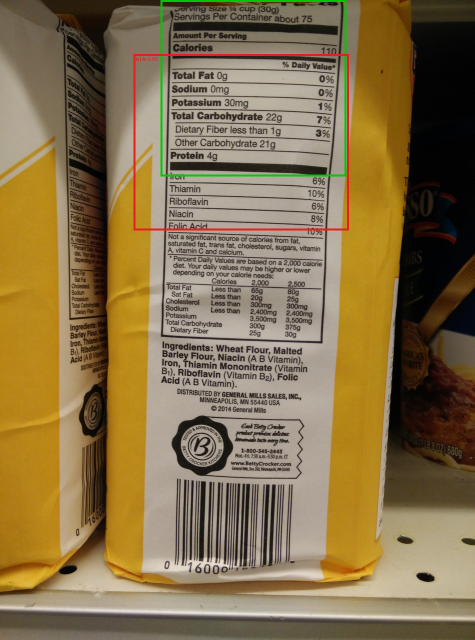

In [ ]:
def draw_boxes(image, reference, detections, width=4):
    canvas = image.convert('RGB').copy()
    pen = ImageDraw.Draw(canvas)
    for box in reference:
        pen.rectangle([round(v) for v in box], outline=(0, 200, 0), width=width)
    for det in detections:
        pen.rectangle([round(v) for v in det['box']], outline=(230, 30, 30), width=width)
        pen.text((det['box'][0] + 4, det['box'][1] + 4), f"{det['label']} {det['score']:.2f}", fill=(230, 30, 30))
    return canvas

probe_record = test_records[0]
image = probe_record['image']
print({'ceilings': {'MIN_IMAGE_SIDE': MIN_IMAGE_SIDE, 'MAX_IMAGE_SIDE': MAX_IMAGE_SIDE, 'MAX_DETECTIONS': MAX_DETECTIONS, 'LABELS': list(LABELS), 'DETECTION_THRESHOLD': DETECTION_THRESHOLD}, 'contract': {'NUM_QUERIES': NUM_QUERIES, 'D_MODEL': D_MODEL, 'DECODER_LAYERS': DECODER_LAYERS, 'PARAMETER_COUNT': PARAMETER_COUNT}})
input_manifest = validate_inputs(image, threshold=DETECTION_THRESHOLD, names=[probe_record['id']])
try:
    validate_inputs(image, threshold=1.5)
except ValueError as exc:
    input_manifest['findings'].append({'input': 'threshold-probe', 'verdict': 'rejected', 'message': str(exc)})
with open('outputs/table_transformer_detection_input_manifest.json', 'w', encoding='utf-8') as handle:
    json.dump(input_manifest, handle, indent=2, ensure_ascii=False)
started = time.perf_counter()
result = pipe.detect(image, threshold=DETECTION_THRESHOLD)
detect_seconds = round(time.perf_counter() - started, 3)
low = pipe.detect(image, threshold=0.05)
checks = {
    'at_most_num_queries': len(low['detections']) <= MAX_DETECTIONS,
    'labels_in_vocabulary': all(d['label'] in LABELS for d in low['detections']),
    'scores_descending': all(a['score'] >= b['score'] for a, b in zip(low['detections'], low['detections'][1:])),
    'boxes_inside_image': all(0 <= d['box'][0] <= d['box'][2] <= image.width + 1 and 0 <= d['box'][1] <= d['box'][3] <= image.height + 1 for d in low['detections']),
}
if not all(checks.values()):
    raise RuntimeError(f'detect output failed a sanity check: {checks}')
report = evaluation_report(low, probe_record['boxes'], sample_kind='one Open Food Facts test photograph' if not USE_BYOD else 'one BYOD test image')
print({'probe_id': probe_record['id'], 'reference_boxes': len(probe_record['boxes']), 'detections_at_threshold': len(result['detections']), 'detections_at_0.05': len(low['detections']), 'seconds': detect_seconds, 'device': pipe.device, 'checks': checks, 'findings': len(input_manifest['findings'])})
print({'verdict': report['verdict'], 'metrics': report['metrics'], 'reason': report.get('reason')})
if report['verdict'] != 'sample-sanity':  # a contract check on the report itself, not a quality claim
    raise RuntimeError(f"evaluation_report returned verdict {report['verdict']!r} for a record with reference boxes")
try:  # `display` is provided by the isolated worker (and by any IPython kernel); the worker has no IPython
    display(draw_boxes(image, probe_record['boxes'], low['detections']).reduce(2))
except NameError:
    print({'preview': 'display unavailable; the preview PNG is written in Section 9'})

**What to notice:** `detections_at_threshold` against `detections_at_0.05`, the checks, and the report's `box_iou`.

<details><summary>Check your reasoning</summary>None, or almost none. The checkpoint's `table` class was learned on rendered PDF pages, and on a product photograph its scores stay far below 0.9. In the CPU build record the probe photograph had one `table` detection at the low threshold of 0.05, overlapping the reference box at IoU 0.47 — the queries look in roughly the right place but do not believe it is a table. That domain gap, not a defect, is what Sections 6–7 adapt around.</details>

## 6. The fixed-box prior, the zero-shot checkpoint and the frozen policy

Three rows frame the adaptation, all on the 25 test photographs and all threshold-free: AP@0.5, AP@0.75 and mAP rank every query of every image by score, so a detector is judged on its ordering, and the recall / precision at the operating threshold (0.9, the pipeline's default) and at 0.5 are printed beside them. The **fixed-box prior** puts one box per photograph at the training split's mean normalised box — what "the table is usually here" alone buys. The **zero-shot checkpoint** (`evaluate_zero_shot`) scores each PubTables query by its `table` + `table rotated` softmax mass, the closest thing the untouched model has to the new class. The **frozen policy** is `adapt` with `trainable_layers=0`: a new two-way class head and a copy of the box head trained on the cached decoder features of the 72 training photographs under the DETR set loss for `HEAD_STEPS` full-batch steps, then scored on the test split by `evaluate`. **What to look for:** the frozen policy far above the prior and the zero-shot row, and the zero-shot row's mean best IoU against its AP — the untrained queries can sit near the tables while scoring them as something else. About half a minute on CPU.

*Evaluation practice.* The cell reports a **verdict** — whether the frozen policy beats the prior on AP@0.5 — and records it; when the prior is competitive (your boxes are always in one place) that is a finding, and the notebook continues. The policy identity stays a hard check: `trainable_layers=0` must give the frozen policy.

**Predict before running:** order the three rows by AP@0.5 — the fixed-box prior, the untouched checkpoint (zero-shot), and new heads trained on its frozen decoder features.

In [ ]:
HEAD_STEPS = 300  # @param {type:"integer"}
HEAD_LR = 1e-3  # @param {type:"number"}

def brief(m):
    return {'ap50': round(m['ap50'], 4), 'ap75': round(m['ap75'], 4), 'map': round(m['map'], 4), 'recall_at_0.9': round(m['operating_points'][str(DETECTION_THRESHOLD)]['recall'], 4), 'recall_at_0.5': round(m['operating_points']['0.5']['recall'], 4), 'precision_at_0.5': round(m['operating_points']['0.5']['precision'], 4), 'mean_best_iou': round(m['mean_best_iou'], 4), 'n': m['n_images']}

prior = prior_baseline(train_records, test_records, threshold=DETECTION_THRESHOLD)
print({'fixed_box_prior': brief(prior), 'baseline': prior['baseline'], 'prior_box_normalised': [round(v, 3) for v in prior['prior_box_normalised']]})
t0 = time.perf_counter()
zero_shot_test = pipe.evaluate_zero_shot(test_records)
print({'zero_shot': brief(zero_shot_test), 'policy': zero_shot_test['policy'], 'seconds': round(time.perf_counter() - t0, 1)})
t0 = time.perf_counter()
probe_result = pipe.adapt(train_records, val_records, head_steps=HEAD_STEPS, head_lr=HEAD_LR, trainable_layers=0)
frozen_test = pipe.evaluate(test_records)
print({'frozen_policy': probe_result['policy'], 'head_final_loss': round(probe_result['head_final_loss'], 4), 'validation': probe_result['history'][0]['val'], 'seconds': round(time.perf_counter() - t0, 1)})
print({'frozen_policy_test': brief(frozen_test), 'loss': round(frozen_test['loss'], 4), 'verdict': frozen_test['verdict']})
print({'definitions': frozen_test['definitions']})
if probe_result['policy'] != POLICY_FROZEN:  # a contract check: trainable_layers=0 is the frozen policy by definition
    raise RuntimeError(f"adapt(trainable_layers=0) returned policy {probe_result['policy']!r}")
# A reported verdict, not an assertion: on your data the prior may be competitive, and that is a finding.
frozen_verdict = 'frozen policy above the fixed-box prior on AP@0.5' if frozen_test['ap50'] > prior['ap50'] else 'frozen policy NOT above the fixed-box prior on AP@0.5: your boxes may sit in one place; read the prior before the detector'
print({'frozen_vs_prior': frozen_verdict})

{'fixed_box_prior': {'ap50': 0.0266, 'ap75': 0.0, 'map': 0.0054, 'recall_at_0.9': 0.1154, 'recall_at_0.5': 0.1154, 'precision_at_0.5': 0.12, 'mean_best_iou': 0.3155, 'n': 25}, 'baseline': "one box per image at the training split's mean normalised reference box (fixed-box prior)", 'prior_box_normalised': [0.175, 0.269, 0.75, 0.713]}


{'zero_shot': {'ap50': 0.0967, 'ap75': 0.0017, 'map': 0.029, 'recall_at_0.9': 0.0385, 'recall_at_0.5': 0.0385, 'precision_at_0.5': 0.2, 'mean_best_iou': 0.4887, 'n': 25}, 'policy': 'zero-shot checkpoint (PubTables heads, table + table rotated mass as the score)', 'seconds': 2.2}


{'frozen_policy': 'frozen backbone, encoder and decoder + new heads', 'head_final_loss': 1.0115, 'validation': {'n': 24, 'loss': 3.380755434433619, 'ap50': 0.200162, 'map': 0.06629, 'recall_at_threshold': 0.0}, 'seconds': 167.7}
{'frozen_policy_test': {'ap50': 0.3179, 'ap75': 0.0681, 'map': 0.1438, 'recall_at_0.9': 0.0, 'recall_at_0.5': 0.6923, 'precision_at_0.5': 0.1406, 'mean_best_iou': 0.5968, 'n': 25}, 'loss': 2.5197, 'verdict': 'measured-small-sample'}
{'definitions': {'ap50': 'average precision at IoU 0.50 over all ranked predictions of all images (one class)', 'ap75': 'average precision at IoU 0.75', 'map': 'mean of the average precision at IoU 0.50, 0.55, ..., 0.95 (the COCO primary metric, one class)', 'recall_at_threshold': 'fraction of reference boxes matched (IoU >= 0.5) by a detection at or above the operating threshold', 'precision_at_threshold': 'fraction of detections at or above the operating threshold that match a reference box', 'mean_best_iou': 'mean over reference 

**What to notice:** the three rows' AP@0.5, AP@0.75, mAP and mean best IoU, and the recall at 0.9 against the recall at 0.5.

<details><summary>Check your reasoning</summary>Prior, then zero-shot, then frozen heads. In the Kaggle T4 release run (19 September 2026) the prior scored AP@0.5 2.66 %, the zero-shot checkpoint 9.67 % (mean best IoU 0.49 — the queries already sit near the tables) and the frozen policy 31.79 % (AP@0.75 6.81 %, mAP 14.38 %); the CPU build record measured 37.6 % / 7.4 % / 15.5 % for the frozen policy. The frozen features already locate nutrition tables once a head knows what to look for. The recall at 0.9 was 0 for the new head: its scores rarely reach a threshold set for the PubTables head.</details>

## 7. The unfrozen policy: a bounded decoder unfreeze selected against the heads

`adapt` with `TRAINABLE_LAYERS` > 0 first retrains the new heads on the frozen features (epoch 0 of the history, the frozen policy), then unfreezes the last `TRAINABLE_LAYERS` decoder layers — two by default, 3,157,504 of 28,799,431 parameters; the backbone, the input projection, the encoder, the query embeddings and the earlier decoder layers stay frozen — and trains them with both heads end to end, one photograph per step, for `EPOCHS` epochs (AdamW at `LEARNING_RATE`, weight decay 0.01, gradient clipping 0.1, seeded order, no augmentation) under the same DETR set loss: Hungarian matching of the 15 queries to the reference boxes (the exact rectangular assignment, the O(n²m) shortest-augmenting-path algorithm, for every supported box count), cross-entropy with a 0.1 no-object weight, L1 and GIoU box terms — all in the carried module, no external matcher. Every epoch is scored on validation, and the epoch with the **lowest validation loss** is kept — epoch 0, the heads alone, competes on equal terms, so the selected policy can be either. AP@0.5 and mAP are printed beside the loss at every epoch.

Watch the validation loss: in the build record it fell every epoch at 1e-4 (3.418 for the heads → 3.350 → 3.305 → 3.292, so epoch 3 was selected); at 3e-4 it fell only to 3.401 and epoch 3 was selected by a hair; with all six layers unfrozen it reached 3.357 at epoch 1 and rose afterwards (3.373, 3.485), so epoch 1 was kept. Note that DETR's train-mode dropout makes the per-photograph training loss sit above the full-batch head loss of epoch 0.

*Core concept.* Every call to `pipe.adapt` starts from the **pinned base**: decoder layers an earlier call (or an artifact) changed are restored before the features are cached, so both policies start from the checkpoint and re-running Sections 6–8 with a changed field repeats the comparison validly. To compare a change side by side without replacing the default exports, use Section 10.

**Predict before running:** if validation loss chooses the unfrozen policy, will the held-out AP@0.75 and mAP necessarily be higher too?

In [ ]:
EPOCHS = 3  # @param {type:"integer"}
LEARNING_RATE = 1e-4  # @param {type:"number"}
TRAINABLE_LAYERS = 2  # @param {type:"integer"}

def report_epoch(entry):
    row = {'epoch': entry['epoch'], 'stage': entry['stage'], 'train_loss': round(entry['train_loss'], 4)}
    if entry.get('val'):
        row['val_loss'] = round(entry['val']['loss'], 4)
        row['val_ap50'] = round(entry['val']['ap50'], 4)
        row['val_map'] = round(entry['val']['map'], 4)
    print(row)

settings = {'epochs': EPOCHS, 'lr': LEARNING_RATE, 'trainable_layers': TRAINABLE_LAYERS, 'head_steps': HEAD_STEPS, 'head_lr': HEAD_LR}
if settings != {'epochs': 3, 'lr': 1e-4, 'trainable_layers': 2, 'head_steps': 300, 'head_lr': 1e-3}:
    print({'note': 'changed settings: this run starts again from the pinned base and replaces the default results of Sections 8-9; Section 10 compares a change side by side instead', 'settings': settings})
t0 = time.perf_counter()
adapt_result = pipe.adapt(train_records, val_records, head_steps=HEAD_STEPS, head_lr=HEAD_LR, trainable_layers=TRAINABLE_LAYERS, epochs=EPOCHS, lr=LEARNING_RATE, progress=report_epoch)
adapt_seconds = round(time.perf_counter() - t0, 1)
report_epoch(adapt_result['history'][0])
print({'selected_policy': adapt_result['policy'], 'best_epoch': adapt_result['best_epoch'], 'selection': adapt_result['selection'], 'trainable_heads': adapt_result['n_trainable_head'], 'trainable_layers': adapt_result['n_trainable_layers'], 'total_parameters': adapt_result['n_total'], 'seconds': adapt_seconds})

{'epoch': 1, 'stage': 'unfrozen last 2 decoder layers + new heads', 'train_loss': 1.8019, 'val_loss': 3.3531, 'val_ap50': 0.2356, 'val_map': 0.0771}


{'epoch': 2, 'stage': 'unfrozen last 2 decoder layers + new heads', 'train_loss': 1.6901, 'val_loss': 3.4795, 'val_ap50': 0.2147, 'val_map': 0.068}


{'epoch': 3, 'stage': 'unfrozen last 2 decoder layers + new heads', 'train_loss': 1.739, 'val_loss': 3.3787, 'val_ap50': 0.2342, 'val_map': 0.0644}
{'epoch': 0, 'stage': 'new heads on frozen decoder features', 'train_loss': 1.0115, 'val_loss': 3.3808, 'val_ap50': 0.2002, 'val_map': 0.0663}
{'selected_policy': 'unfrozen last 2 decoder layers + new heads', 'best_epoch': 1, 'selection': 'lowest validation DETR loss (epoch 0 = new heads on frozen features)', 'trainable_heads': 133126, 'trainable_layers': 3157504, 'total_parameters': 28799431, 'seconds': 195.6}


**What to notice:** epoch 0 (the frozen policy re-trained as the baseline of the history), `val_loss` per epoch, and the selected policy.

<details><summary>Check your reasoning</summary>In the CPU build record the validation loss fell every epoch at 1e-4 (3.418 for the heads → 3.350 → 3.305 → 3.292), so the unfrozen policy was selected at epoch 3; the Kaggle T4 release run also selected the unfrozen policy. Validation loss is the selection criterion, not the result: whether the selected model is better on held-out photographs, and on which metric, is Section 8's question.</details>

## 8. Held-out evaluation

The test split was never used for training or policy selection, and no product in it appears in the training or validation splits. The selected model is scored exactly as the frozen policy was in Section 6, and the four rows are put side by side: fixed-box prior, zero-shot checkpoint, frozen policy, selected policy. Read the policy first: if validation kept the heads, the last two rows are the same model; if it chose the unfreeze, the delta is what the unfreeze bought on 25 photographs. **What to look for:** compare AP@0.5, AP@0.75 and mAP between the two policies *separately* — they need not move together, and on 26 boxes a difference of a few points is within noise (one box is about four points of recall). The cell records verdicts — whether the selected model beats the fixed-box prior, and whether it improved on the frozen heads at AP@0.5 and at mAP — instead of asserting them, because a policy that does not help is a finding, not an error, and Section 9 still exports, reloads and writes the result. 25 photographs with 26 boxes from one seeded split of one corpus give no dispersion estimate.

**Predict before running:** validation loss chose between the policies. Will the held-out test agree with it on every metric?

In [ ]:
adapted_test = pipe.evaluate(test_records)
adapted_val = pipe.evaluate(val_records)
rows = {'fixed_box_prior': prior, 'zero_shot': zero_shot_test, 'frozen_policy': frozen_test, 'selected_policy': adapted_test}
comparison = {metric: {name: round(m[metric], 4) for name, m in rows.items()} for metric in ('ap50', 'ap75', 'map', 'mean_best_iou')}
comparison['recall_at_0.5'] = {name: round(m['operating_points']['0.5']['recall'], 4) for name, m in rows.items()}
comparison['precision_at_0.5'] = {name: round(m['operating_points']['0.5']['precision'], 4) for name, m in rows.items()}
comparison['recall_at_0.9'] = {name: round(m['operating_points'][str(DETECTION_THRESHOLD)]['recall'], 4) for name, m in rows.items()}
comparison['loss'] = {'frozen_policy': round(frozen_test['loss'], 4), 'selected_policy': round(adapted_test['loss'], 4)}
comparison['delta_vs_frozen'] = {metric: round(adapted_test[metric] - frozen_test[metric], 4) for metric in ('ap50', 'ap75', 'map')}
comparison['delta_vs_zero_shot'] = {metric: round(adapted_test[metric] - zero_shot_test[metric], 4) for metric in ('ap50', 'ap75', 'map')}
comparison['selected_policy'] = adapt_result['policy']
# Reported verdicts, not assertions: a policy that does not help is a result to record, and export and reload still run.
comparison['verdicts'] = {
    'frozen_vs_prior': frozen_verdict,
    'selected_above_prior_ap50': bool(adapted_test['ap50'] > prior['ap50']),
    'selected_vs_frozen_ap50': 'improved' if adapted_test['ap50'] > frozen_test['ap50'] else ('no gain' if adapted_test['ap50'] == frozen_test['ap50'] else 'worse'),
    'selected_vs_frozen_map': 'improved' if adapted_test['map'] > frozen_test['map'] else ('no gain' if adapted_test['map'] == frozen_test['map'] else 'worse'),
}
for metric, row in comparison.items():
    print({metric: row})
evaluation_report_payload = {
    'model': {'id': MODEL_ID, 'revision': MODEL_REVISION, 'key': MODEL_KEY},
    'data_source': data_source,
    'dataset_digests': {name: manifest['digest'] for name, manifest in dataset_manifests.items()},
    'splits': disjoint,
    'split_summary': summary,
    'single_image_report': report,
    'baselines': {'fixed_box_prior': prior, 'zero_shot': zero_shot_test},
    'frozen_policy': {'adaptation': {k: v for k, v in probe_result.items() if k not in ('history', 'trainable_names')}, 'history': probe_result['history'], 'test': frozen_test},
    'validation_metrics': adapted_val,
    'test_metrics': adapted_test,
    'comparison': comparison,
    'adaptation': {k: v for k, v in adapt_result.items() if k not in ('history', 'trainable_names')},
    'history': adapt_result['history'],
    'adaptation_seconds': adapt_seconds,
}
with open('outputs/table_transformer_detection_evaluation_report.json', 'w', encoding='utf-8') as f:
    json.dump(evaluation_report_payload, f, indent=2, ensure_ascii=False)
print({'verdicts': comparison['verdicts']})
print({'report': 'outputs/table_transformer_detection_evaluation_report.json'})

{'ap50': {'fixed_box_prior': 0.0266, 'zero_shot': 0.0967, 'frozen_policy': 0.3179, 'selected_policy': 0.3315}}
{'ap75': {'fixed_box_prior': 0.0, 'zero_shot': 0.0017, 'frozen_policy': 0.0681, 'selected_policy': 0.0659}}
{'map': {'fixed_box_prior': 0.0054, 'zero_shot': 0.029, 'frozen_policy': 0.1438, 'selected_policy': 0.1288}}
{'mean_best_iou': {'fixed_box_prior': 0.3155, 'zero_shot': 0.4887, 'frozen_policy': 0.5968, 'selected_policy': 0.6036}}
{'recall_at_0.5': {'fixed_box_prior': 0.1154, 'zero_shot': 0.0385, 'frozen_policy': 0.6923, 'selected_policy': 0.6538}}
{'precision_at_0.5': {'fixed_box_prior': 0.12, 'zero_shot': 0.2, 'frozen_policy': 0.1406, 'selected_policy': 0.1241}}
{'recall_at_0.9': {'fixed_box_prior': 0.1154, 'zero_shot': 0.0385, 'frozen_policy': 0.0, 'selected_policy': 0.0}}
{'loss': {'frozen_policy': 2.5197, 'selected_policy': 2.5167}}
{'delta_vs_frozen': {'ap50': 0.0136, 'ap75': -0.0022, 'map': -0.0149}}
{'delta_vs_zero_shot': {'ap50': 0.2348, 'ap75': 0.0642, 'map': 0.0

**What to notice:** the selected policy, the four rows on each metric, `delta_vs_frozen` and the `verdicts` row.

<details><summary>Check your reasoning</summary>Not necessarily — and in the release run it did not. In the Kaggle T4 run (19 September 2026) validation loss chose the unfrozen policy, and on the test split it scored AP@0.5 33.15 % against the frozen heads' 31.79 %, but AP@0.75 6.59 % against 6.81 % and mAP 12.88 % against 14.38 %: better at 0.5, slightly worse at the stricter thresholds. The CPU build record had shown the opposite pattern (39.8 % / 13.4 % / 16.3 % against 37.6 % / 7.4 % / 15.5 %). On 26 boxes these differences are within noise; the lesson is that a selection criterion (validation loss) and a held-out metric can disagree, so read every metric and do not assert a direction one run cannot support.</details>

## 9. Detect before and after, export the adapter and reload it

Three test photographs are run through `detect_adapted` with the selected model at a 0.5 threshold and rendered beside the frozen policy's detections (from a fresh pipeline with new heads trained the same way — after an unfreeze the decoder inside `pipe` has moved, so the frozen column needs its own decoder) and the reference boxes: reference in green, detections in red with the head's score, which is a softmax under a 0.1 no-object weight, not a calibrated confidence; `outputs/table_transformer_detection_preview.png` holds the sheet. `detect` — the PubTables heads — still answers in its own label space on the same photographs.

`save_artifact` writes the new class head and box head and, when the unfrozen policy was selected, the trained decoder-layer tensors — about 0.5 MB for the heads alone, 13.2 MB with two decoder layers — as `adapter.safetensors`, with a `manifest.json` recording the artifact format, the base model id and revision, the digest of the base `model.safetensors`, the class, the selected policy, the tensor names, the file size and SHA-256, the training configuration and the epoch history (OUT8). `TableTransformerDetectionPipeline.from_artifact` re-verifies the base snapshot, checks the artifact manifest and digest **before** deserialising, rebuilds the heads from the manifest, refuses any tensor that is not a decoder-layer tensor of the base, and overlays the tensors onto a freshly loaded base — a new object from files, not the in-memory model (VER2). The cell asserts identical query scores and boxes on three photographs and an identical test AP@0.5 (VER4) — a contract check, so it stays a hard check.

**Predict before running:** in the preview sheet, will the selected model's boxes look tighter than the frozen heads' on these three photographs?

Some weights of the model checkpoint at /content/weights/table-transformer-detection were not used when initializing TableTransformerForObjectDetection: ['model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing TableTransformerForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TableTransformerForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


{'id': 'test-000', 'reference_boxes': 1, 'frozen_detections': 2, 'frozen_best_iou': 0.3324, 'selected_detections': 3, 'selected_best_iou': 0.358, 'pubtables_detections_at_0.05': 5, 'image_url': 'https://static.openfoodfacts.org/images/products/001/600/010/6406/2.jpg'}


{'id': 'test-001', 'reference_boxes': 1, 'frozen_detections': 4, 'frozen_best_iou': 0.5745, 'selected_detections': 4, 'selected_best_iou': 0.5918, 'pubtables_detections_at_0.05': 5, 'image_url': 'https://static.openfoodfacts.org/images/products/328/423/000/2240/2.jpg'}


{'id': 'test-002', 'reference_boxes': 1, 'frozen_detections': 3, 'frozen_best_iou': 0.6238, 'selected_detections': 4, 'selected_best_iou': 0.5854, 'pubtables_detections_at_0.05': 3, 'image_url': 'https://static.openfoodfacts.org/images/products/007/341/600/6102/2.jpg'}


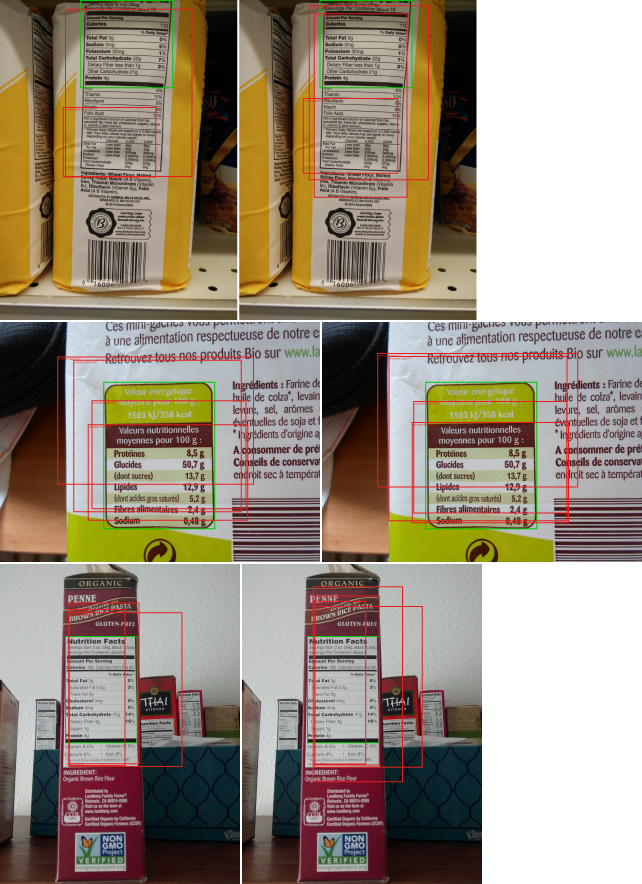

{'artifact': 'outputs/table_transformer_detection_adapter', 'format': 'org.valcorza.table-transformer-detection.adapter.v1', 'policy': 'unfrozen last 2 decoder layers + new heads', 'classes': ['nutrition-table'], 'tensors': 60, 'bytes': 13169120, 'sha256': '7c8725236d1ddf6f...'}


Some weights of the model checkpoint at /content/weights/table-transformer-detection were not used when initializing TableTransformerForObjectDetection: ['model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing TableTransformerForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TableTransformerForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


{'reload_parity': {'queries_identical': True, 'ap50_in_memory': 0.331495, 'ap50_reloaded': 0.331495, 'classes_identical': True}, 'reloaded_policy': 'unfrozen last 2 decoder layers + new heads', 'reloaded_best_epoch': 1}
['table_transformer_detection_adapter', 'table_transformer_detection_evaluation_report.json', 'table_transformer_detection_input_manifest.json', 'table_transformer_detection_preview.png', 'table_transformer_detection_result.json', 'table_transformer_detection_train.csv']


In [ ]:
import shutil

show = test_records[:3]
frozen_pipe = TableTransformerDetectionPipeline.from_pretrained(weights_dir=WEIGHTS_DIR, device=pipe.device)
frozen_pipe.adapt(train_records, val_records, head_steps=HEAD_STEPS, head_lr=HEAD_LR, trainable_layers=0)
before_after = []
panels = []
for record in show:
    after = pipe.detect_adapted(record['image'], threshold=0.5)
    before = frozen_pipe.detect_adapted(record['image'], threshold=0.5)
    base = pipe.detect(record['image'], threshold=0.05)
    best_after = max((box_iou(d['box'], ref) for d in after['detections'] for ref in record['boxes']), default=0.0)
    best_before = max((box_iou(d['box'], ref) for d in before['detections'] for ref in record['boxes']), default=0.0)
    before_after.append({'id': record['id'], 'reference_boxes': len(record['boxes']), 'frozen_detections': len(before['detections']), 'frozen_best_iou': round(best_before, 4), 'selected_detections': len(after['detections']), 'selected_best_iou': round(best_after, 4), 'pubtables_detections_at_0.05': len(base['detections']), 'image_url': record.get('image_url', '')})
    print(before_after[-1])
    left = draw_boxes(record['image'], record['boxes'], before['detections'])
    right = draw_boxes(record['image'], record['boxes'], after['detections'])
    panel = Image.new('RGB', (left.width * 2 + 8, left.height), (255, 255, 255))
    panel.paste(left, (0, 0))
    panel.paste(right, (left.width + 8, 0))
    panels.append(panel)
sheet = Image.new('RGB', (max(p.width for p in panels), sum(p.height for p in panels) + 8 * (len(panels) - 1)), (255, 255, 255))
y = 0
for panel in panels:
    sheet.paste(panel, (0, y))
    y += panel.height + 8
sheet.save('outputs/table_transformer_detection_preview.png')
try:  # `display` is provided by the isolated worker (and by any IPython kernel)
    display(sheet.reduce(4))
except NameError:
    pass

artifact_dir = Path('outputs/table_transformer_detection_adapter')
shutil.rmtree(artifact_dir, ignore_errors=True)
pipe.save_artifact(artifact_dir, metadata={'tutorial': 'table_transformer_detection', 'data_source': data_source})
artifact_manifest = json.loads((artifact_dir / 'manifest.json').read_text(encoding='utf-8'))
print({'artifact': str(artifact_dir), 'format': artifact_manifest['format'], 'policy': artifact_manifest['adapter']['policy'], 'classes': artifact_manifest['adapter']['classes'], 'tensors': len(artifact_manifest['tensors']), 'bytes': artifact_manifest['files'][0]['bytes'], 'sha256': artifact_manifest['files'][0]['sha256'][:16] + '...'})

reloaded = TableTransformerDetectionPipeline.from_artifact(artifact_dir, weights_dir=WEIGHTS_DIR, device=pipe.device)
reloaded_test = reloaded.evaluate(test_records)
parity = {'queries_identical': reloaded.predict_boxes(show) == pipe.predict_boxes(show), 'ap50_in_memory': round(adapted_test['ap50'], 6), 'ap50_reloaded': round(reloaded_test['ap50'], 6), 'classes_identical': reloaded.classes == pipe.classes}
print({'reload_parity': parity, 'reloaded_policy': reloaded.adapter['policy'], 'reloaded_best_epoch': reloaded.adapter['best_epoch']})
assert parity['queries_identical'] and parity['classes_identical'] and abs(adapted_test['ap50'] - reloaded_test['ap50']) < 1e-9

weight_entry = next(entry for entry in MANIFEST['files'] if entry['path'] == WEIGHTS_FILE)
result_payload = {
    'notebook_source': NOTEBOOK_SOURCE,
    'repository_revision': NOTEBOOK_SOURCE['repository_revision'],
    'model_id': MODEL_ID,
    'model_revision': MODEL_REVISION,
    'model_license': MODEL_LICENSE,
    'snapshot': {'path': str(WEIGHTS_DIR), 'files': len(MANIFEST['files']), 'total_bytes': MANIFEST['totalBytes'], 'fetched_this_run': fetched, 'weight_file': WEIGHTS_FILE, 'weight_format': 'safetensors, digest-verified', 'weight_sha256': weight_entry['sha256']},
    'data_source': data_source,
    'corpus': {'name': CORPUS_NAME, 'release': CORPUS_RELEASE, 'base_url': CORPUS_BASE_URL, 'photographs': len(SAMPLE_RECORDS), 'bytes': CORPUS_BYTES, 'license': CORPUS_LICENSE, 'class': CLASS_NAME, 'longest_side': CORPUS_LONGEST_SIDE},
    'inference_contract': {'input_manifest': input_manifest, 'sanity_checks': checks, 'probe_id': probe_record['id'], 'single_image_report': report, 'seconds': detect_seconds},
    'comparison': comparison,
    'before_after': before_after,
    'preview_file': 'outputs/table_transformer_detection_preview.png',
    'artifact': {'dir': str(artifact_dir), 'sha256': artifact_manifest['files'][0]['sha256'], 'bytes': artifact_manifest['files'][0]['bytes'], 'tensors': len(artifact_manifest['tensors']), 'policy': artifact_manifest['adapter']['policy']},
    'reload_parity': parity,
    'runtime': {'python': platform.python_version(), 'torch': torch.__version__, 'transformers': transformers.__version__, 'timm': timm.__version__, 'device': pipe.device, 'dtype': 'float32', 'source': pipe.source},
}
with open('outputs/table_transformer_detection_result.json', 'w', encoding='utf-8') as handle:
    json.dump(result_payload, handle, indent=2, ensure_ascii=False)
print(sorted(os.listdir('outputs')))

**What to notice:** `frozen_best_iou` against `selected_best_iou` in `before_after`, the preview sheet, and the reload parity line.

<details><summary>Check your reasoning</summary>Three photographs cannot answer that: each row's best IoU is one box, and the release run's held-out numbers (Section 8) moved in different directions at different IoU thresholds. Use the sheet to see *what* the detector does — where it fires, how many boxes, how the scores sit below 0.9 — not to rank the policies. Reload parity held in the release run: identical query scores and boxes, and test AP@0.5 0.3315 in memory and reloaded.</details>

## 10. Change one thing: unfreeze all six decoder layers (optional)

*Evaluation practice.* A **Predict → Change one thing → Run → Observe → Explain** activity, off by default so Run all is unaffected. Set `RUN_EXPERIMENT = True`, change **one** field — by default all six decoder layers train instead of two — and run this cell after Sections 4–9. The experiment loads its **own** pipeline from the verified snapshot, so it starts from the checkpoint and never touches the default `pipe`; it writes only to `outputs/table_transformer_detection_experiment/`, prints the default and the changed run side by side, and checks that the default exports (adapter, evaluation report, result) are byte-identical afterwards. A few minutes on CPU.

**Predict:** with three times the trainable decoder layers, which epoch will validation select, and will the held-out mAP rise?

In [ ]:
RUN_EXPERIMENT = False  # @param {type:"boolean"}
EXPERIMENT_TRAINABLE_LAYERS = 6  # @param {type:"integer"}
EXPERIMENT_EPOCHS = 3  # @param {type:"integer"}
EXPERIMENT_LEARNING_RATE = 1e-4  # @param {type:"number"}

if not RUN_EXPERIMENT:
    print({'experiment': 'skipped (RUN_EXPERIMENT = False); the default path above is complete'})
else:
    canonical_files = {'adapter': artifact_dir / 'adapter.safetensors', 'evaluation_report': Path('outputs/table_transformer_detection_evaluation_report.json'), 'result': Path('outputs/table_transformer_detection_result.json')}
    canonical = {name: hashlib.sha256(path.read_bytes()).hexdigest() for name, path in canonical_files.items()}
    experiment_dir = Path('outputs/table_transformer_detection_experiment')
    shutil.rmtree(experiment_dir, ignore_errors=True)
    experiment_dir.mkdir(parents=True)
    # Its own pipeline from the verified snapshot: the experiment starts from the checkpoint and the default pipe is untouched.
    experiment_pipe = TableTransformerDetectionPipeline.from_pretrained(weights_dir=WEIGHTS_DIR, device=pipe.device)
    experiment_result = experiment_pipe.adapt(train_records, val_records, head_steps=HEAD_STEPS, head_lr=HEAD_LR, trainable_layers=EXPERIMENT_TRAINABLE_LAYERS, epochs=EXPERIMENT_EPOCHS, lr=EXPERIMENT_LEARNING_RATE, progress=report_epoch)
    experiment_test = experiment_pipe.evaluate(test_records)
    side_by_side = {
        'settings': {'default': {'trainable_layers': adapt_result['trainable_layers'], 'epochs': adapt_result['epochs'], 'lr': adapt_result['lr']}, 'experiment': {'trainable_layers': EXPERIMENT_TRAINABLE_LAYERS, 'epochs': EXPERIMENT_EPOCHS, 'lr': EXPERIMENT_LEARNING_RATE}},
        'selected_policy': {'default': adapt_result['policy'], 'experiment': experiment_result['policy']},
        'best_epoch': {'default': adapt_result['best_epoch'], 'experiment': experiment_result['best_epoch']},
        'validation_loss_by_epoch': {'default': [round(e['val']['loss'], 4) for e in adapt_result['history'] if e.get('val')], 'experiment': [round(e['val']['loss'], 4) for e in experiment_result['history'] if e.get('val')]},
        'test': {metric: {'frozen_policy': round(frozen_test[metric], 4), 'default': round(adapted_test[metric], 4), 'experiment': round(experiment_test[metric], 4)} for metric in ('ap50', 'ap75', 'map')},
    }
    for key, row in side_by_side.items():
        print({key: row})
    with open(experiment_dir / 'experiment_report.json', 'w', encoding='utf-8') as handle:
        json.dump({'side_by_side': side_by_side, 'history': experiment_result['history']}, handle, indent=2, ensure_ascii=False, default=str)
    unchanged = {name: hashlib.sha256(path.read_bytes()).hexdigest() == canonical[name] for name, path in canonical_files.items()}
    if not all(unchanged.values()):
        raise RuntimeError(f'the experiment changed a default export: {unchanged}')
    print({'default_exports_unchanged': unchanged, 'experiment_outputs': str(experiment_dir)})
    del experiment_pipe

{'experiment': 'skipped (RUN_EXPERIMENT = False); the default path above is complete'}


**Observe → Explain.** Compare the two validation-loss curves and the `test` rows.

<details><summary>Check your reasoning</summary>Epoch 0 of both runs is the frozen policy (new heads on the checkpoint's features), so the two curves start from the same kind of model. In the CPU build record all six layers reached the lowest validation loss at epoch 1 (3.357) and rose afterwards (3.373, 3.485), so epoch 1 was kept, with 41.0 % AP@0.5 / 18.3 % mAP and a 38 MB adapter — more capacity began to overfit 72 photographs within two epochs. No experiment run is recorded on the release runtime; on 26 test boxes, read a difference of a few points as noise, and explain it from the validation curve rather than from the test number.</details>

## Interpretation and limits

On 25 held-out product photographs the fixed-box prior and the untouched PubTables detector score a few percent AP@0.5 and new heads on its frozen decoder features roughly ten times that — in the Kaggle T4 release run (19 September 2026) 2.66 %, 9.67 % and 31.79 %. Whether unfreezing the last two decoder layers adds anything is not settled by this sample: validation loss chose the unfreeze in that run, which then scored higher at AP@0.5 (33.15 %) but lower at AP@0.75 and mAP (6.59 % and 12.88 % against 6.81 % and 14.38 %), while the CPU build record had seen gains on all three — differences of a few points on 26 boxes, within noise. The adapter reloads to identical query scores. That is the claim and the finding: the adaptation contract gives the PubTables detector a class and a domain it was not trained on, runs both policies end to end on a real box-labelled corpus with the set loss implemented in the open, chooses between them on validation rather than by assumption, and reports the answer against a prior and the untouched checkpoint rather than in isolation.

The test split is 25 photographs with 26 boxes from one seeded split of one small corpus with no dispersion estimate — one box is about four points of recall, so a few points of AP is noise. AP ranks every query by the new head's score; the pipeline's operating threshold of 0.9 was set for the PubTables head and the new head's scores rarely reach it (the recall at 0.9 is reported beside the recall at 0.5) — a deployment must choose its own threshold on its own labelled images, exactly as the model card says for the base detector. When the unfrozen policy is selected it changes the last decoder layers, which every query shares, so `detect` — which keeps the PubTables heads — reads a moved decoder afterwards; the artifact records which policy won.

Three things to carry to real data. **Baselines first:** the fixed-box prior and the zero-shot checkpoint on *your* images are the numbers to read before any trained head's — if the prior is competitive, your boxes are in one place and the detector is not the interesting part. **Leakage:** split by product, session or device (the contract splits by `group` / `barcode`, never by photograph). **Thresholds:** AP is threshold-free and an operating point is not; pick it on validation for the class you trained, not from the base checkpoint.

Successful execution proves that the recorded repository revision's pipeline modules, carried in this standalone notebook, can acquire and digest-verify the pinned model snapshot, fetch and digest-verify a real box-labelled corpus, validate the demonstrated dataset contract without leakage, execute the inference contract with a `sample-sanity` report against reference boxes, train new detection heads and a bounded decoder unfreeze with validation-based policy selection, evaluate by AP against a prior and the zero-shot checkpoint on an independent split, and emit the shown machine-readable artifacts — without the repository being reachable. It does **not** establish benchmark superiority, PubTables-1M accuracy, a usable acceptance threshold, or production fitness.

**Optional experiments (off by default; each names its field and what to run):** Section 10 unfreezes all six decoder layers in its own pipeline and prints it beside the default run — change `EXPERIMENT_TRAINABLE_LAYERS`, `EXPERIMENT_EPOCHS` or `EXPERIMENT_LEARNING_RATE` (the build record's 3e-4 was selected by a hair) there and run that cell again. Setting `EPOCHS = 0` or changing `HEAD_STEPS` / `TRAINABLE_LAYERS` / `LEARNING_RATE` and choosing **Run after** from Section 6 also starts from the pinned base — every `adapt` restores it first — but replaces the default results and exports. BYOD: `USE_BYOD` and `BYOD_PATH` in Section 4, then **Run after** from Section 4, and read the prior and the zero-shot row before either policy.

## Troubleshooting

- **Section 1 stops with "This notebook needs a Linux x86_64 runtime"** — you are on Windows, macOS or an ARM machine. Use Google Colab, Kaggle or a Linux x86_64 Jupyter server.
- **The uv wheel fails its size/SHA-256 check, or a download in Section 1 times out** — run Section 1 again; a complete environment is reused, an incomplete one is finished. If it repeats, the network is blocking or altering `files.pythonhosted.org` or `pypi.org`.
- **"The isolated environment's Python process exited"** — usually out of memory. Restart the session and choose **Run all**; leave the optional experiment off on a small runtime.
- **You re-ran Section 1 on its own** — nothing is lost: it keeps the running worker and every variable, so the cells after it keep working. After a session restart, run from the top.
- **Section 3 reports a size or SHA-256 mismatch, or cannot reach the Hub** — the message names the file. Delete it from the snapshot folder Section 3 prints and run Section 3 again; the snapshot comes from `huggingface.co`.
- **Section 4 cannot fetch a photograph, or one fails its digest** — `fetch_corpus` names it; the default path needs `static.openfoodfacts.org`, which can throttle (the fetch retries with back-off). Run Section 4 again (cached photographs are re-hashed); delete `weights/off-nutrition/` if a cached file is corrupt.
- **Out of memory** — the model is small; restart the session and choose **Run all**, and leave Section 10 off on a small runtime.
- **BYOD: "BYOD_PATH … does not exist"** — the path is relative to the working directory printed in the message.
- **BYOD: "the upload dialog exists only in Google Colab"** — on Kaggle or Jupyter, put the zip in the runtime (or attach it as a dataset) and set `BYOD_PATH`.
- **BYOD: "Upload exactly one .zip file"** — the dialog was cancelled or several files were chosen; run the cell again.
- **BYOD: "boxes.csv line N (file …): names an image that is not in the dataset"** — fix the `file` column of that row.
- **BYOD: "… carries EXIF orientation …"** — a phone photograph stored sideways; re-save it upright and draw the boxes on the upright image.
- **BYOD: "… has no `group`"** — every row needs the product, session or device the photograph belongs to.
- **BYOD: "split leaves … supply at least 12 photographs in as many groups"** — add photographs or groups.
## Glossary

- **DETR query** — one of 15 learned slots the decoder fills with a box and a class distribution; most answer "no object".
- **Set loss / Hungarian matching** — predictions are matched one-to-one to reference boxes at the lowest total cost before the loss is computed.
- **GIoU** — generalised IoU, a box-overlap term that still gives a gradient when boxes do not overlap.
- **IoU** — intersection over union of two boxes.
- **AP@0.5 / AP@0.75 / mAP** — average precision over the ranked predictions, counting a match at IoU ≥ 0.5, ≥ 0.75, and averaged over 0.5..0.95; threshold-free.
- **Operating point** — a score threshold and the recall and precision it gives; chosen per deployment.
- **Fixed-box prior** — one box per image at the training set's mean box.
- **Zero-shot row** — the untouched checkpoint, its `table` classes read as the new class.
- **Frozen policy / unfrozen policy** — new heads on frozen decoder features; the same plus the last decoder layers trained.
- **Validation selection** — choosing the policy and epoch by validation loss, never by the test split.
- **Group-disjoint split** — every product (or session, device) on one side of the split.
- **Adapter / reload parity** — the trained tensors only (safetensors) overlaid on the pinned base; the reloaded pipeline gives identical scores.
- **BYOD** — bring your own data: your box-labelled photographs through the same cells.

## Conclusion (your notes)

Optional — fill in from **your** run, not the recorded one:

- The task was ___ on ___ test photographs with ___ boxes.
- The prior scored AP@0.5 ___, the zero-shot row ___ and the frozen policy ___ (mAP ___).
- Validation selected the ___ policy at epoch ___; on the test split it scored AP@0.5 ___ / AP@0.75 ___ / mAP ___, so against the frozen heads it ___.
- What I would need before claiming the unfreeze helps: ___ (for example more test boxes, several seeds).

## References

- Repository README: https://github.com/kurtvalcorza/table-transformer-detection-pipeline/blob/main/README.md
- Repository model card: https://github.com/kurtvalcorza/table-transformer-detection-pipeline/blob/main/MODEL_CARD.md
- Weight provenance: https://github.com/kurtvalcorza/table-transformer-detection-pipeline/blob/main/docs/WEIGHTS.md
- Upstream model: https://huggingface.co/microsoft/table-transformer-detection
- Upstream code: https://github.com/microsoft/table-transformer
- PubTables-1M: Towards Comprehensive Table Extraction From Unstructured Documents (Smock, Pesala, Abraham, 2021): https://arxiv.org/abs/2110.00061
- End-to-End Object Detection with Transformers (DETR; the set loss and Hungarian matching, Carion et al., 2020): https://arxiv.org/abs/2005.12872
- Open Food Facts nutrition-table detection dataset (boxes, ODbL) and Open Food Facts images (CC BY-SA 3.0, credited to their contributors): https://huggingface.co/datasets/openfoodfacts/nutrition-table-detection — https://world.openfoodfacts.org/data
- DIMER Notebook Specification 2.2 and Model Card Specification 1.1 (fleet specs in the ml-worker repository)